# Análise de Telemetria de Curvas na Fórmula 1


## Integrantes:
* RENAN SINESIO ALMEIDA
* VINICIUS ALENCAR DE MEDEIROS
* VYNICIOS DANIEL CAETANO LOPES DA SILVA
* YOSEF JOSEPH GONCALVES DO NASCIMENTO


## Introdução:

### Motivação: 
Utilizamos a frase "Nas retas se conhece o carro, nas curvas o piloto" e também as diversas nuances de técnicas de pilotagem como inspiração e base para delimitar o tema. Além disso, o tema de Fórmula 1 é rico em dados e detalhes sobre a performance de um piloto em diversas situações: Sempre surgem tabelas como dominância de um piloto em relação a outro em trechos do circuito, tempo perdido em uma frenagem, tempo de reação na largada ou gasto em frenagem. Ainda, existem diversos estilos de direção e ajustes de carro, como frear mais cedo para se posicionar melhor na curva e sair melhor ou frear mais tarde para aproveitar por mais tempo a velocidade máxima, mas estar mais propenso a erros. Um carro pode favorecer a velocidade em retas com ajustes de baixa pressão aerodinâmica, ou favorecer curvas com ajustes de alta pressão aerodinâmica: cada detalhe importa e impacta na forma de conduzir o carro em seu desempenho durante a corrida, seja na consistência no ritmo de corrida ou no desgaste dos pneus.

### Objetivos:
Analisar os diversos estilos de pilotagem dos pilotos de Formula 1 em curvas selecionadas.
Entender os ajustes feitos por equipes durante os finais de semana.
Observar a evolução de pilotos novatos ao longo da temporada.

## Dados Usados:
Foram processados dados coletados da API Openf1 de forma a calcular a velocidade média de cada piloto em curvas selecionadas.

O conjunto de dados final consiste em 17 arquivos no formato .csv, onde cada arquivo representa uma etapa do campeonato de Fórmula 1. Cada arquivo contém os dados de desempenho dos 20 pilotos durante a sua volta mais rápida na sessão de qualificação correspondente.

As colunas principais em cada arquivo são:

* full_name: Nome e sobrenome do piloto.

* name_acronym: Abreviação do nome do piloto.

* team_name: Nome da equipe à qual o piloto pertence.

* driver_number: Número utilizado pelo piloto como identificação.

*position: A posição final do piloto na sessão de qualificação.

*Etapa: A fase da qualificação (Q1, Q2 ou Q3) na qual a volta mais rápida do piloto foi registada.

*curva_1, curva_2, ..., curva_n: Uma série de colunas representando a velocidade média do piloto, em km/h, em cada uma das curvas selecionadas para análise ao longo de toda a temporada.;

## Exploração Inicial:

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress


Para uma amostra simples da estrutura dos dados, com identificadores de piloto, equipe e dos dados referentes à volta rápida:

In [2]:
exemplo = pd.read_csv('csvs/resultados_Spa-Francorchamps.csv')
display(exemplo.head())

,Unnamed: 0,driver_number,full_name,name_acronym,team_name,position,Etapa,curva 1,curva 2,curva 3,curva 4,curva 5,curva 6,curva 7,curva 8
0,0,4,Lando NORRIS,NOR,McLaren,1,Q3,154.292096,303.119822,212.588227,293.814954,214.893614,310.831079,100.464692,171.879346
1,1,81,Oscar PIASTRI,PIA,McLaren,2,Q2,149.526012,284.980137,206.420539,295.102150,217.907183,310.091321,99.402774,170.194850
2,2,16,Charles LECLERC,LEC,Ferrari,3,Q3,151.616061,304.497437,210.009198,280.943982,216.764188,300.992174,98.498178,170.237772
3,3,1,Max VERSTAPPEN,VER,Red Bull Racing,4,Q3,150.891029,301.804296,208.490086,293.220182,222.346489,311.544789,102.084586,174.117701
4,4,23,Alexander ALBON,ALB,Williams,5,Q3,150.305457,330.848441,209.035674,284.158489,212.304157,307.873902,99.734370,169.510888


Vamos verificar o tipo de cada coluna:

In [3]:
exemplo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     20 non-null     int64  
 1   driver_number  20 non-null     int64  
 2   full_name      20 non-null     object 
 3   name_acronym   20 non-null     object 
 4   team_name      20 non-null     object 
 5   position       20 non-null     int64  
 6   Etapa          20 non-null     object 
 7   curva 1        20 non-null     float64
 8   curva 2        20 non-null     float64
 9   curva 3        20 non-null     float64
 10  curva 4        20 non-null     float64
 11  curva 5        20 non-null     float64
 12  curva 6        20 non-null     float64
 13  curva 7        20 non-null     float64
 14  curva 8        20 non-null     float64
dtypes: float64(8), int64(3), object(4)
memory usage: 2.5+ KB


Conforme esperado, valores categóricos como nome de piloto e equipe estão listado como objetos, e suas velocidades estão em float.

#### Para as estatísticas descritivas:

In [4]:
exemplo.describe()

,Unnamed: 0,driver_number,position,curva 1,curva 2,curva 3,curva 4,curva 5,curva 6,curva 7,curva 8
count,20.00000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,9.50000,29.600000,10.50000,150.338330,306.625810,204.965929,285.815308,216.355700,306.728521,98.871352,168.322287
std,5.91608,25.221962,5.91608,2.624003,12.899116,4.210949,4.647324,2.648516,3.929965,1.806548,2.903484
min,0.00000,1.000000,1.00000,145.266992,279.010158,195.139251,280.943982,211.903601,300.184871,94.199061,162.992573
25%,4.75000,11.500000,5.75000,148.836666,301.959484,202.403299,281.808195,214.777327,304.377133,97.765185,165.977452
50%,9.50000,22.500000,10.50000,150.598243,304.622314,205.311399,284.725609,216.202289,307.460421,99.290334,168.446613
75%,14.25000,43.250000,15.25000,151.962832,315.181416,207.363641,288.906844,218.091632,309.215684,99.932465,170.266716
max,19.00000,87.000000,20.00000,154.292096,330.848441,212.588227,295.102150,222.346489,313.252009,102.084586,174.117701


Aqui podemos observar que há uma variação que pode alcançar 10% desde o piloto mais lento ao piloto mais rápido em cada curva, além de que há uma distribuição de curvas em diversas faixas de velocidade.

Vamos analisar o gráfico de distribuição dos pilotos na curva 2, que nesse exemplo, é a famosa Eau Rouge.

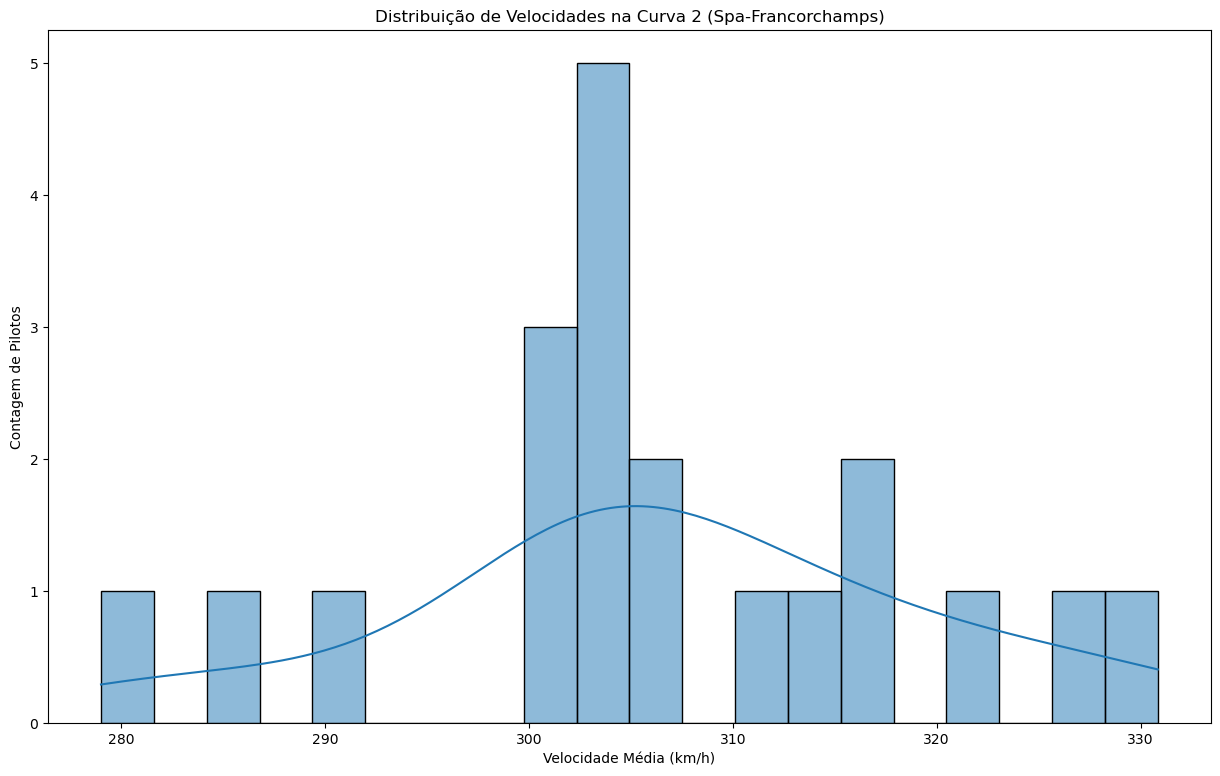

In [5]:
plt.figure(figsize=(15, 9))
sns.histplot(exemplo['curva 2'], kde=True, bins=20)
plt.title('Distribuição de Velocidades na Curva 2 (Spa-Francorchamps)')
plt.xlabel('Velocidade Média (km/h)')
plt.ylabel('Contagem de Pilotos')
plt.show()

##### Podemos observar a distribuição das velocidades de cada piloto na curva, com a grande maioria agrupando-se em uma faixa específica.

## Pré-processamento
Toda a etapa de pré-processamento foi realizada durante o processo de coleta dos dados, transformando os dados brutos da API num formato estruturado e pronto para análise. Tal etapa envolveu os seguintes passos:

Padronização da Volta de Referência: Para garantir uma comparação justa entre os pilotos, decidimos analisar apenas a volta mais rápida de cada piloto durante as sessões de qualificação (Q1, Q2 ou Q3). Esta decisão elimina variáveis externas como a degradação dos pneus, o peso do combustível e a gestão da bateria, permitindo-nos focar no desempenho máximo do conjunto carro/piloto.

Seleção e Delimitação das Curvas: As 88 curvas foram selecionadas manualmente a partir da análise da telemetria de um piloto de referência em cada um dos 17 circuitos. Cada curva foi definida por uma área geográfica (coordenadas x, y, z) que foi validada visualmente para garantir que apenas a secção de interesse estava a ser considerada.

Sincronização de Dados: Para cada volta, os dados de localização e de telemetria (velocidade, tempo, etc.) da API OpenF1 foram unidos e interpolados com base no tempo, criando um registo contínuo da performance do piloto.

Cálculo da Velocidade Média por Curva: O cálculo da velocidade foi um processo de várias etapas:
Primeiro, a distância euclidiana entre os pontos de telemetria foi usada para calcular a distância percorrida pelo piloto dentro da área de cada curva.
Esta distância "arbitrária" da API foi então escalada para quilômetros, comparando a distância total de uma volta completa com a distância real conhecida do circuito.
Finalmente, a velocidade média em cada curva foi calculada dividindo a distância percorrida na curva (em km) pelo tempo gasto pelo piloto nesse setor, resultando num valor em km/h.

Coleta de Dados Adicionais: Juntamente com as velocidades, a posição final e a fase da qualificação (Etapa) da volta mais rápida de cada piloto foram extraídas e adicionadas ao nosso conjunto de dados. Estas colunas foram cruciais para as análises subsequentes, como o cálculo do Z-Score e os modelos de regressão.

Consolidação: Este processo foi repetido para cada piloto em cada uma das 17 etapas, resultando nos arquivos .csv finais usados neste relatório.

## Perguntas:

### Qual a diferença entre as velocidades em uma qualificação sprint para uma qualificação normal?
Foram carregados dois conjuntos de dados: um correspondente à Qualificação Sprint e outro à Qualificação Principal.

Isolamos as colunas dos dataframes que correspondem às curvas.

Calculamos a variação percentual para cada piloto em cada curva, utilizando :
$$ \text{Variação \%} = \frac{(\text{Velocidade}_{\text{Principal}} - \text{Velocidade}_{\text{Sprint}})}{\text{Velocidade}_{\text{Sprint}}} \times 100 $$

Daí plotamos um heatmap para visualizar os dados de forma clara e os analisar:
Um percentual representa o valor da velocidade na curva na qualificação normal em relação ao valor na qualificação sprint. Valores vermelhos indicam aumento enquanto os azuis indicam diminuição. 

Por exemplo, um valor de 5,6% vermelho indica que a velocidade na curva durante a qualificação principal aumentou em 5,6% em relação à mesma velocidade na curva durante a qualificação sprint. Em termos mais simples, se durante a qualificação sprint a velocidade foi de 100 km/h, durante a qualificação normal foi de 105,6 km/h.


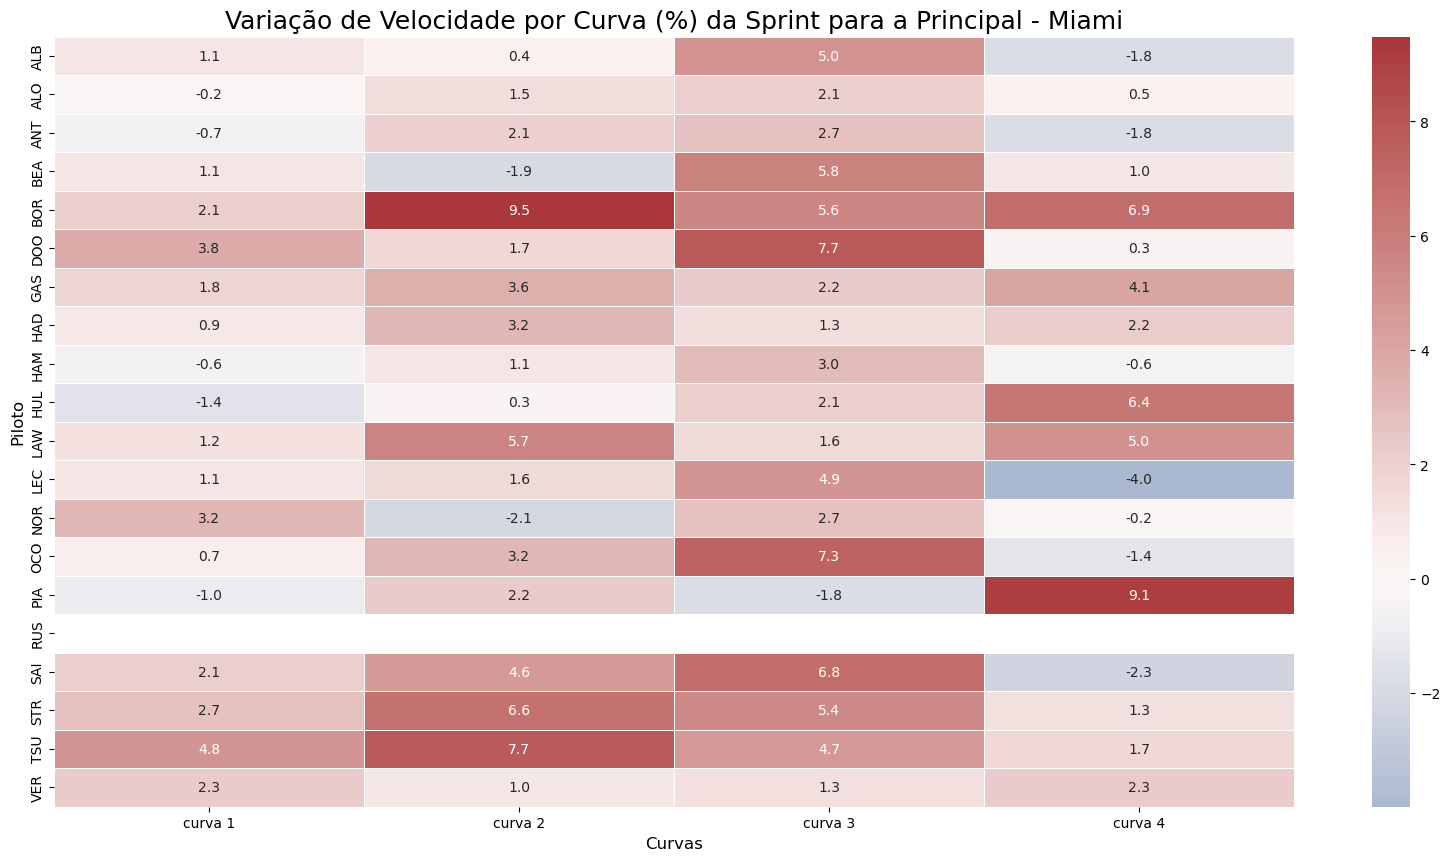

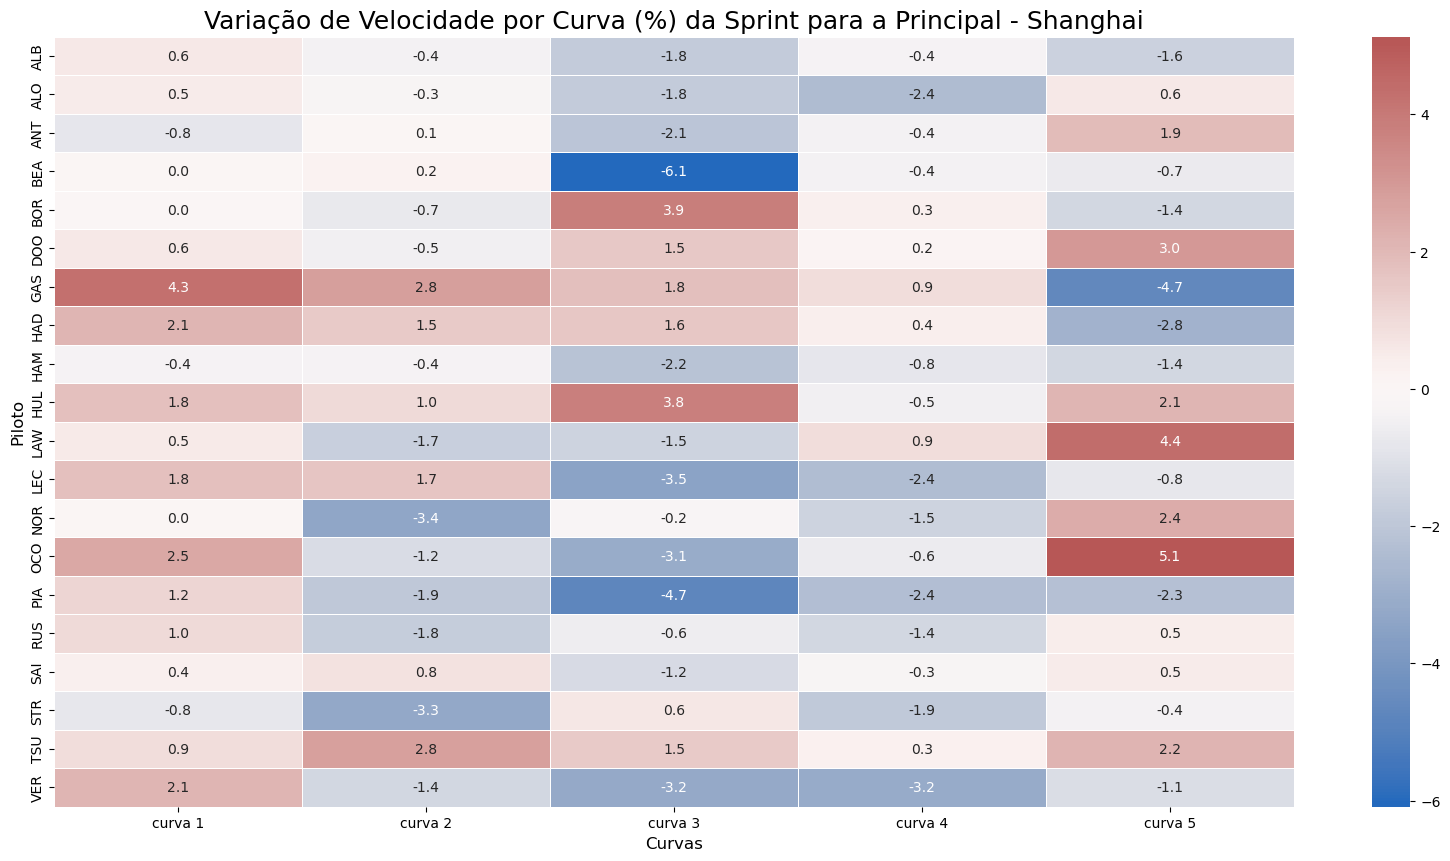

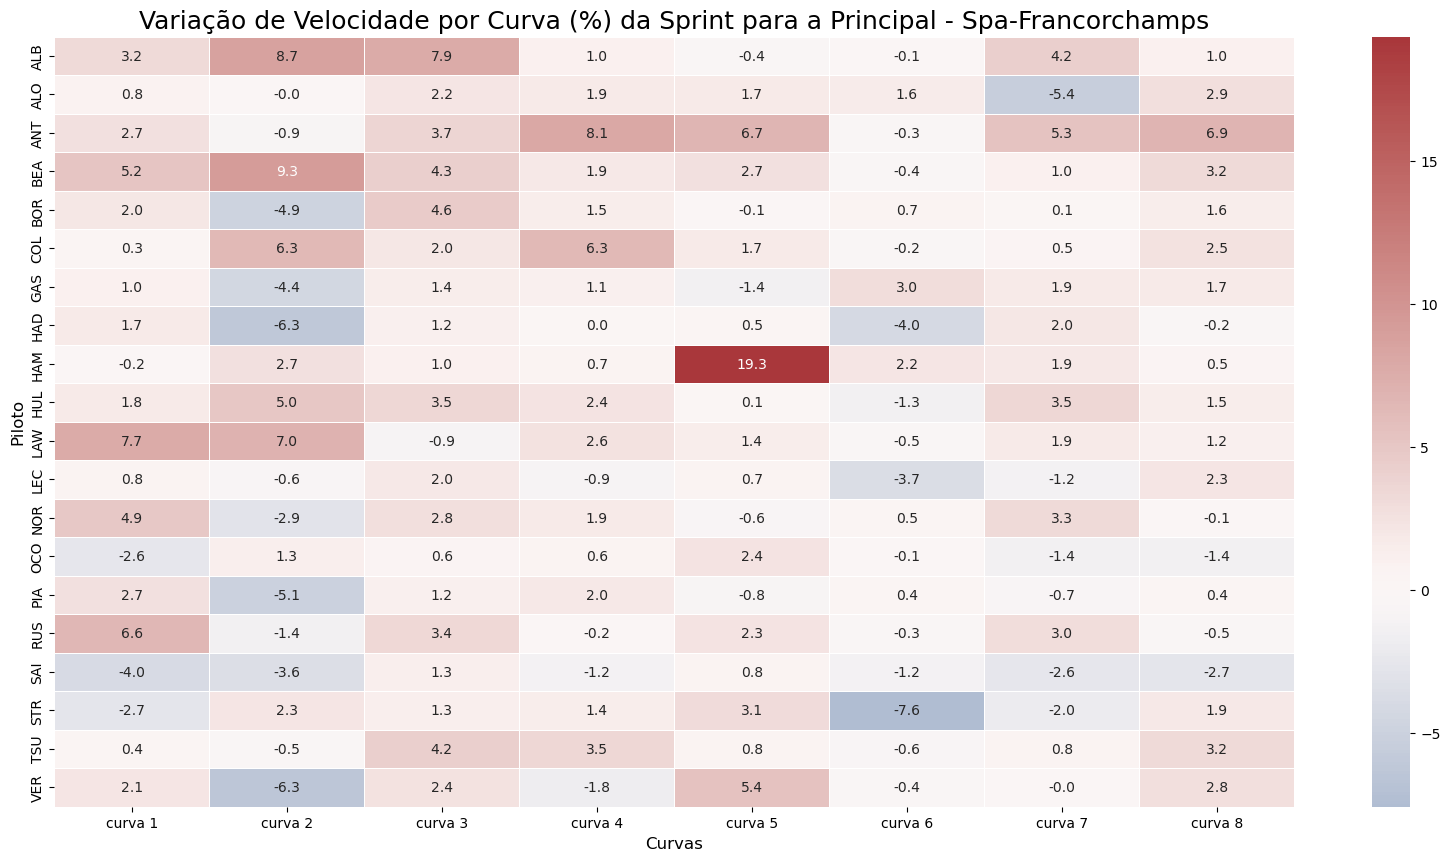

In [6]:
circuitos = [
    ('Miami', 'csvs/resultados_Miami.csv', 'csvs/resultados_Miami_S.csv'),
    ('Shanghai', 'csvs/resultados_Shanghai.csv', 'csvs/resultados_Shanghai_S.csv'),
    ('Spa-Francorchamps', 'csvs/resultados_Spa-Francorchamps.csv', 'csvs/resultados_Spa-Francorchamps_S.csv')]

for circuito_nome, arquivo_principal, arquivo_sprint in circuitos:
    
    principal = pd.read_csv(arquivo_principal)
    sprint = pd.read_csv(arquivo_sprint)

    colunas_curvas = [col for col in principal.columns if 'curva' in col]

    
    velocidades_principal = principal.groupby('name_acronym')[colunas_curvas].mean()
    velocidades_sprint = sprint.groupby('name_acronym')[colunas_curvas].mean()

    variacao_percentual = ((velocidades_principal - velocidades_sprint) / velocidades_sprint) * 100
    
    plt.figure(figsize=(20, 10))
    
    sns.heatmap(
        variacao_percentual, annot=True, fmt=".1f", cmap='vlag', center=0, linewidths=.5)
    
    plt.title(f'Variação de Velocidade por Curva (%) da Sprint para a Principal - {circuito_nome}', fontsize=18)
    plt.xlabel('Curvas', fontsize=12)
    plt.ylabel('Piloto', fontsize=12)
    plt.plot()

Observa-se que há 3 tipos de mudanças:

* Variação padrão (cerca de 2%), que representa uma evolução da pista, pequeno ajuste na configuração do carro ou adaptação do piloto.

* Correção de erros (grandes variações em curvas isoladas, cerca de 9%), que representa muito provavelmente a correção ou ocorrência de um erro do piloto na execução da curva.

* Mudança de configuração do carro (em áreas que mostram aumento moderado, cerca de 5%, em uma curva, e perda equivalente ou comparável em outra), o que mostra ajustes mais expressivos no carro, favorecendo setores específicos, mas afetando outros por consequência.

### Em quantas categorias podemos dividir as curvas?
Para isso, criamos um dataframe com as curvas de todas as etapas, utilizando a velocidade média dos pilotos como forma de unificar a existência de tal curva.
A partir do dataframe geral, tentamos analisar visualmente se era possível agrupar as curvas.

[]

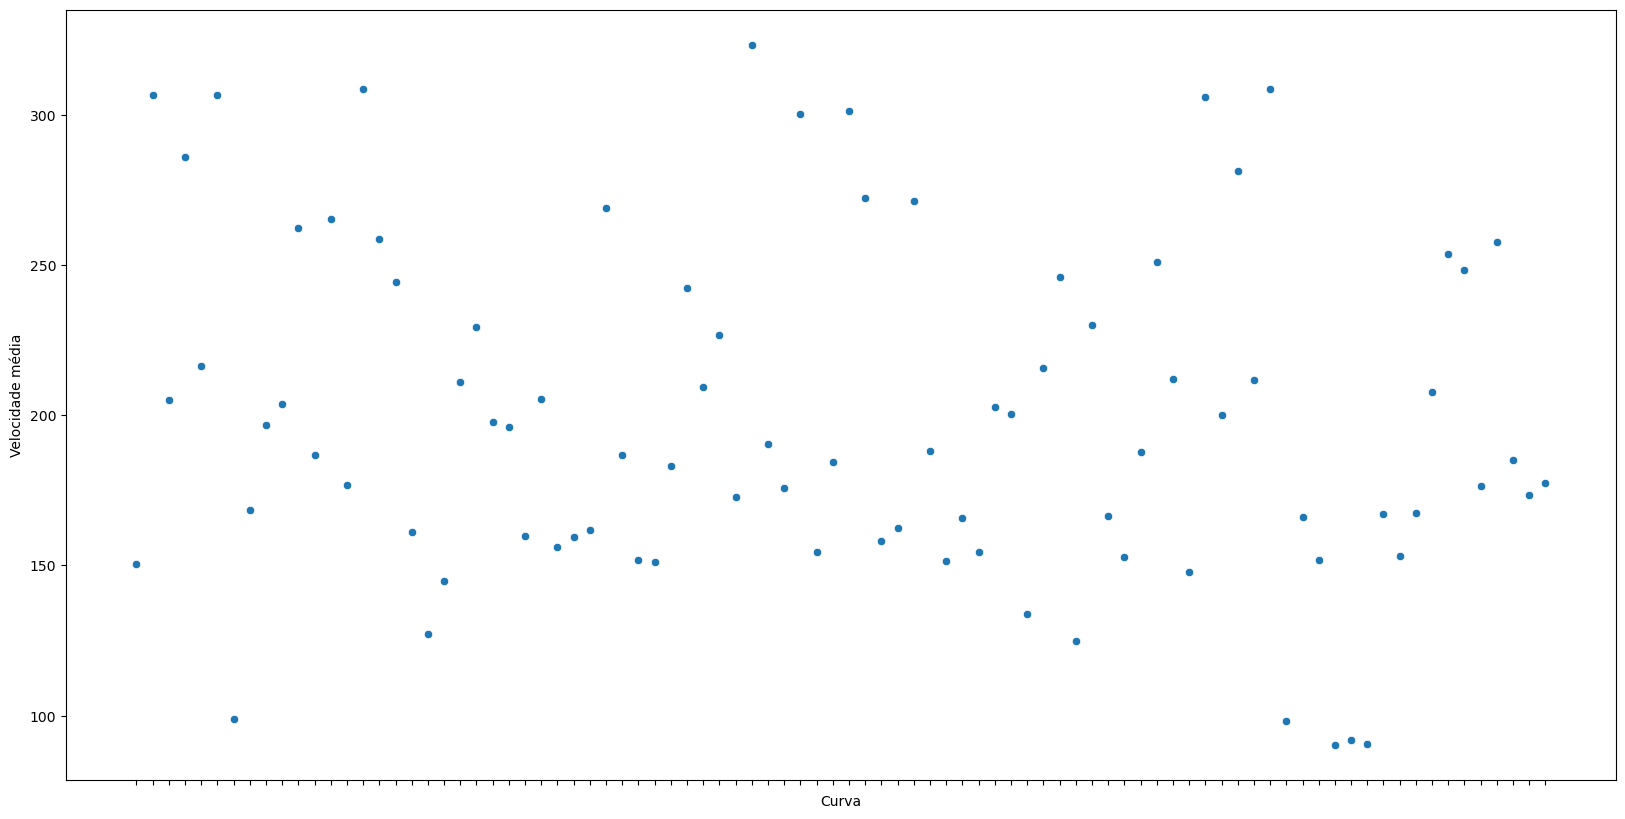

In [7]:
curvas = pd.DataFrame(columns=['Curva','Velocidade média'],)

for arquivo in os.listdir('./csvs'):
    
    if arquivo.endswith('.csv'):
        etapa = pd.read_csv("csvs/"+arquivo)
        index = etapa.columns.get_loc("Etapa")
        so_curvas = etapa.iloc[:, index + 1:]
        i = 1
        for coluna, velocidade in so_curvas.items():
            media = velocidade.mean()
            proximo_indice = len(curvas)
            curvas.loc[proximo_indice] = {
                'Curva': arquivo[11:-4:] + f"_curva_{i}", 
                'Velocidade média': media 
            }
            i+=1

            
plt.figure(figsize=(20,10))
graf = sns.scatterplot(data=curvas, x ='Curva', y='Velocidade média')
graf.set_xticklabels([])
graf.plot()

        



Conforme observamos no gráfico, não há dados relacionáveis nos quais possa ser utilizado uma técnica como o Kmeans, que era nosso intuito inicial.
Entretanto, notamos que há faixas de velocidades às quais podemos categorizar cada curva, e daí criamos um filtro:

* Curvas de alta velocidade: média >= 250
* Curvas de média/alta velocidade: média entre 250 e 200
* Curvas de média/baixa velocidade: média entre 200 e 150
* Curvas de baixa velocidade: média < 150

Separamos as curvas utilizando esse filtro, e contabilizamos para um gráfico de barras:

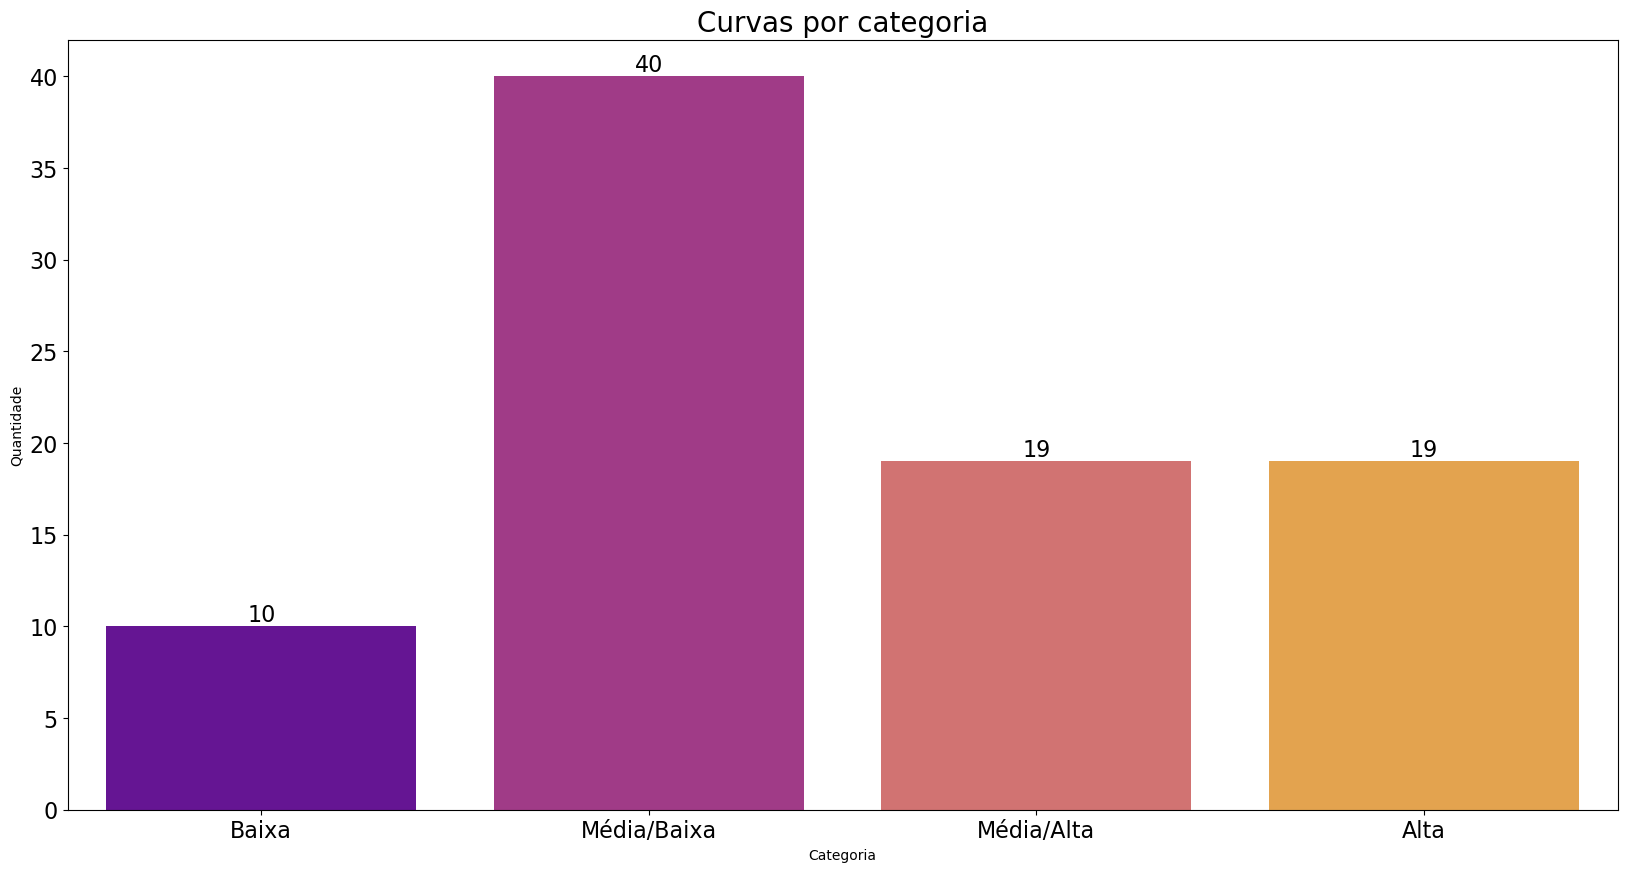

In [8]:
curvas_baixa = curvas[curvas["Velocidade média"]<150]
curvas_mediaB = curvas[(150<=curvas["Velocidade média"]) & (curvas["Velocidade média"]<200)]
curvas_mediaA = curvas[(200<=curvas["Velocidade média"]) & (curvas["Velocidade média"]<250)]
curvas_alta = curvas[250<=curvas["Velocidade média"]]

categorias = pd.DataFrame({"Categoria": ["Baixa","Média/Baixa", "Média/Alta", "Alta"], 
                                   "Quantidade" : [len(curvas_baixa), len(curvas_mediaB), len(curvas_mediaA), len(curvas_alta)]})
plt.figure(figsize=(20,10))
grafico = sns.barplot(data=categorias, x="Categoria",y="Quantidade",palette="plasma",hue="Categoria",legend=False)

for barra in grafico.containers:
    grafico.bar_label(barra, fmt="%d", fontsize=16)
grafico.tick_params(axis='x', labelsize=16) 
grafico.tick_params(axis='y', labelsize=16)
plt.title("Curvas por categoria", fontsize=20)
plt.show()


Após a contabilização de curvas em cada categoria, notamos que há um número muito maior de curvas na categoria Média/Baixa, o que pode ser interpretado como viés nos dados, ou somente uma tendência para as curvas nos circuitos em geral. Além disso, tal categorização é fundamental pois indica as características dos circuitos, e pode ser utilizado para análises referentes ao desempenho dos pilotos para cada situação.

### Qual o piloto melhor colocado em cada tipo de curva? E em geral?
Para garantir uma análise que seja justa com cada carro e piloto, foi utilizado o Z-score com base na média e desvio padrão dos pilotos que marcaram a sua melhor volta na mesma fase da qualificação (Q1, Q2 ou Q3), eliminando nuances como evolução da pista, como o emborrachamento e mudança de temperatura, e o fato de que a cada fase, 5 pilotos são eliminados da qualificação.
$$ \text{Z-score } = \frac{(\text{Velocidade}_{\text{Piloto}} - \text{Média}_{\text{Qn}})}{\text{Desvio padrão}_{\text{Qn}}} $$

Em seguida, são gerados novos dataframes com base nas categorias de curvas definidas na pergunta anterior, de modo que cada curva seja o z-score do piloto.

In [9]:
def categorizar_curva(velocidade):
        if velocidade < 150:
            return 'Baixa'
        elif 150 <= velocidade < 200:
            return 'Média Baixa'
        elif 200 <= velocidade < 250:
            return 'Média Alta'
        else:
            return 'Alta'
        
def analisar_desempenho_pilotos(etapa):

    colunas_piloto = ['driver_number', 'name_acronym', 'team_name', 'position', 'Etapa']
    colunas_curvas = [col for col in etapa.columns if col.startswith('curva')]
    categorias_curvas = {curva: categorizar_curva(etapa[curva].mean()) for curva in colunas_curvas}

    z_scores = etapa[colunas_piloto].copy()
    for curva in colunas_curvas:
        media_grupo = etapa.groupby('Etapa')[curva].transform('mean')
        std_grupo = etapa.groupby('Etapa')[curva].transform('std')
        z_scores[curva] = (etapa[curva] - media_grupo) / std_grupo
    
    filtro = {}
    categorias = ['Baixa', 'Média Baixa', 'Média Alta', 'Alta']

    for categoria in categorias:
        curvas_da_categoria = [c for c, cat in categorias_curvas.items() if cat == categoria]
        colunas_piloto_base = ['driver_number', 'name_acronym', 'team_name']
        df_categoria = z_scores[colunas_piloto_base + curvas_da_categoria]
        filtro[categoria] = df_categoria

    return filtro

resultados_por_categoria = {
    'Baixa': pd.DataFrame(),
    'Média Baixa': pd.DataFrame(),
    'Média Alta': pd.DataFrame(),
    'Alta': pd.DataFrame()}

colunas_piloto = ['driver_number', 'name_acronym', 'team_name']

for arquivo in os.listdir('./csvs'):
    
    if arquivo.endswith('.csv'):
        etapa = pd.read_csv("csvs/"+arquivo)
        nome_circuito = os.path.basename(arquivo).replace('resultados_', '').replace('.csv', '')
        completo = analisar_desempenho_pilotos(etapa)

        for categoria, df_etapa in completo.items():
            colunas_curva_etapa = [c for c in df_etapa.columns if c.startswith('curva')]
            mapa_renomeacao = {col: f"{col}_{nome_circuito}" for col in colunas_curva_etapa}
            df_etapa_renomeado = df_etapa.rename(columns=mapa_renomeacao)

            if resultados_por_categoria[categoria].empty:
                resultados_por_categoria[categoria] = df_etapa_renomeado
            else:
                resultados_por_categoria[categoria] = pd.merge(resultados_por_categoria[categoria],df_etapa_renomeado,on=colunas_piloto,how='outer')

scores_baixa = resultados_por_categoria.get('Baixa')
scores_mediaB = resultados_por_categoria.get('Média Baixa')
scores_mediaA = resultados_por_categoria.get('Média Alta')
scores_alta = resultados_por_categoria.get('Alta')


Em sequência, verificamos a estrutura de cada dataframe. Note que há mais de dois pilotos em algumas equipes, que realizaram trocas durante a temporada, mas que vamos considerar cada conjunto piloto-equipe como sendo diferentes.

In [10]:
scores_baixa

,driver_number,name_acronym,team_name,curva 7_Spa-Francorchamps,curva 2_Spielberg,curva 3_Spielberg,curva 5_Sakhir,curva 3_Suzuka,curva 1_Spa-Francorchamps_S,curva 7_Spa-Francorchamps_S,curva 2_Monte Carlo,curva 3_Monte Carlo,curva 4_Monte Carlo
0,1,VER,Red Bull Racing,1.260854,0.554737,1.100205,0.825054,0.251751,-0.397393,1.570555,0.177502,-0.523152,-0.412506
1,4,NOR,McLaren,0.179695,0.270501,0.712328,-2.383174,0.741249,-0.642913,-1.259781,1.052786,2.257899,1.999484
2,5,BOR,Kick Sauber,1.116581,1.462693,0.952519,-1.594670,-0.391052,0.326398,1.564866,-1.097340,1.084960,1.655708
3,6,HAD,Racing Bulls,1.219643,0.244656,2.415729,-0.793497,-0.070403,-0.228528,-0.281396,-0.246743,-0.653294,0.543267
4,7,DOO,Alpine,NaN,NaN,NaN,-0.329730,0.333148,NaN,NaN,NaN,NaN,NaN
5,10,GAS,Alpine,-1.720523,-0.316717,-0.441876,0.216241,-0.225634,0.151663,-1.130992,1.416797,-0.726411,0.002472
6,12,ANT,Mercedes,1.397293,-0.794342,-1.246777,-0.003301,0.264908,-1.172175,-0.993127,-0.523237,-1.367098,-0.391108
7,14,ALO,Aston Martin,-1.858590,-0.906371,-0.364071,0.532757,-1.744346,0.513432,1.225733,-0.645157,1.012144,0.200369
8,16,LEC,Ferrari,-1.132808,0.688738,-0.374912,0.116052,0.716411,0.423654,0.148774,1.637963,-0.746982,-0.513301
9,18,STR,Aston Martin,0.548373,-0.572936,-0.966106,-1.008505,0.463698,1.212366,1.619836,1.316614,0.395529,-0.937588


In [11]:
scores_mediaB

,driver_number,name_acronym,team_name,curva 1_Spa-Francorchamps,curva 8_Spa-Francorchamps,curva 1_Catalunya,curva 4_Catalunya,curva 1_Jeddah,curva 1_Spielberg,curva 1_Montreal,...,curva 3_Spa-Francorchamps_S,curva 8_Spa-Francorchamps_S,curva 1_Monte Carlo,curva 1_Hungaroring,curva 2_Hungaroring,curva 3_Hungaroring,curva 2_Imola,curva 4_Imola,curva 5_Imola,curva 6_Imola
0,1,VER,Red Bull Racing,-0.502667,1.311984,-0.731682,0.632429,0.062951,-0.179400,1.770597,...,-0.207804,0.184955,0.083213,0.915965,-1.180112,-0.540355,0.643274,0.181181,-0.341693,-0.072223
1,4,NOR,McLaren,1.428802,0.216726,2.428305,-0.147417,0.682738,-0.339715,-0.707840,...,1.592818,1.390838,0.013223,1.297612,1.114010,2.055333,0.447017,-1.506648,0.936545,1.200309
2,5,BOR,Kick Sauber,-0.199068,0.952419,-0.466207,-0.026022,-0.953287,0.343506,0.059785,...,-0.626056,1.172038,-0.971093,0.282202,1.799892,0.024355,-1.164899,-0.965035,-2.338644,-1.876004
3,6,HAD,Racing Bulls,-0.245688,0.705136,-0.334250,-0.046142,-0.746837,1.689996,-1.017481,...,0.266250,0.557962,-0.223579,0.062418,-0.576005,0.513796,0.517239,0.636742,0.897411,0.731356
4,7,DOO,Alpine,NaN,NaN,NaN,NaN,-1.144254,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10,GAS,Alpine,-1.455858,-0.730287,-0.000151,0.701887,1.056486,-0.917177,0.285514,...,-0.006968,-1.562539,0.191441,-0.652769,-0.171529,1.038398,-0.647344,-0.901824,0.338452,0.848068
6,12,ANT,Mercedes,0.172818,0.628021,-0.319213,-1.625870,0.887816,1.543808,0.495167,...,-0.984304,-1.311243,-0.446648,-1.404813,-1.013712,-0.211771,0.070423,-0.045418,0.233877,0.473930
7,14,ALO,Aston Martin,0.439197,0.606941,0.043458,1.421771,0.021159,-0.790736,0.230122,...,-0.144171,0.304878,-1.377317,0.027344,1.005763,-0.516078,-0.141785,-0.499173,-1.820372,0.745444
8,16,LEC,Ferrari,-0.090921,-0.586518,-0.301404,-1.489487,-1.177095,0.937740,0.928958,...,1.124529,-1.153994,0.410292,NaN,NaN,NaN,-0.297523,-0.154710,0.406854,-1.049209
9,18,STR,Aston Martin,-0.918169,-1.278911,0.196492,0.800895,0.214583,-0.691989,-0.606413,...,-0.925543,-0.675546,1.200538,-1.766327,1.040573,-0.348310,2.104895,-1.059165,0.507454,0.546047


In [12]:
scores_mediaA

,driver_number,name_acronym,team_name,curva 3_Spa-Francorchamps,curva 5_Spa-Francorchamps,curva 2_Catalunya,curva 4_Jeddah,curva 4_Spielberg,curva 5_Spielberg,curva 4_Montreal,...,curva 1_Melbourne,curva 3_Sakhir,curva 4_Sakhir,curva 1_Suzuka,curva 2_Suzuka,curva 4_Suzuka,curva 4_Miami,curva 5_Spa-Francorchamps_S,curva 4_Hungaroring,curva 1_Imola
0,1,VER,Red Bull Racing,-0.847920,1.354684,0.374821,-1.478324,0.433467,-1.596138,0.824984,...,-0.569530,-0.738224,-1.284295,0.456721,0.666556,1.117734,1.355987,-0.847959,-0.279271,1.816217
1,4,NOR,McLaren,1.407466,-0.395296,1.992481,1.642162,0.308422,-0.238796,1.457740,...,1.147428,1.743753,0.327812,0.624067,1.193515,1.304570,-0.019132,0.608121,1.911382,-0.174195
2,5,BOR,Kick Sauber,1.117976,0.211638,-1.040737,-1.431326,-1.337746,0.437154,1.018796,...,0.717050,0.667787,1.402757,1.699239,-1.823076,-0.948833,0.097802,1.294389,0.860306,-0.836029
3,6,HAD,Racing Bulls,1.022521,1.091915,0.432108,-1.359115,0.515316,1.718843,-0.629585,...,-0.996046,-1.095062,0.973463,0.194689,-0.777039,0.285548,-0.370734,0.944258,-0.613919,-1.329265
4,7,DOO,Alpine,NaN,NaN,NaN,1.001277,NaN,NaN,NaN,...,0.748354,0.864752,-1.024577,-1.230620,1.071928,0.749592,-0.796166,NaN,NaN,NaN
5,10,GAS,Alpine,-1.279541,-1.779942,-1.316606,1.454713,1.309075,1.059021,-0.466878,...,-0.393085,0.054840,1.683753,0.300049,-1.347369,0.049409,0.362295,0.176020,-0.177825,-0.111317
6,12,ANT,Mercedes,-0.544963,-0.688604,-0.013234,-0.054930,0.134451,-0.209555,-0.951034,...,-1.013597,0.216023,-0.664208,0.108136,-0.479280,-1.333599,-1.434238,-0.493940,-0.333073,1.112223
7,14,ALO,Aston Martin,-0.558512,1.593078,-1.591563,-0.042572,-0.539247,0.309518,-1.211247,...,0.827167,-0.234139,0.807837,-1.204735,1.333120,0.104294,0.100117,0.824106,1.176163,-0.950985
8,16,LEC,Ferrari,-0.011886,0.043927,-0.166919,0.506413,0.340265,0.218423,-0.139417,...,1.541547,0.256576,-0.539000,0.102509,0.595802,-0.989048,0.954963,0.304650,NaN,0.231637
9,18,STR,Aston Martin,-1.453860,-0.319404,0.451571,0.621292,-0.048104,1.271004,-0.693349,...,-0.322757,-1.202614,-0.563930,0.215566,0.540823,-0.743589,-0.990489,0.196703,-0.775493,0.377374


In [13]:
scores_alta

,driver_number,name_acronym,team_name,curva 2_Spa-Francorchamps,curva 4_Spa-Francorchamps,curva 6_Spa-Francorchamps,curva 3_Catalunya,curva 5_Catalunya,curva 2_Jeddah,curva 3_Jeddah,...,curva 2_Silverstone,curva 5_Silverstone,curva 6_Silverstone,curva 3_Shanghai_S,curva 3_Miami,curva 2_Spa-Francorchamps_S,curva 4_Spa-Francorchamps_S,curva 6_Spa-Francorchamps_S,curva 5_Hungaroring,curva 3_Imola
0,1,VER,Red Bull Racing,-0.594581,0.801444,0.775502,0.668388,0.144161,-1.232943,0.518778,...,-0.115815,-0.046972,-1.213428,0.849144,1.682456,1.502545,1.960173,0.834622,1.683024,-1.301446
1,4,NOR,McLaren,-0.499922,0.893364,0.627286,1.912371,-0.286992,-0.108810,0.686297,...,1.092664,0.977055,0.051986,-0.002481,-1.347015,0.545658,0.268960,-0.271838,0.302255,0.865555
2,5,BOR,Kick Sauber,-0.759858,-0.889468,0.205288,-0.809930,0.895950,0.461956,-0.231208,...,0.617533,0.051497,0.072790,-0.944594,1.556255,-0.391965,-1.344102,-0.313959,-1.123721,1.163749
3,6,HAD,Racing Bulls,-1.477275,0.482526,-1.638399,1.381658,0.378055,0.941085,-1.290729,...,-0.704643,-1.806464,-1.340820,-0.120497,0.063459,-0.800329,0.242890,0.840663,0.553179,1.267236
4,7,DOO,Alpine,NaN,NaN,NaN,NaN,NaN,1.591076,-1.731788,...,NaN,NaN,NaN,0.483287,0.549413,NaN,NaN,NaN,NaN,NaN
5,10,GAS,Alpine,0.258869,0.013886,1.009687,-0.919319,0.135923,0.319985,-0.356480,...,1.390538,-1.048860,-0.904201,0.320255,1.419621,1.778129,1.119395,-1.055926,-0.409947,-0.591709
6,12,ANT,Mercedes,-0.428460,0.333673,0.526005,-0.084182,-0.099896,-0.873542,0.573727,...,-1.210777,-0.755391,-0.855043,-0.326534,0.455266,1.014644,-2.023600,-0.022373,0.309765,0.433627
7,14,ALO,Aston Martin,-0.677376,-0.760700,-0.156316,-1.126286,1.118599,-1.327027,-0.437607,...,0.032094,0.100638,0.281445,0.526697,0.237552,0.226786,0.168243,-0.943927,0.373477,0.113524
8,16,LEC,Ferrari,-0.400795,-1.095799,-1.415957,-0.482554,-1.223350,0.019714,-1.018089,...,-0.206682,-0.725298,1.905017,0.490892,0.801501,0.004973,-0.542544,0.764692,NaN,0.276914
9,18,STR,Aston Martin,-1.109131,-0.825616,-1.670749,-1.655139,0.976291,-0.210669,1.010288,...,0.435806,0.910438,-0.734270,-0.822594,-1.321597,-1.602341,0.350685,2.007400,0.174199,-0.506456


Para a avaliação dos pilotos de forma geral, construímos um dataframe contendo a média dos dataframes anteriores.

In [14]:
scores_geral = scores_mediaB[colunas_piloto].copy()
dataframes = [scores_baixa,scores_mediaB, scores_mediaA,scores_alta ]
for i in range(4):
    colunas_zscore = [col for col in dataframes[i].columns if col.startswith('curva')]
    scores_geral[f'Média {i+1}'] = dataframes[i][colunas_zscore].mean(axis=1)
scores_geral

,driver_number,name_acronym,team_name,Média 1,Média 2,Média 3,Média 4
0,1,VER,Red Bull Racing,0.440761,0.153339,0.101960,0.526821
1,4,NOR,McLaren,0.292807,0.595165,0.729929,0.312442
2,5,BOR,Kick Sauber,0.508066,-0.178683,0.162106,-0.026304
3,6,HAD,Racing Bulls,0.214943,0.010020,-0.053598,-0.096511
4,7,DOO,Alpine,0.001709,-0.158314,0.123083,0.109551
5,10,GAS,Alpine,-0.277498,-0.060719,-0.016870,0.152048
6,12,ANT,Mercedes,-0.482897,-0.083507,-0.333010,-0.284216
7,14,ALO,Aston Martin,-0.203410,-0.118120,0.072188,-0.142360
8,16,LEC,Ferrari,0.096359,-0.240799,0.261879,-0.178452
9,18,STR,Aston Martin,0.207128,-0.074984,-0.275435,-0.199518


Com os dataframes prontos, vamos criar gráficos para comparar o desempenho de cada piloto em cada categoria de curva.


/tmp/ipykernel_6003/3562683271.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_xticklabels(labels_novos)
/tmp/ipykernel_6003/3562683271.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_xticklabels(labels_novos)
/tmp/ipykernel_6003/3562683271.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_xticklabels(labels_novos)
/tmp/ipykernel_6003/3562683271.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_xticklabels(labels_novos)
/tmp/ipykernel_6003/3562683271.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.

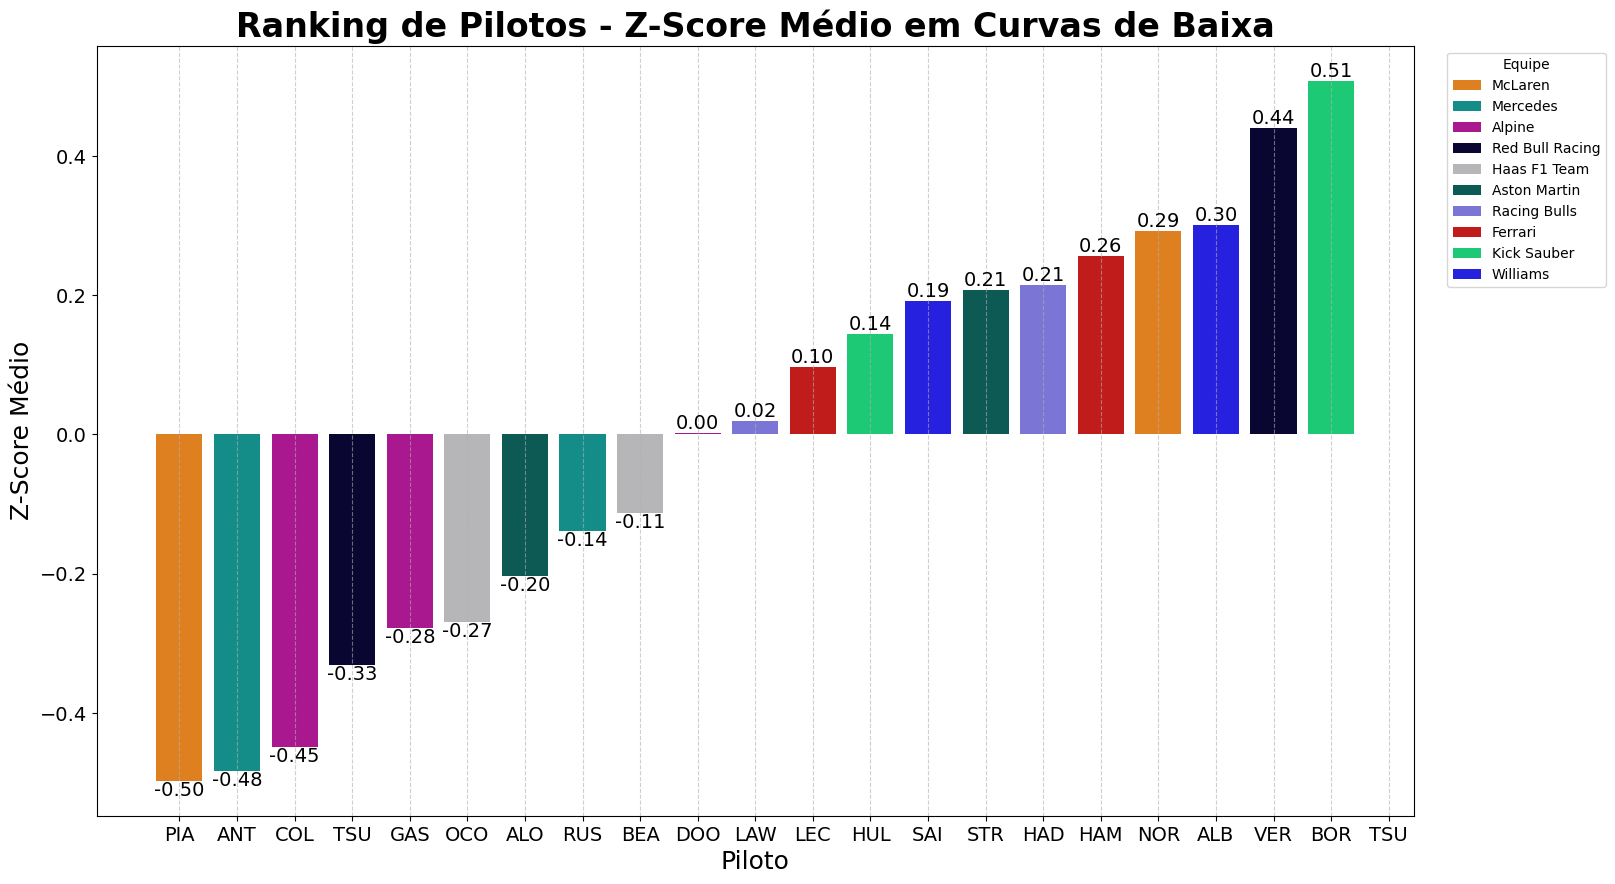

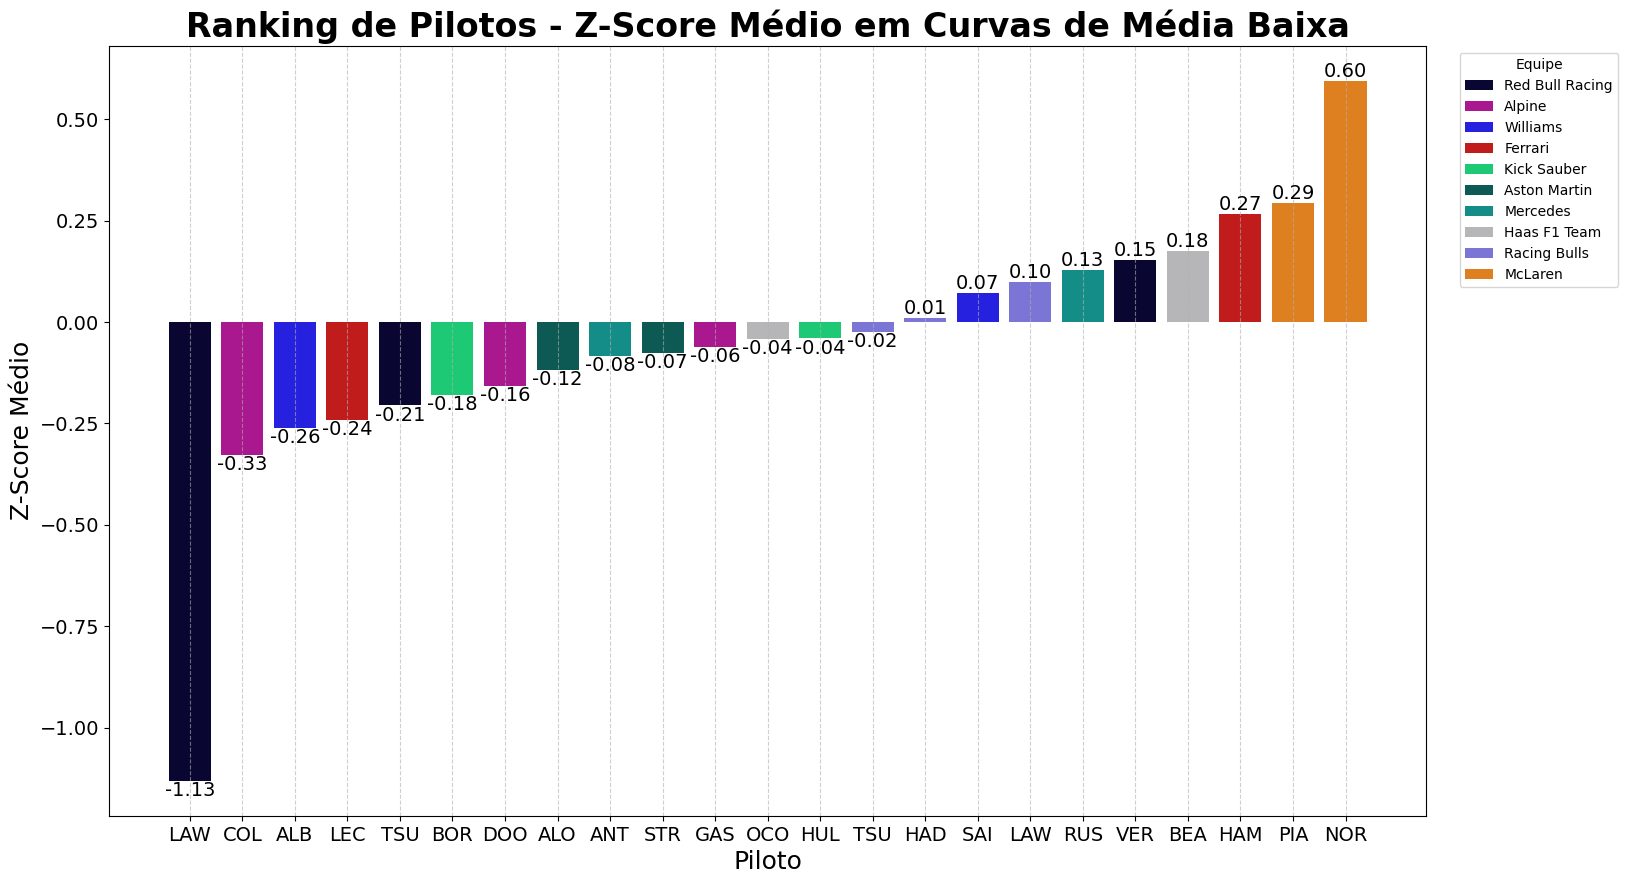

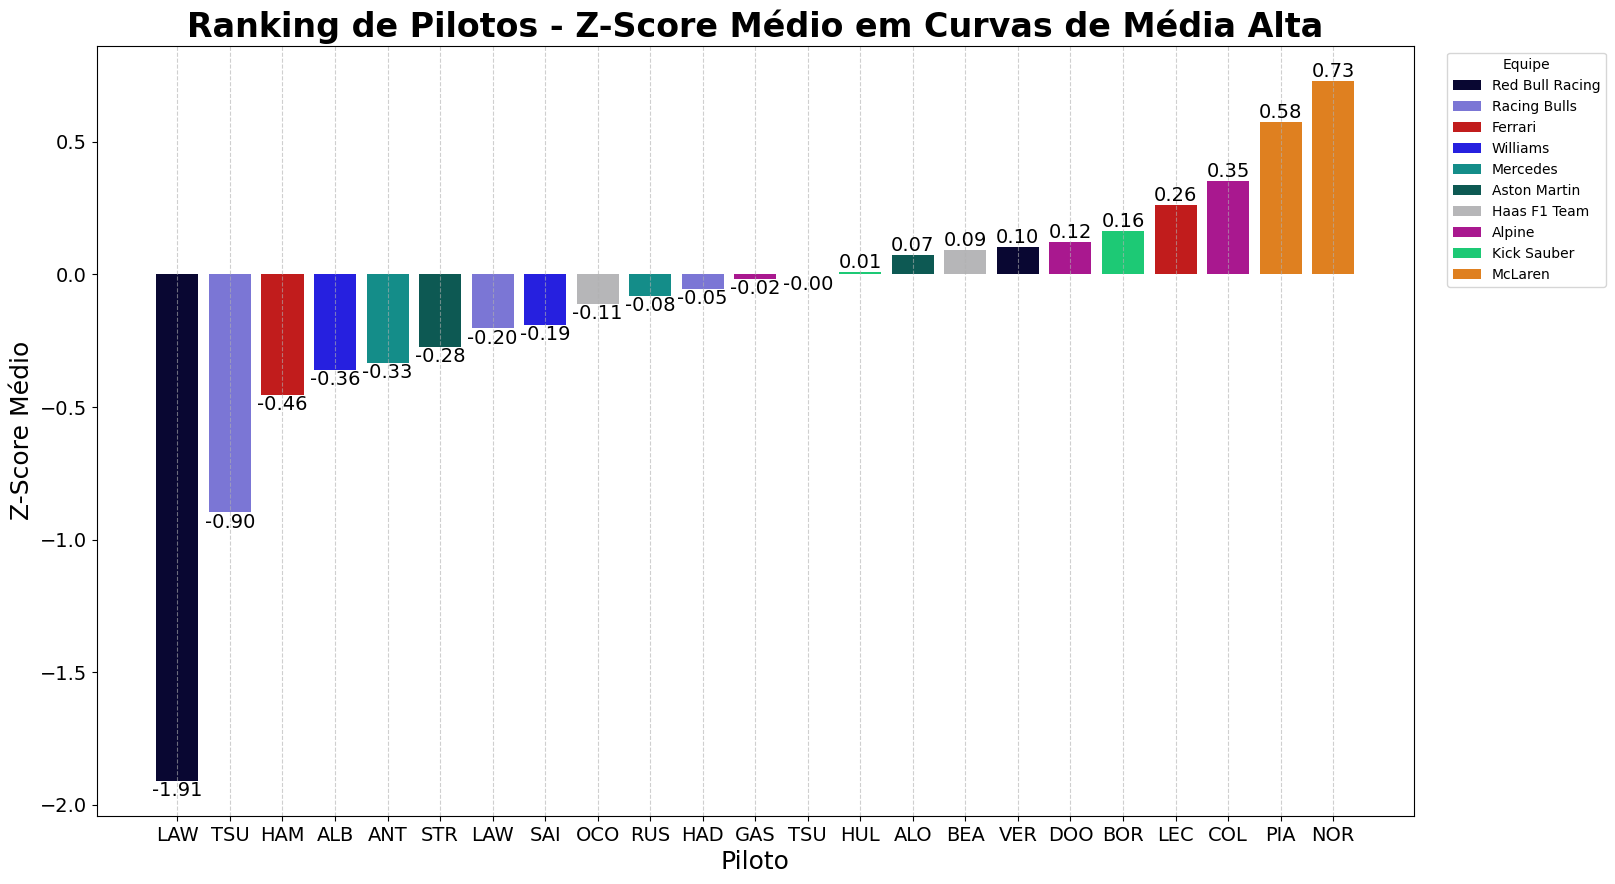

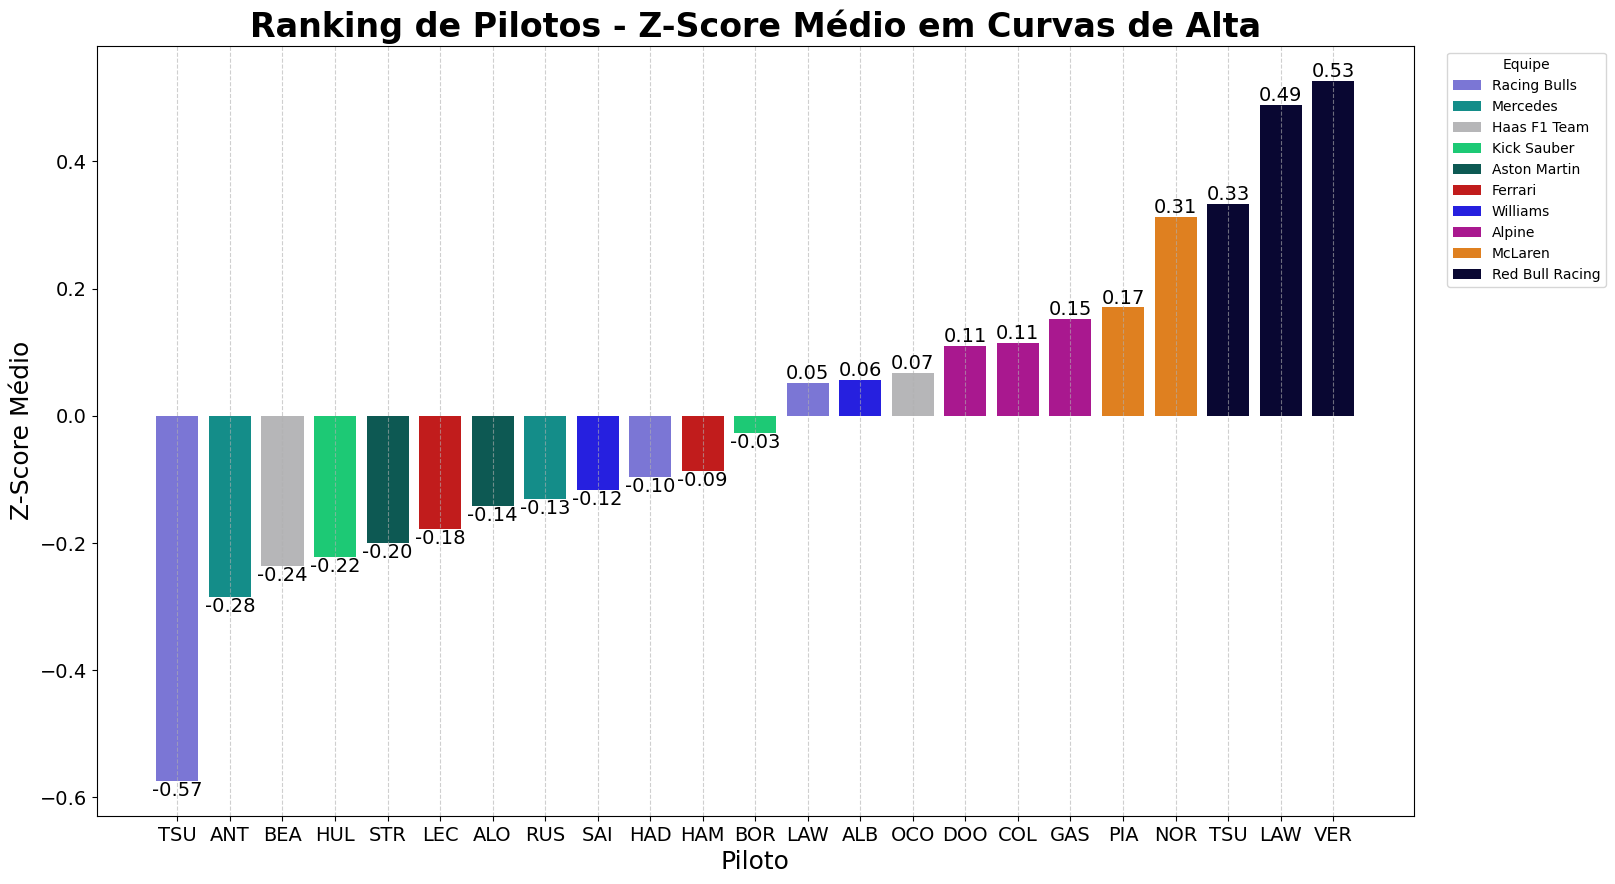

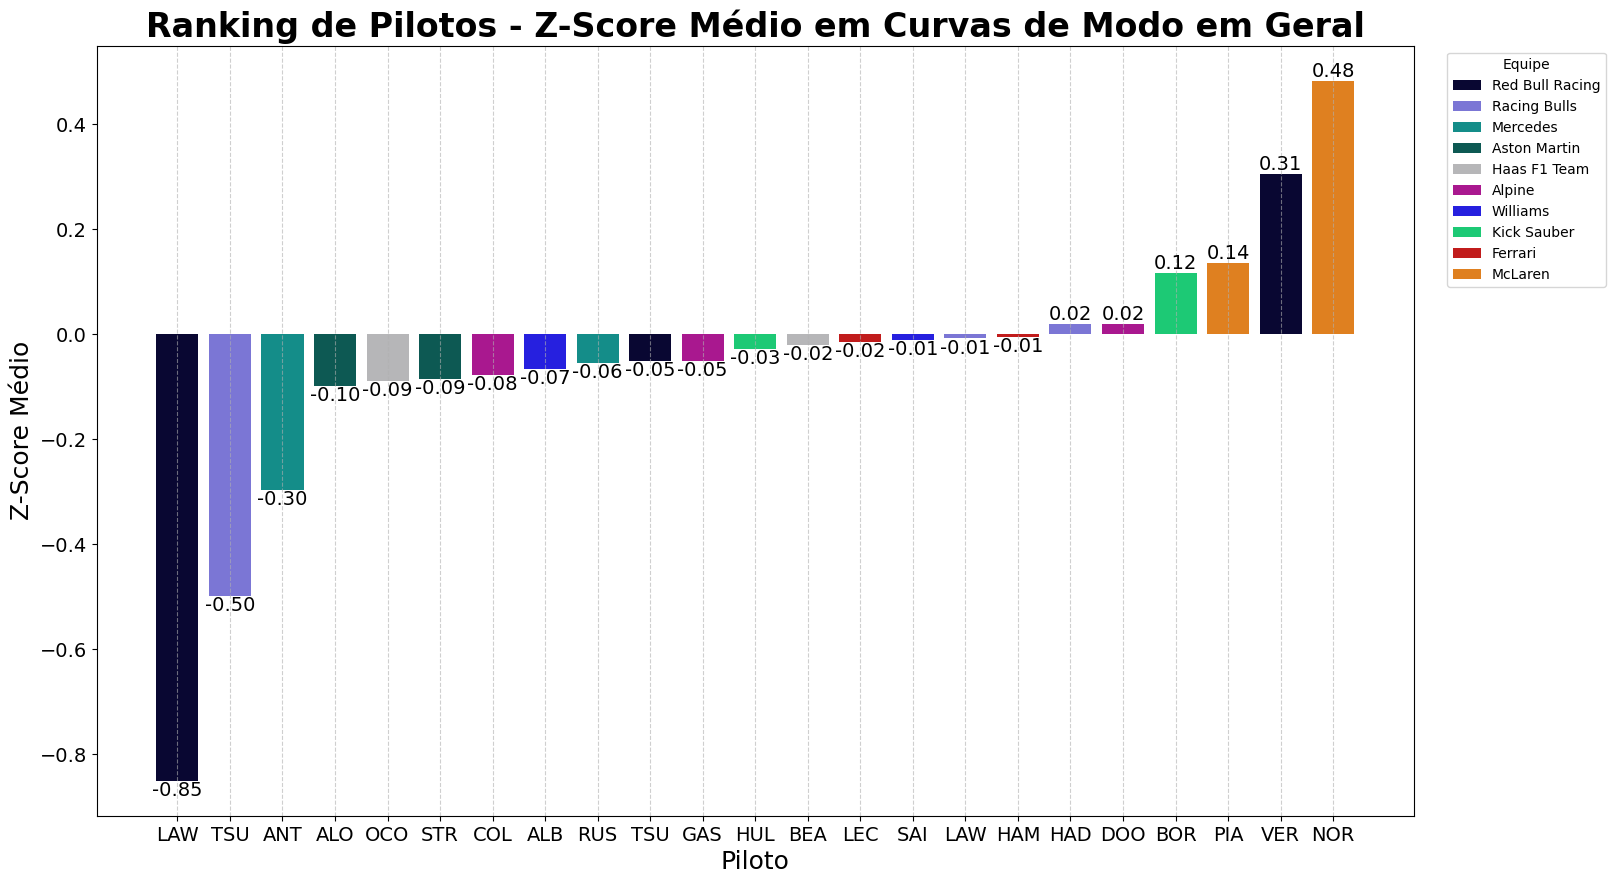

In [15]:
def criar_grafico_ranking(scores, categoria, cores):

    colunas_zscore = [col for col in scores.columns if col.startswith('curva') or col.startswith('Média')]

    scores['z_score_medio'] = scores[colunas_zscore].mean(axis=1)
    scores['piloto_equipe'] = scores['name_acronym'] + ' (' + scores['team_name'] + ')'
    ordenado = scores.sort_values(by='z_score_medio', ascending=True)
    
    plt.figure(figsize=(17, 10))
    grafico = sns.barplot(
        data=ordenado,
        x='piloto_equipe',y='z_score_medio', hue='team_name', palette=cores)
    
    for barra in grafico.containers:
        grafico.bar_label(barra, fmt="%.2f", fontsize=14)
    plt.title(f'Ranking de Pilotos - Z-Score Médio em Curvas de {categoria}', fontsize=24, weight='bold')
    plt.xlabel('Piloto', fontsize=18)
    plt.ylabel('Z-Score Médio', fontsize=18)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend(title='Equipe', bbox_to_anchor=(1.02, 1), loc='upper left')
    labels_atuais = [item.get_text() for item in grafico.get_xticklabels()]
    labels_novos = [label.split(' ')[0] for label in labels_atuais]
    grafico.set_xticklabels(labels_novos)


    plt.plot()

cores = {
    'McLaren': '#FF8000',
    'Ferrari': '#DC0000',
    'Red Bull Racing': "#020039",
    'Mercedes': '#00A19C',
    'Williams': "#0800FF",
    'Kick Sauber': '#00E676',
    'Racing Bulls': "#6D66E5",
    'Haas F1 Team': '#B6B6B8',
    'Alpine': "#C1009E",
    'Aston Martin': '#00665E'
}
criar_grafico_ranking(scores_baixa,'Baixa',cores)
criar_grafico_ranking(scores_mediaB,'Média Baixa',cores)
criar_grafico_ranking(scores_mediaA,'Média Alta',cores)
criar_grafico_ranking(scores_alta,'Alta',cores)
criar_grafico_ranking(scores_geral,'Modo em Geral',cores)


A análise dos gráficos nos permite não apenas destacar as especialidades de cada piloto, como atestar a dominância de uma equipe em geral.
Percebe-se que a equipe Mclaren domina nas curvas de modo geral, especialmente as de Média velocidade. Em contraponto, a equipe Red Bull Racing esboça reações em curvas de Baixa e Alta velocidade.

O surgimento de Gabriel Bortoleto como o piloto melhor colocado em curvas de Baixa velocidade é uma surpresa, dado que ele está em uma equipe que historicamente desempenha mal, e é um novato.

Lando Norris domina nas curvas de Média/Baixa e Média/Alta velocidades, seguido de seu companheiro de equipe, Oscar Piastri, demonstrando não só que tende a ser mais habilidoso nas curvas que seu rival de equipe, mas que possui um carro bem ajustado.

Max Verstappen domina as curvas de Alta velocidade e, seguido de seus companheiros de equipe, mesmo após a troca de pilotos, mostra que o carro tem o ajuste fino para esse tipo de curva.

Lando Norris é o piloto com maior pontuação no ranking geral, seguido de Max Verstappen e Oscar Piastri, refletindo em partes os campeonatos atual e o do ano passado, no qual o título foi disputado entre Lando e Max, e no atual, a colocação está em Oscar liderando, Lando em segundo e Max em terceiro. 

### Como foi a evolução de pilotos novatos ao longo da temporada?
Separamos os 7 pilotos novatos que começaram na Formula 1 nesse ano, ou com pouca experiência: 

* Gabriel Bortoleto
* Isack Hadjar
* Ollie Bearman
* Andrea Kimi Antonelli
* Jack Doohan
* Franco Colapinto
* Liam Lawson

E organizamos as etapas tem ordem cronológica.

Depois, criamos um dataframe com a mesma forma de avaliação de z-score da pergunta anterior, calculando a respectiva média etapa a etapa, contendo apenas os pilotos novatos.

Por fim, exibimos o dataframe para inspeção.



In [16]:
novatos = ['BOR', 'HAD', 'BEA','ANT', 'DOO', 'COL', 'LAW']
ordem_cronologica = [
    'csvs/resultados_Melbourne.csv',
    'csvs/resultados_Shanghai_S.csv',
    'csvs/resultados_Shanghai.csv',
    'csvs/resultados_Suzuka.csv',
    'csvs/resultados_Sakhir.csv',
    'csvs/resultados_Jeddah.csv',
    'csvs/resultados_Miami_S.csv',
    'csvs/resultados_Miami.csv',
    'csvs/resultados_Imola.csv',
    'csvs/resultados_Monte Carlo.csv',
    'csvs/resultados_Catalunya.csv',
    'csvs/resultados_Montreal.csv',
    'csvs/resultados_Spielberg.csv',
    'csvs/resultados_Silverstone.csv',
    'csvs/resultados_Spa-Francorchamps_S.csv',
    'csvs/resultados_Spa-Francorchamps.csv',
    'csvs/resultados_Hungaroring.csv',
]
evolucao_resultados = pd.DataFrame()


def calcular_zscore_medio_pilotos(etapa, pilotos,nome_etapa):
    zscores = etapa.copy()
    colunas_curvas = [col for col in etapa.columns if col.startswith('curva')]
    for curva in colunas_curvas:
        media_etapa = zscores.groupby('Etapa')[curva].transform('mean')
        std_etapa = zscores.groupby('Etapa')[curva].transform('std')
        zscores[curva] = (zscores[curva] - media_etapa).divide(std_etapa).fillna(0)
    
    filtrado = zscores[zscores['name_acronym'].isin(pilotos)].copy()
    filtrado[f'{nome_etapa}'] = filtrado[colunas_curvas].mean(axis=1)
    
    return filtrado[['name_acronym', f'{nome_etapa}']]

for arquivo in ordem_cronologica:
    etapa = pd.read_csv(arquivo)
    nome_etapa = os.path.basename(arquivo).replace('resultados_', '').replace('.csv', '').capitalize()
    
    if evolucao_resultados.empty:
        evolucao_resultados = calcular_zscore_medio_pilotos(etapa,novatos,nome_etapa)
    else:
        evolucao_resultados = pd.merge(evolucao_resultados,calcular_zscore_medio_pilotos(etapa,novatos,nome_etapa), on=['name_acronym'],how='outer')

evolucao_resultados = evolucao_resultados.set_index('name_acronym')
evolucao_resultados

,Melbourne,Shanghai_s,Shanghai,Suzuka,Sakhir,Jeddah,Miami_s,Miami,Imola,Monte carlo,Catalunya,Montreal,Spielberg,Silverstone,Spa-francorchamps_s,Spa-francorchamps,Hungaroring
name_acronym,,,,,,,,,,,,,,,,,
ANT,-0.484091,-0.077194,-0.066096,-0.279890,0.024921,0.133268,0.161399,-0.137409,0.379777,-0.682023,-0.428479,-0.482633,-0.114483,-0.629433,-0.748265,0.174473,-0.530721
BEA,0.000000,-0.114504,-0.340646,0.913408,-0.137982,0.216508,-0.031043,-0.667954,0.628115,-0.306219,0.982482,0.080228,0.597824,-0.224411,-1.368606,0.758978,-0.260016
BOR,0.736118,0.240766,-0.339064,-0.103736,-0.051440,-0.538466,-0.139437,-0.281881,-1.002810,0.168059,-0.289389,0.014605,0.371625,0.375981,0.210201,0.219438,0.368607
COL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.128714,-0.160742,0.045607,0.266061,-0.207449,-0.526266,-0.377057,0.044330,0.116508
DOO,-0.166110,0.385407,0.212059,-0.177940,0.032285,-0.070922,-0.002385,-0.564872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HAD,-0.562336,0.171131,-0.435001,-0.092558,-0.217921,-0.613899,-0.657395,0.307608,0.453453,-0.145087,0.362286,-0.570803,1.316908,-0.274992,0.192721,0.145047,-0.012106
LAW,-1.088799,-0.576551,-0.902580,-0.331655,-0.342556,0.525928,-0.313390,-0.050213,-0.121145,-0.396642,0.117125,0.518902,0.025483,0.610148,-0.202242,0.169659,-0.263852


Com o dataframe condizente ( Doohan foi substituido por Colapinto em Miami, o que justifica os valores Nan para cada um), podemos partir para a análise gráfica.

Em primeiro momento, tentamos analisar a evolução etapa a etapa dos pilotos em um só gráfico, resultando em um gráfico confuso.

Dessa forma, Optamos por analisar cada gráfico separadamente.

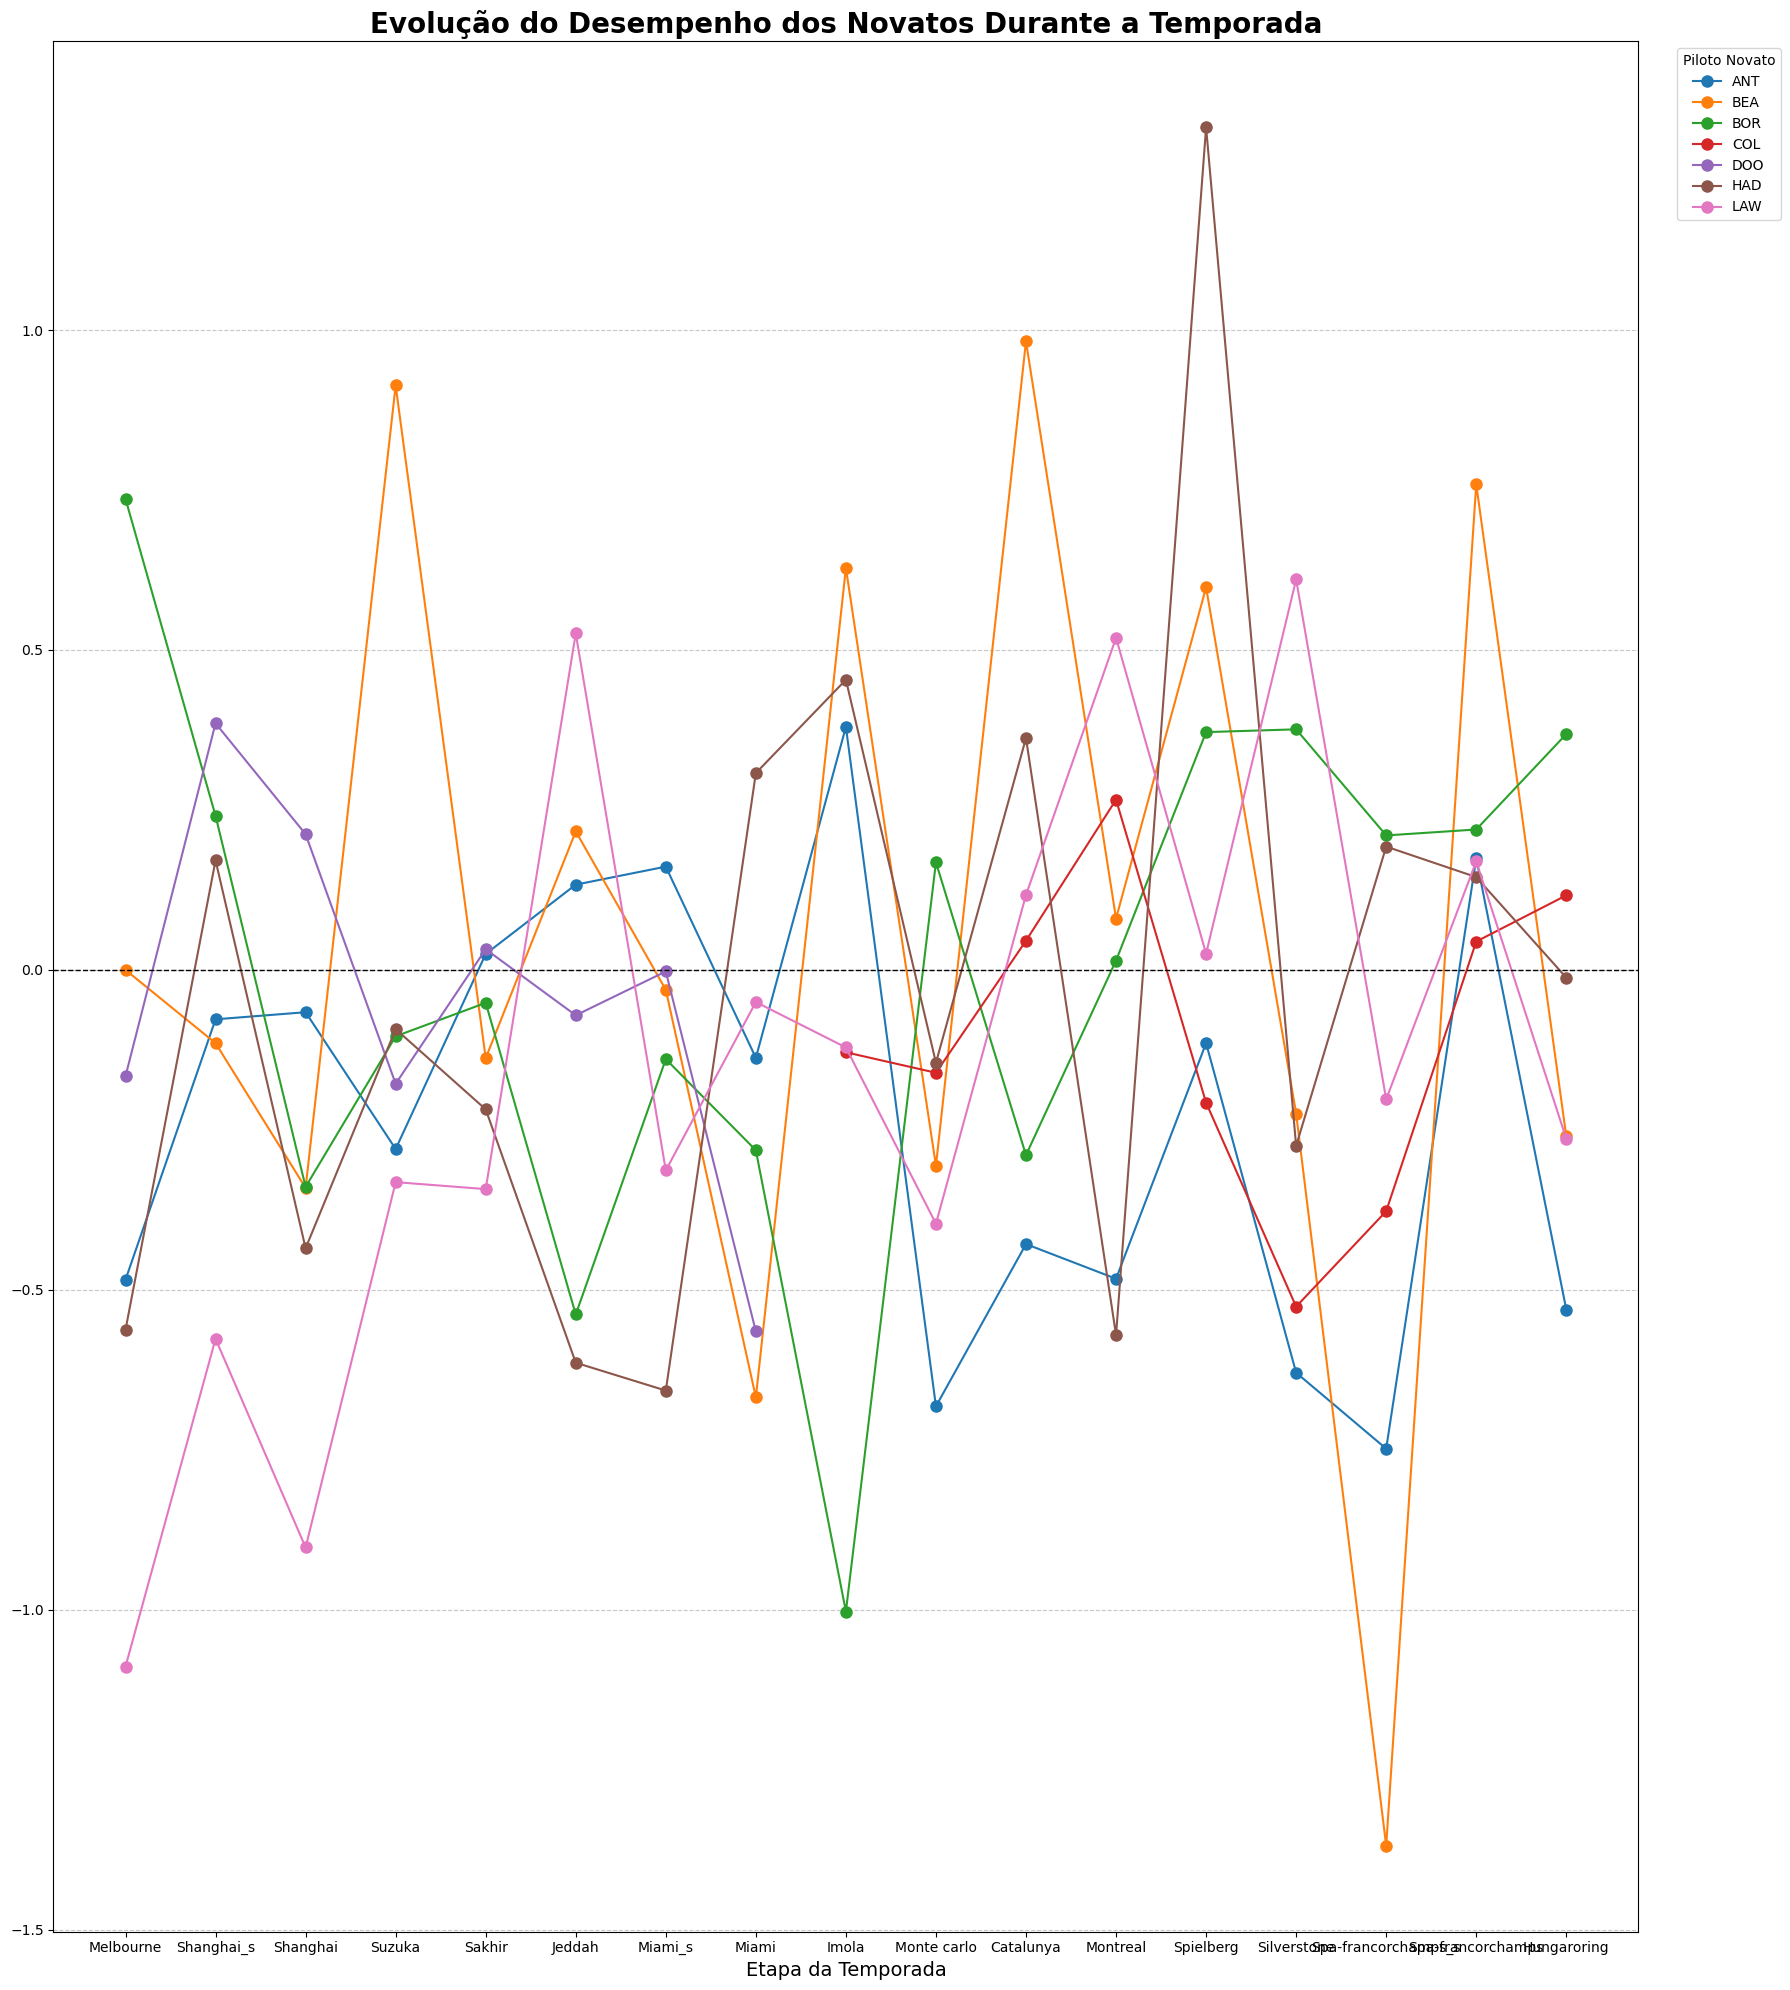

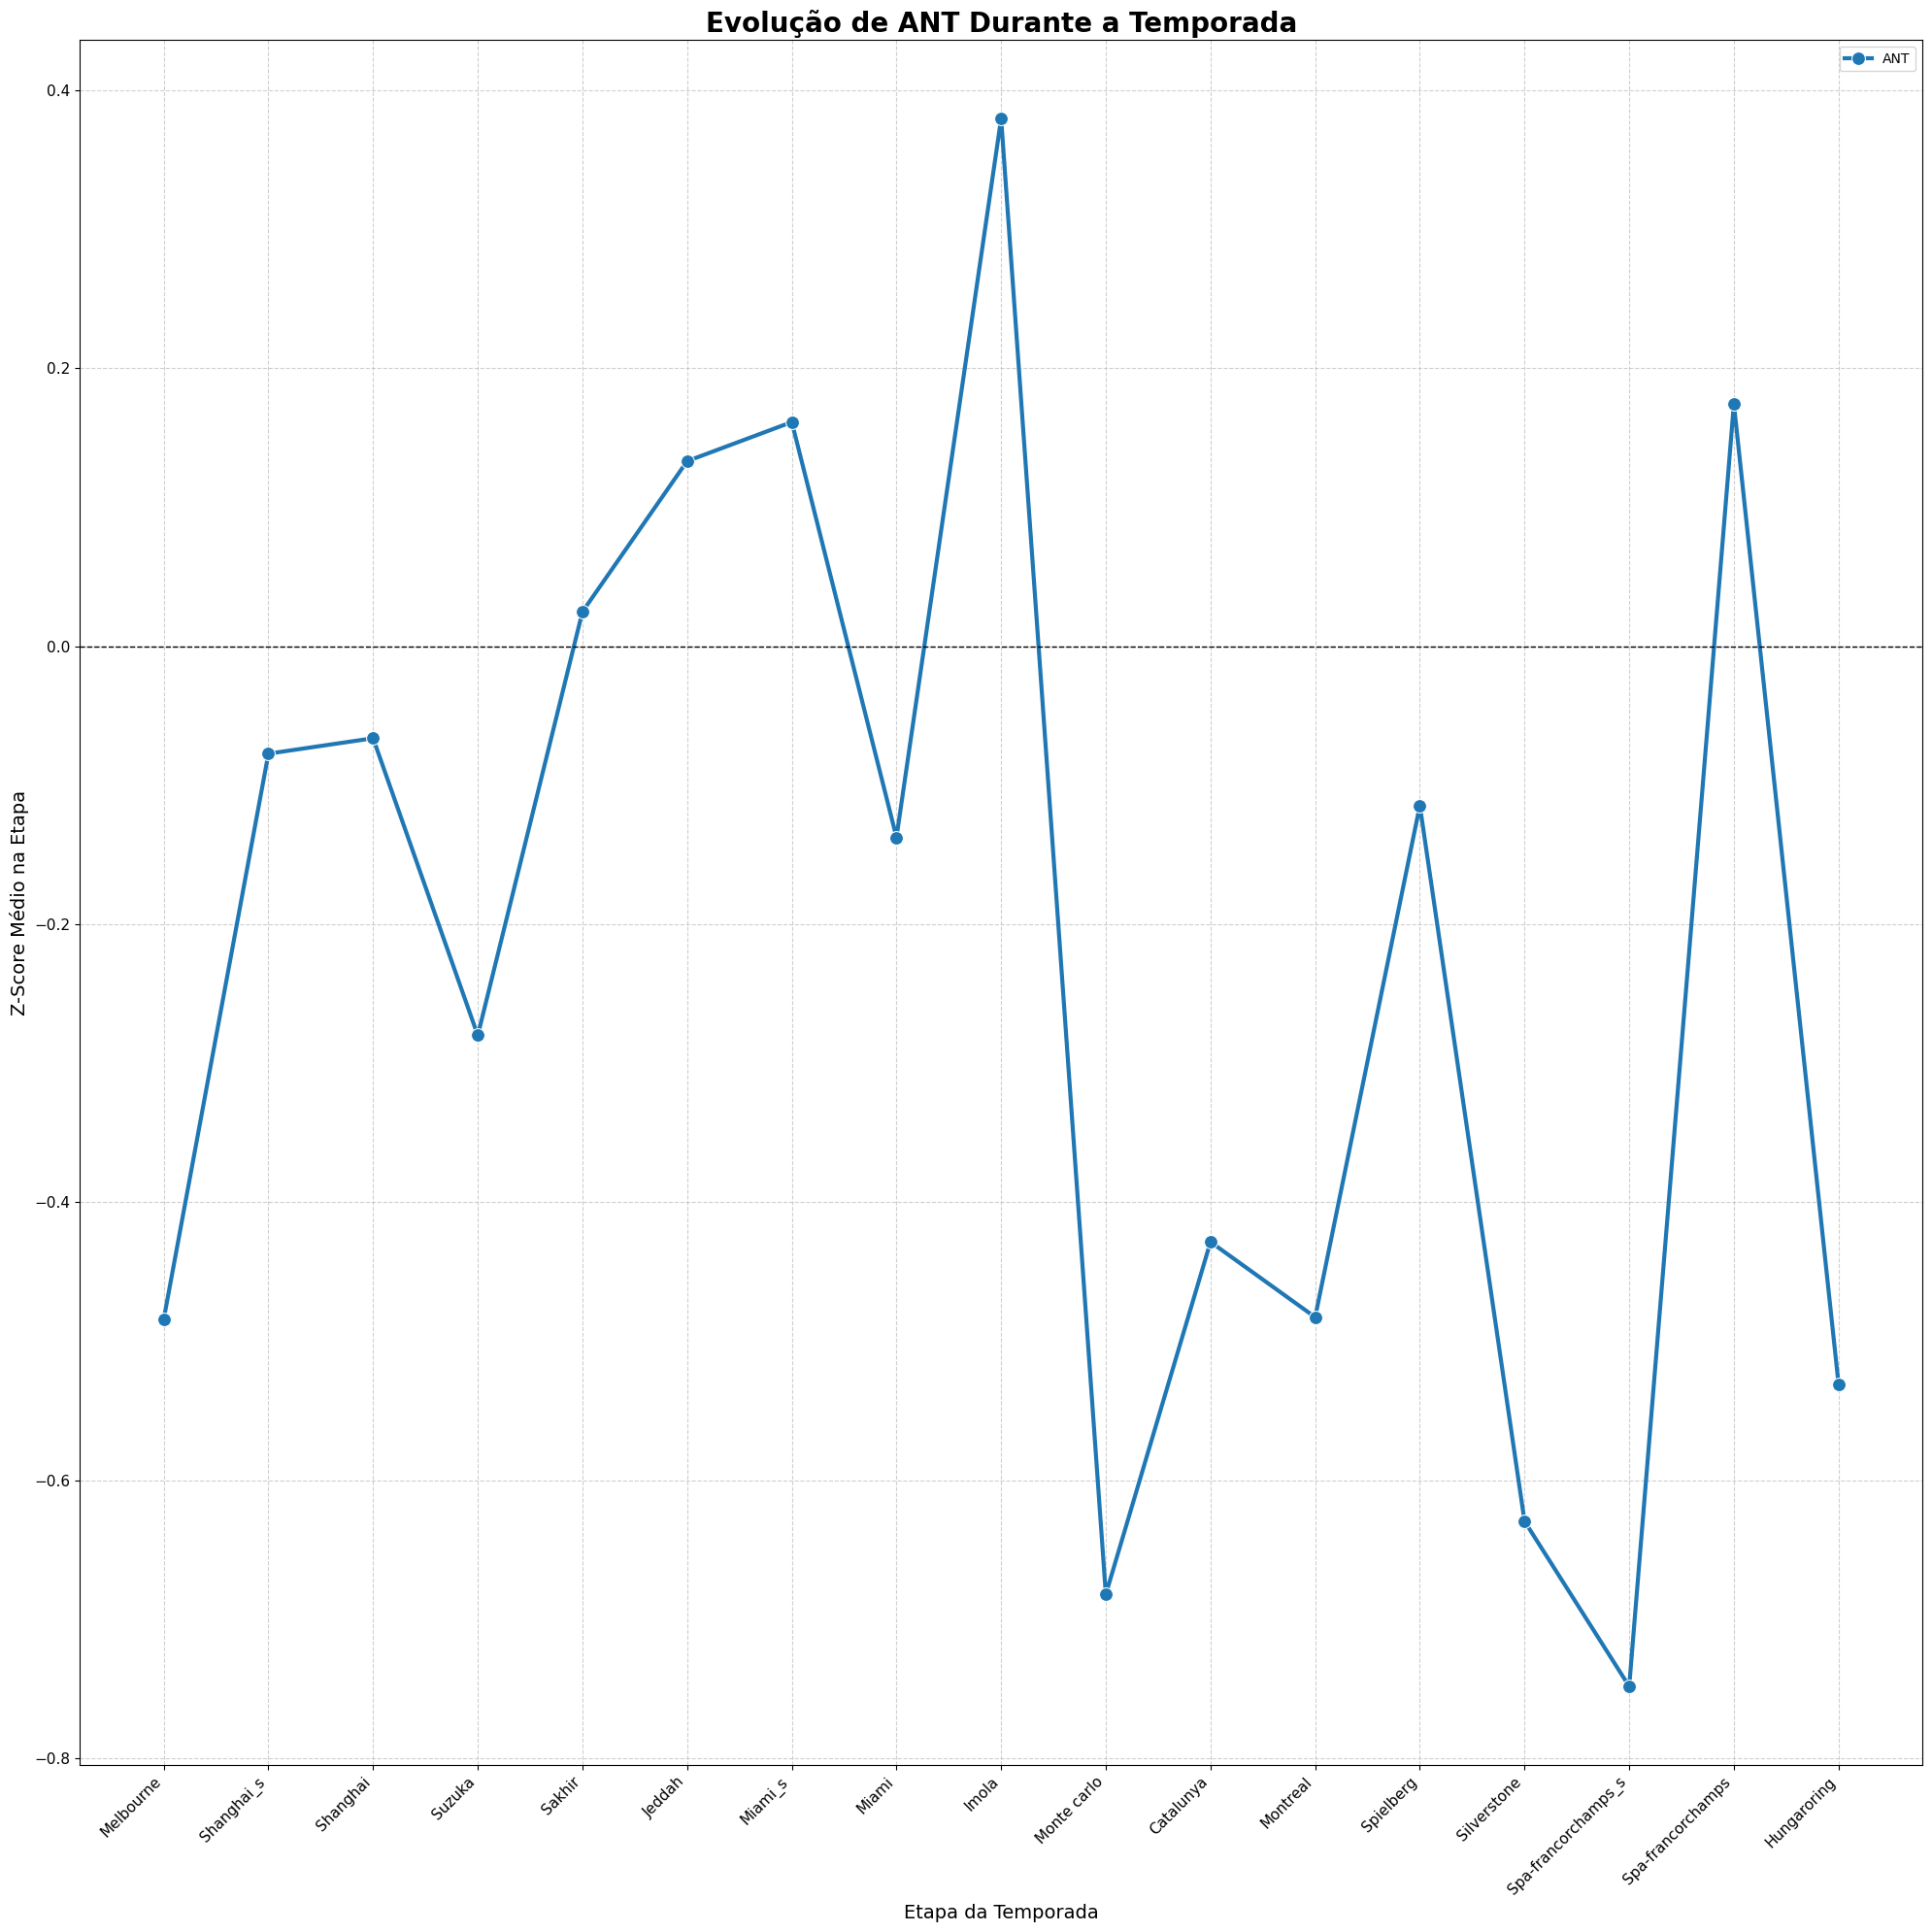

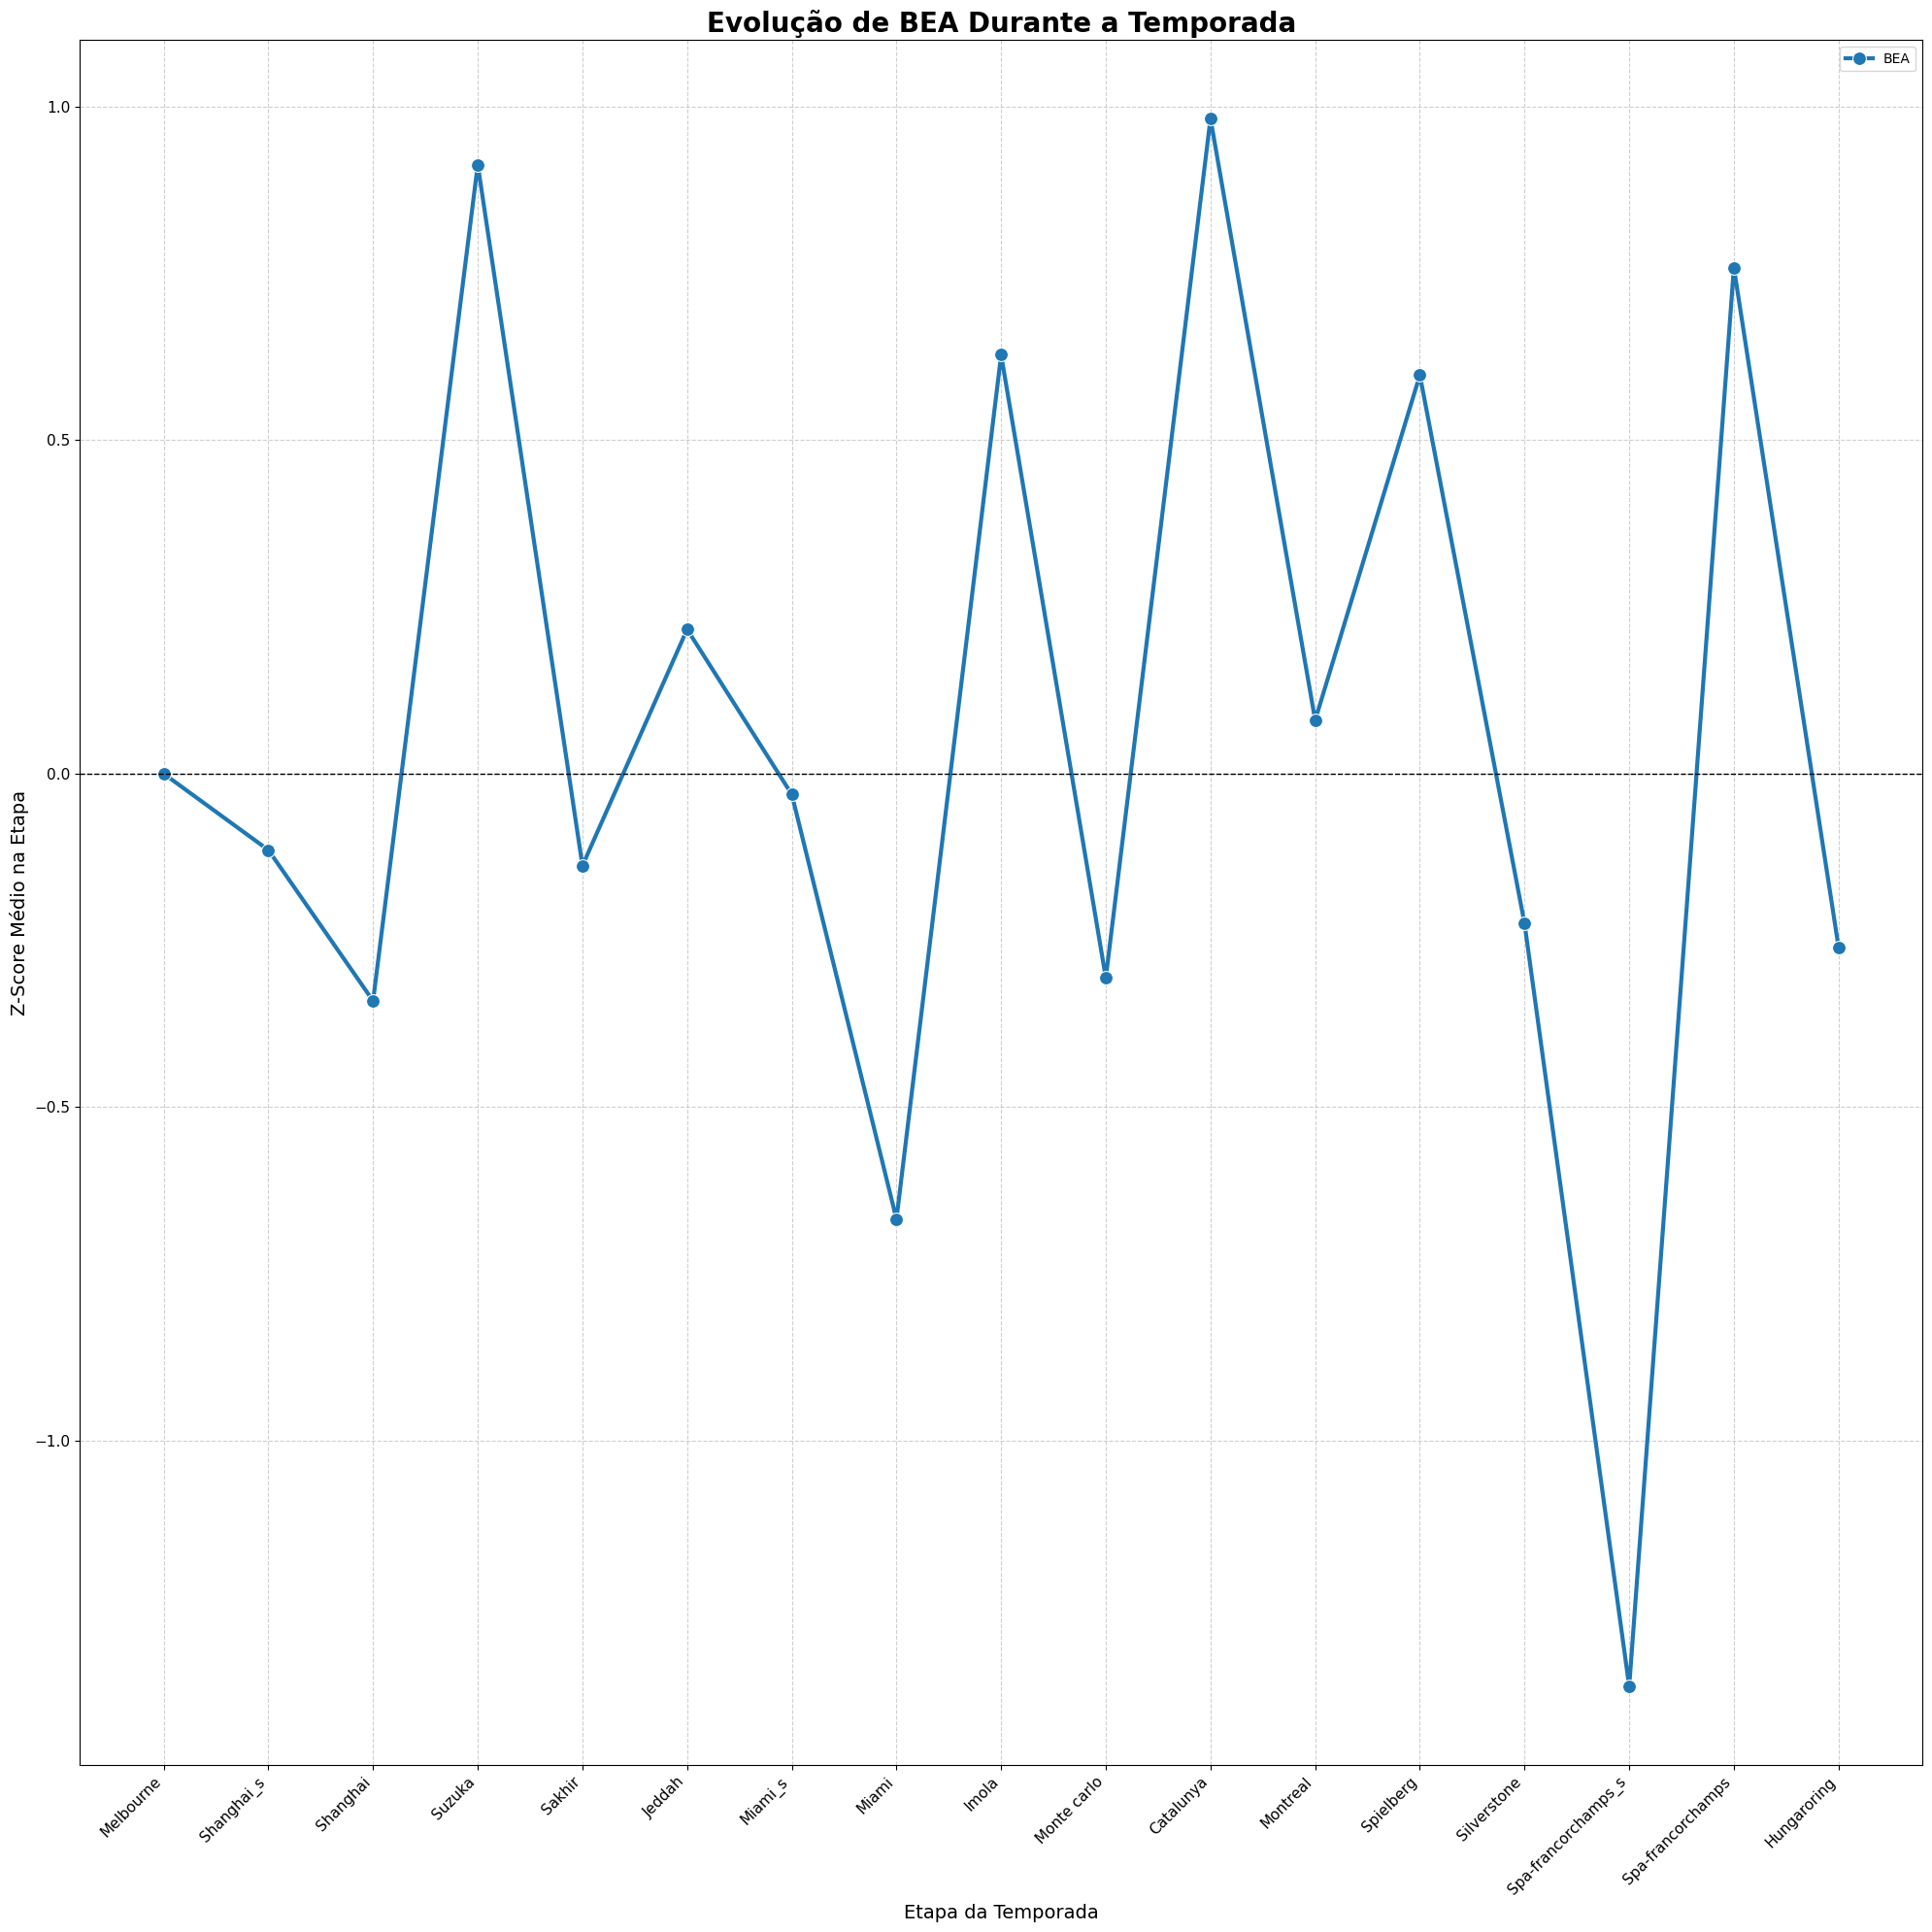

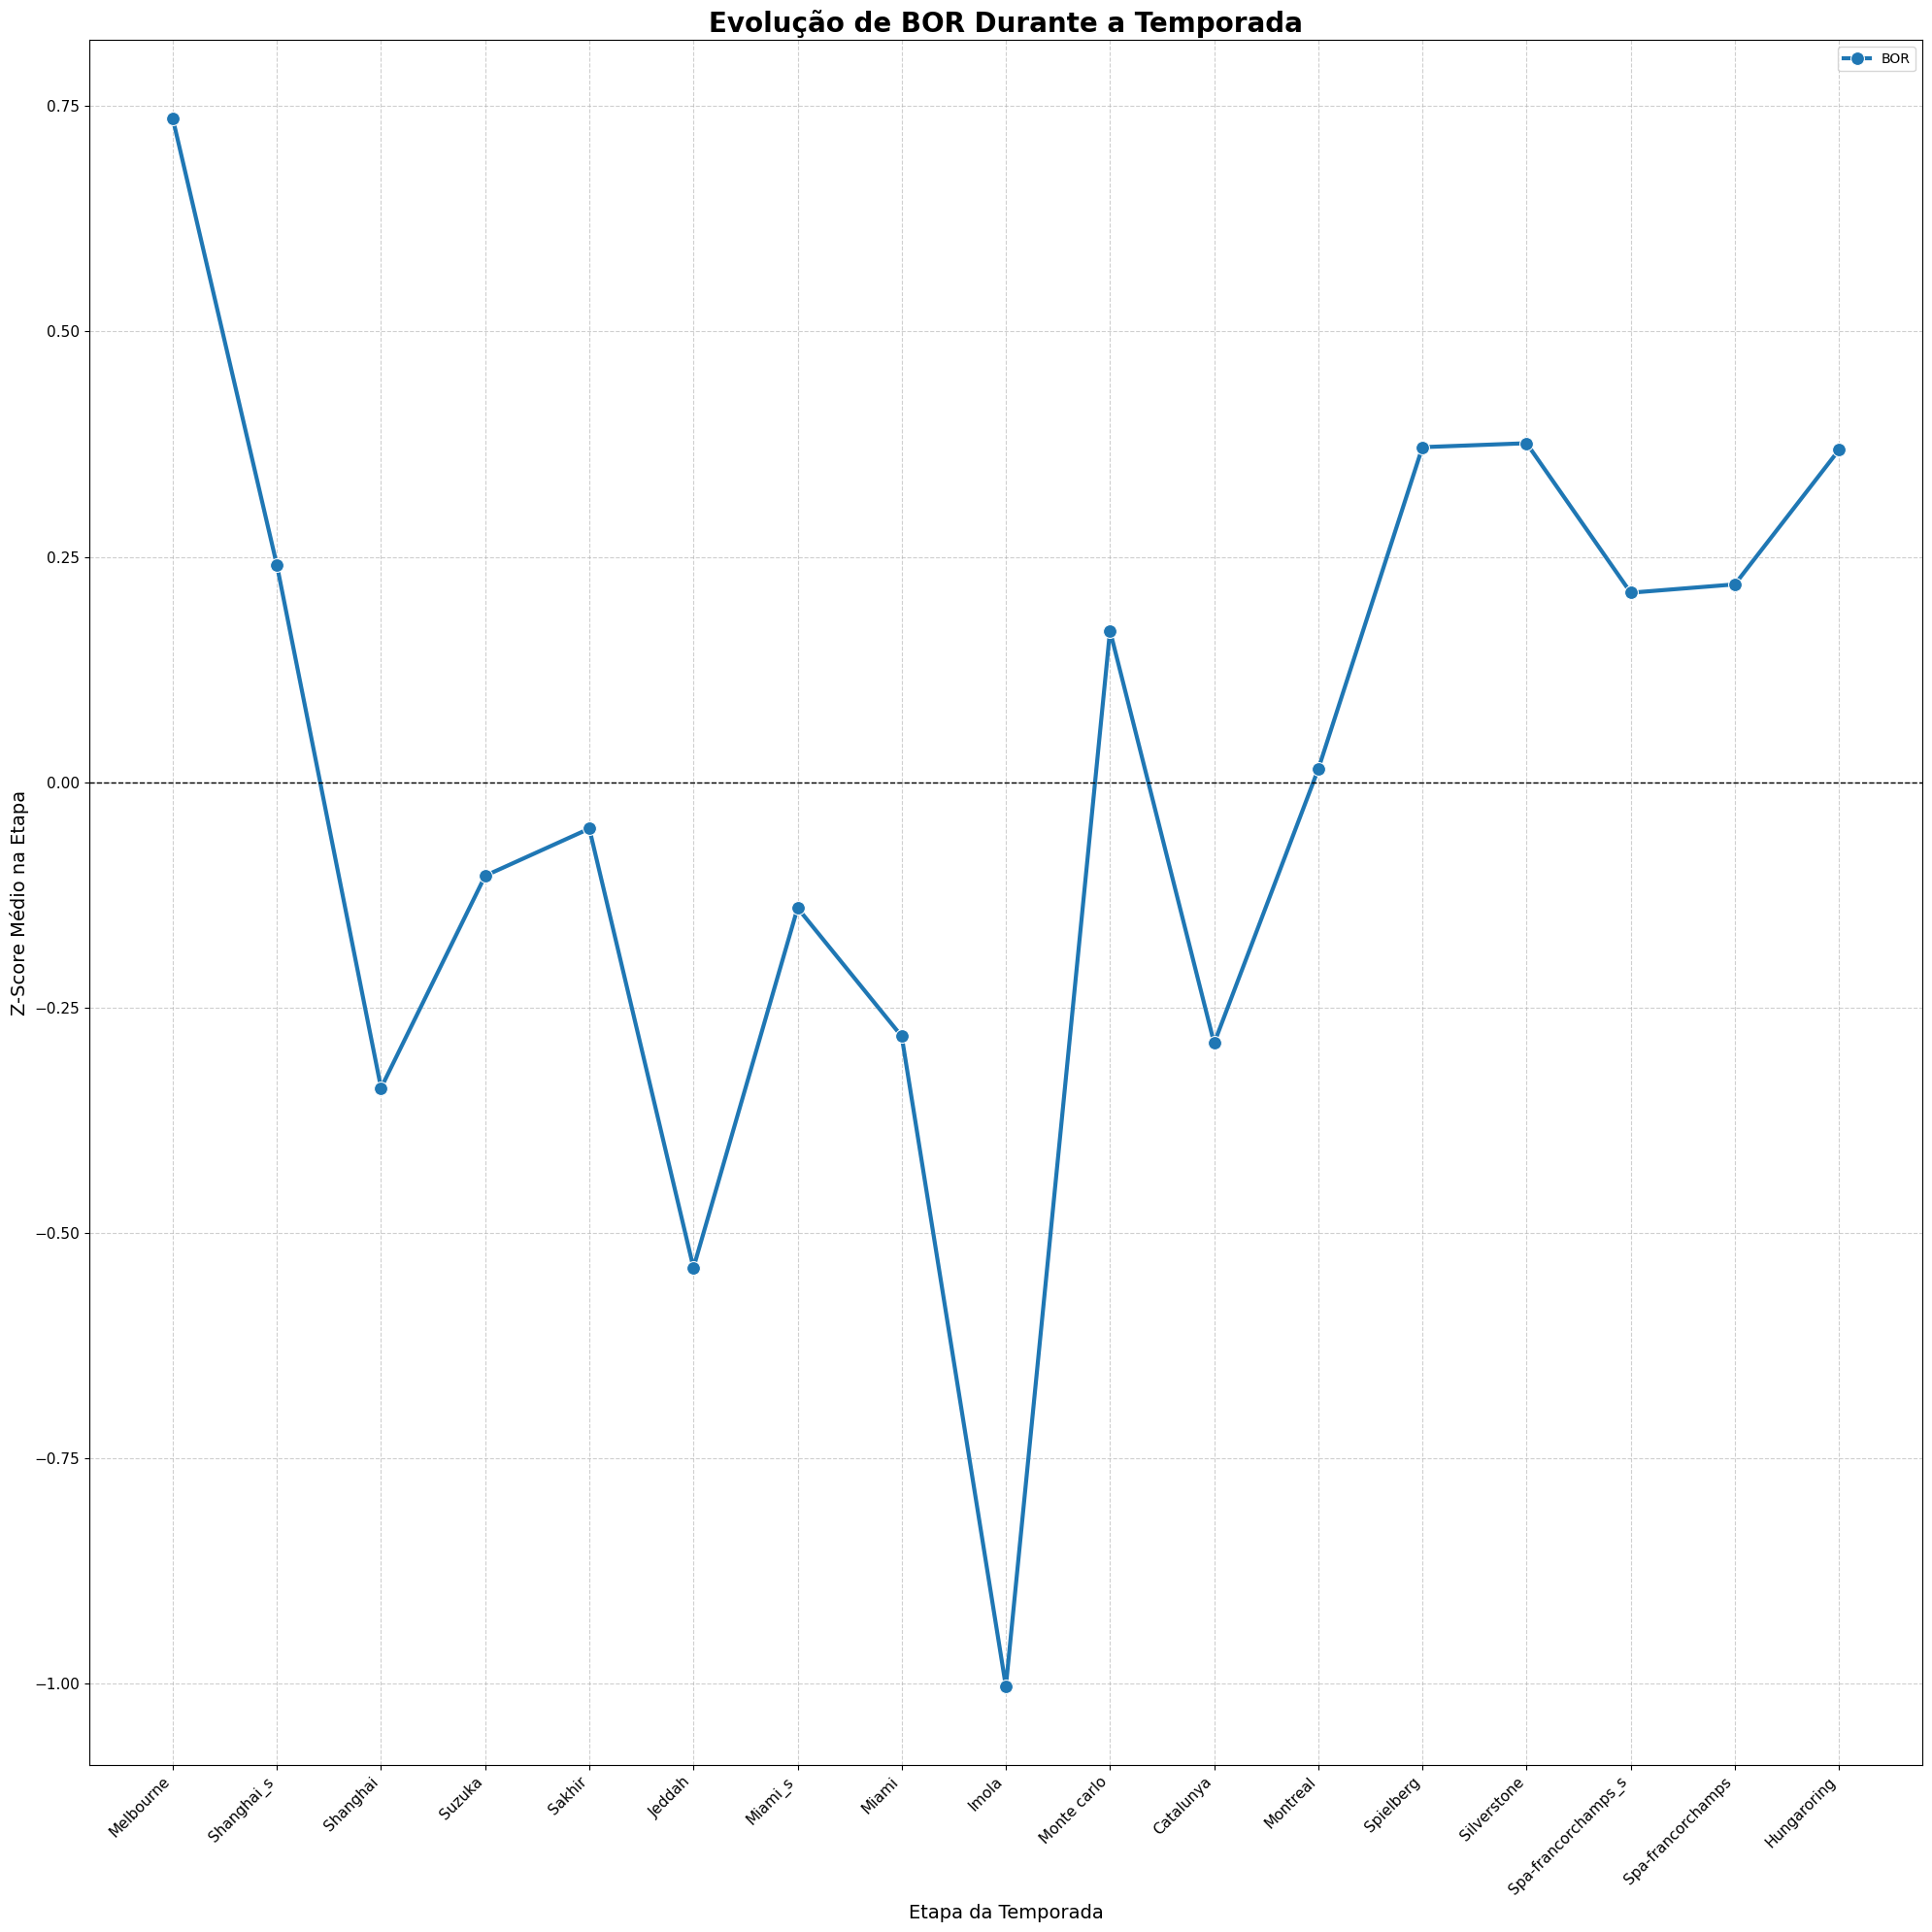

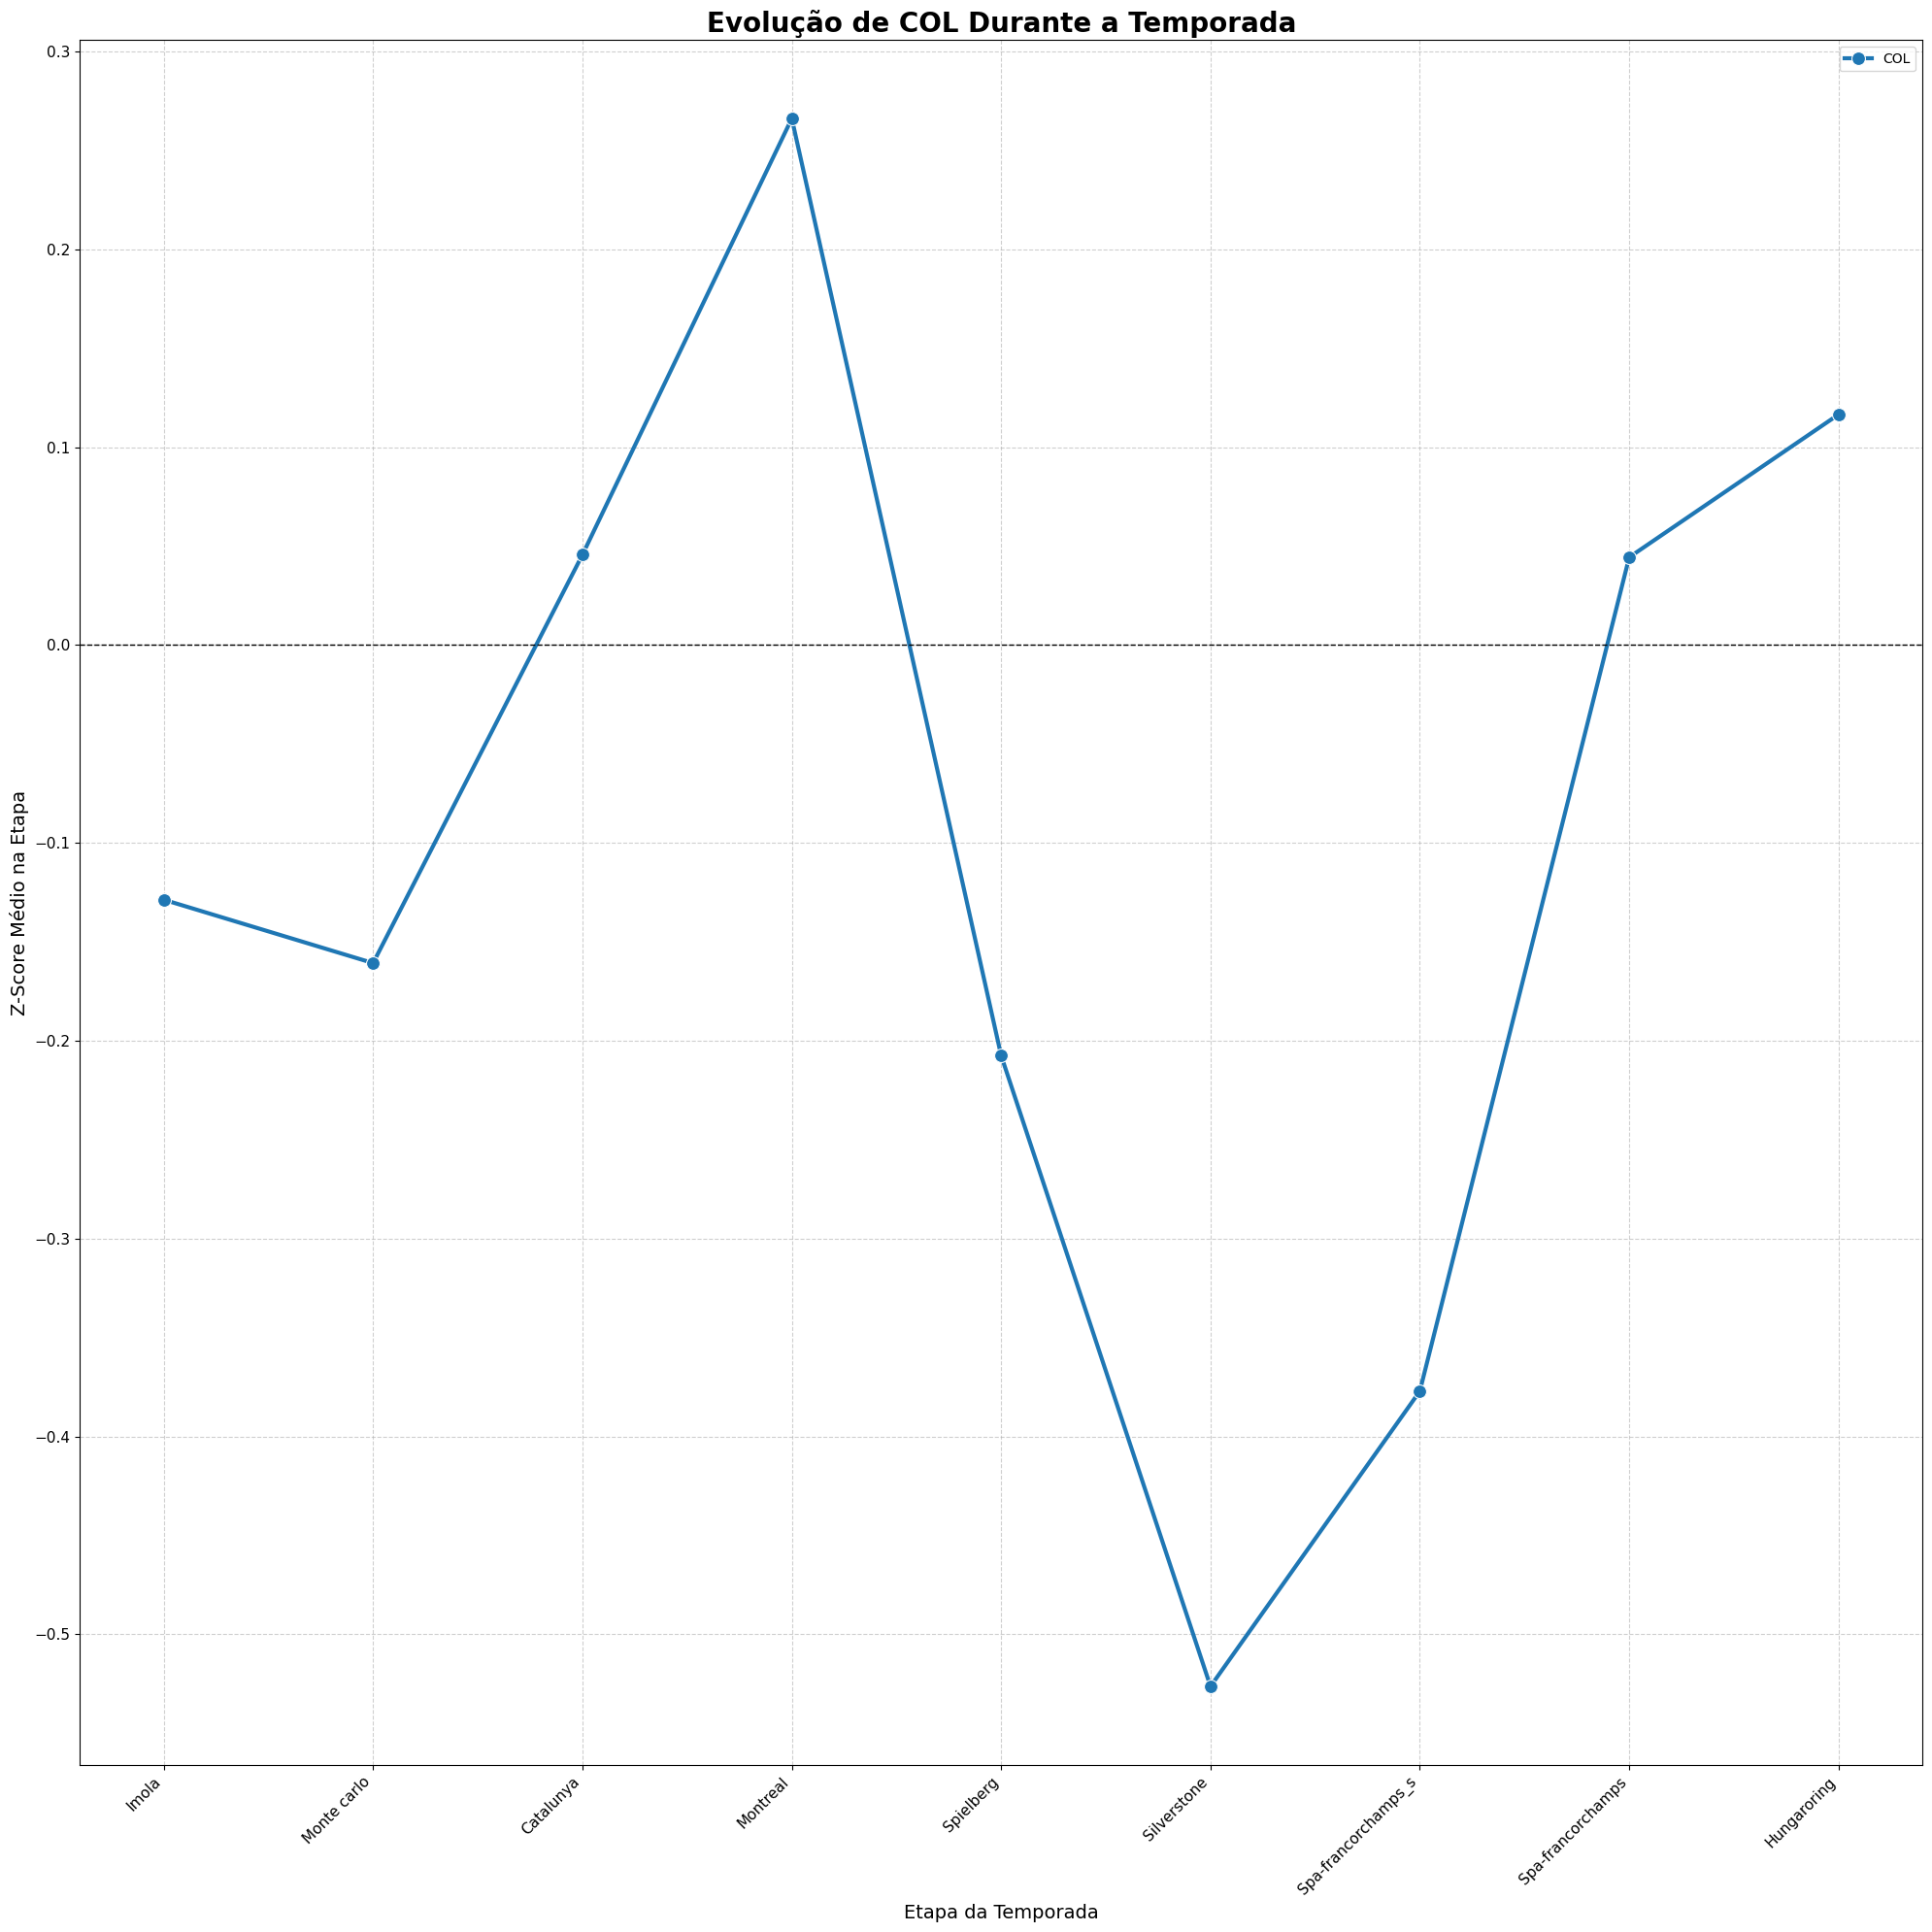

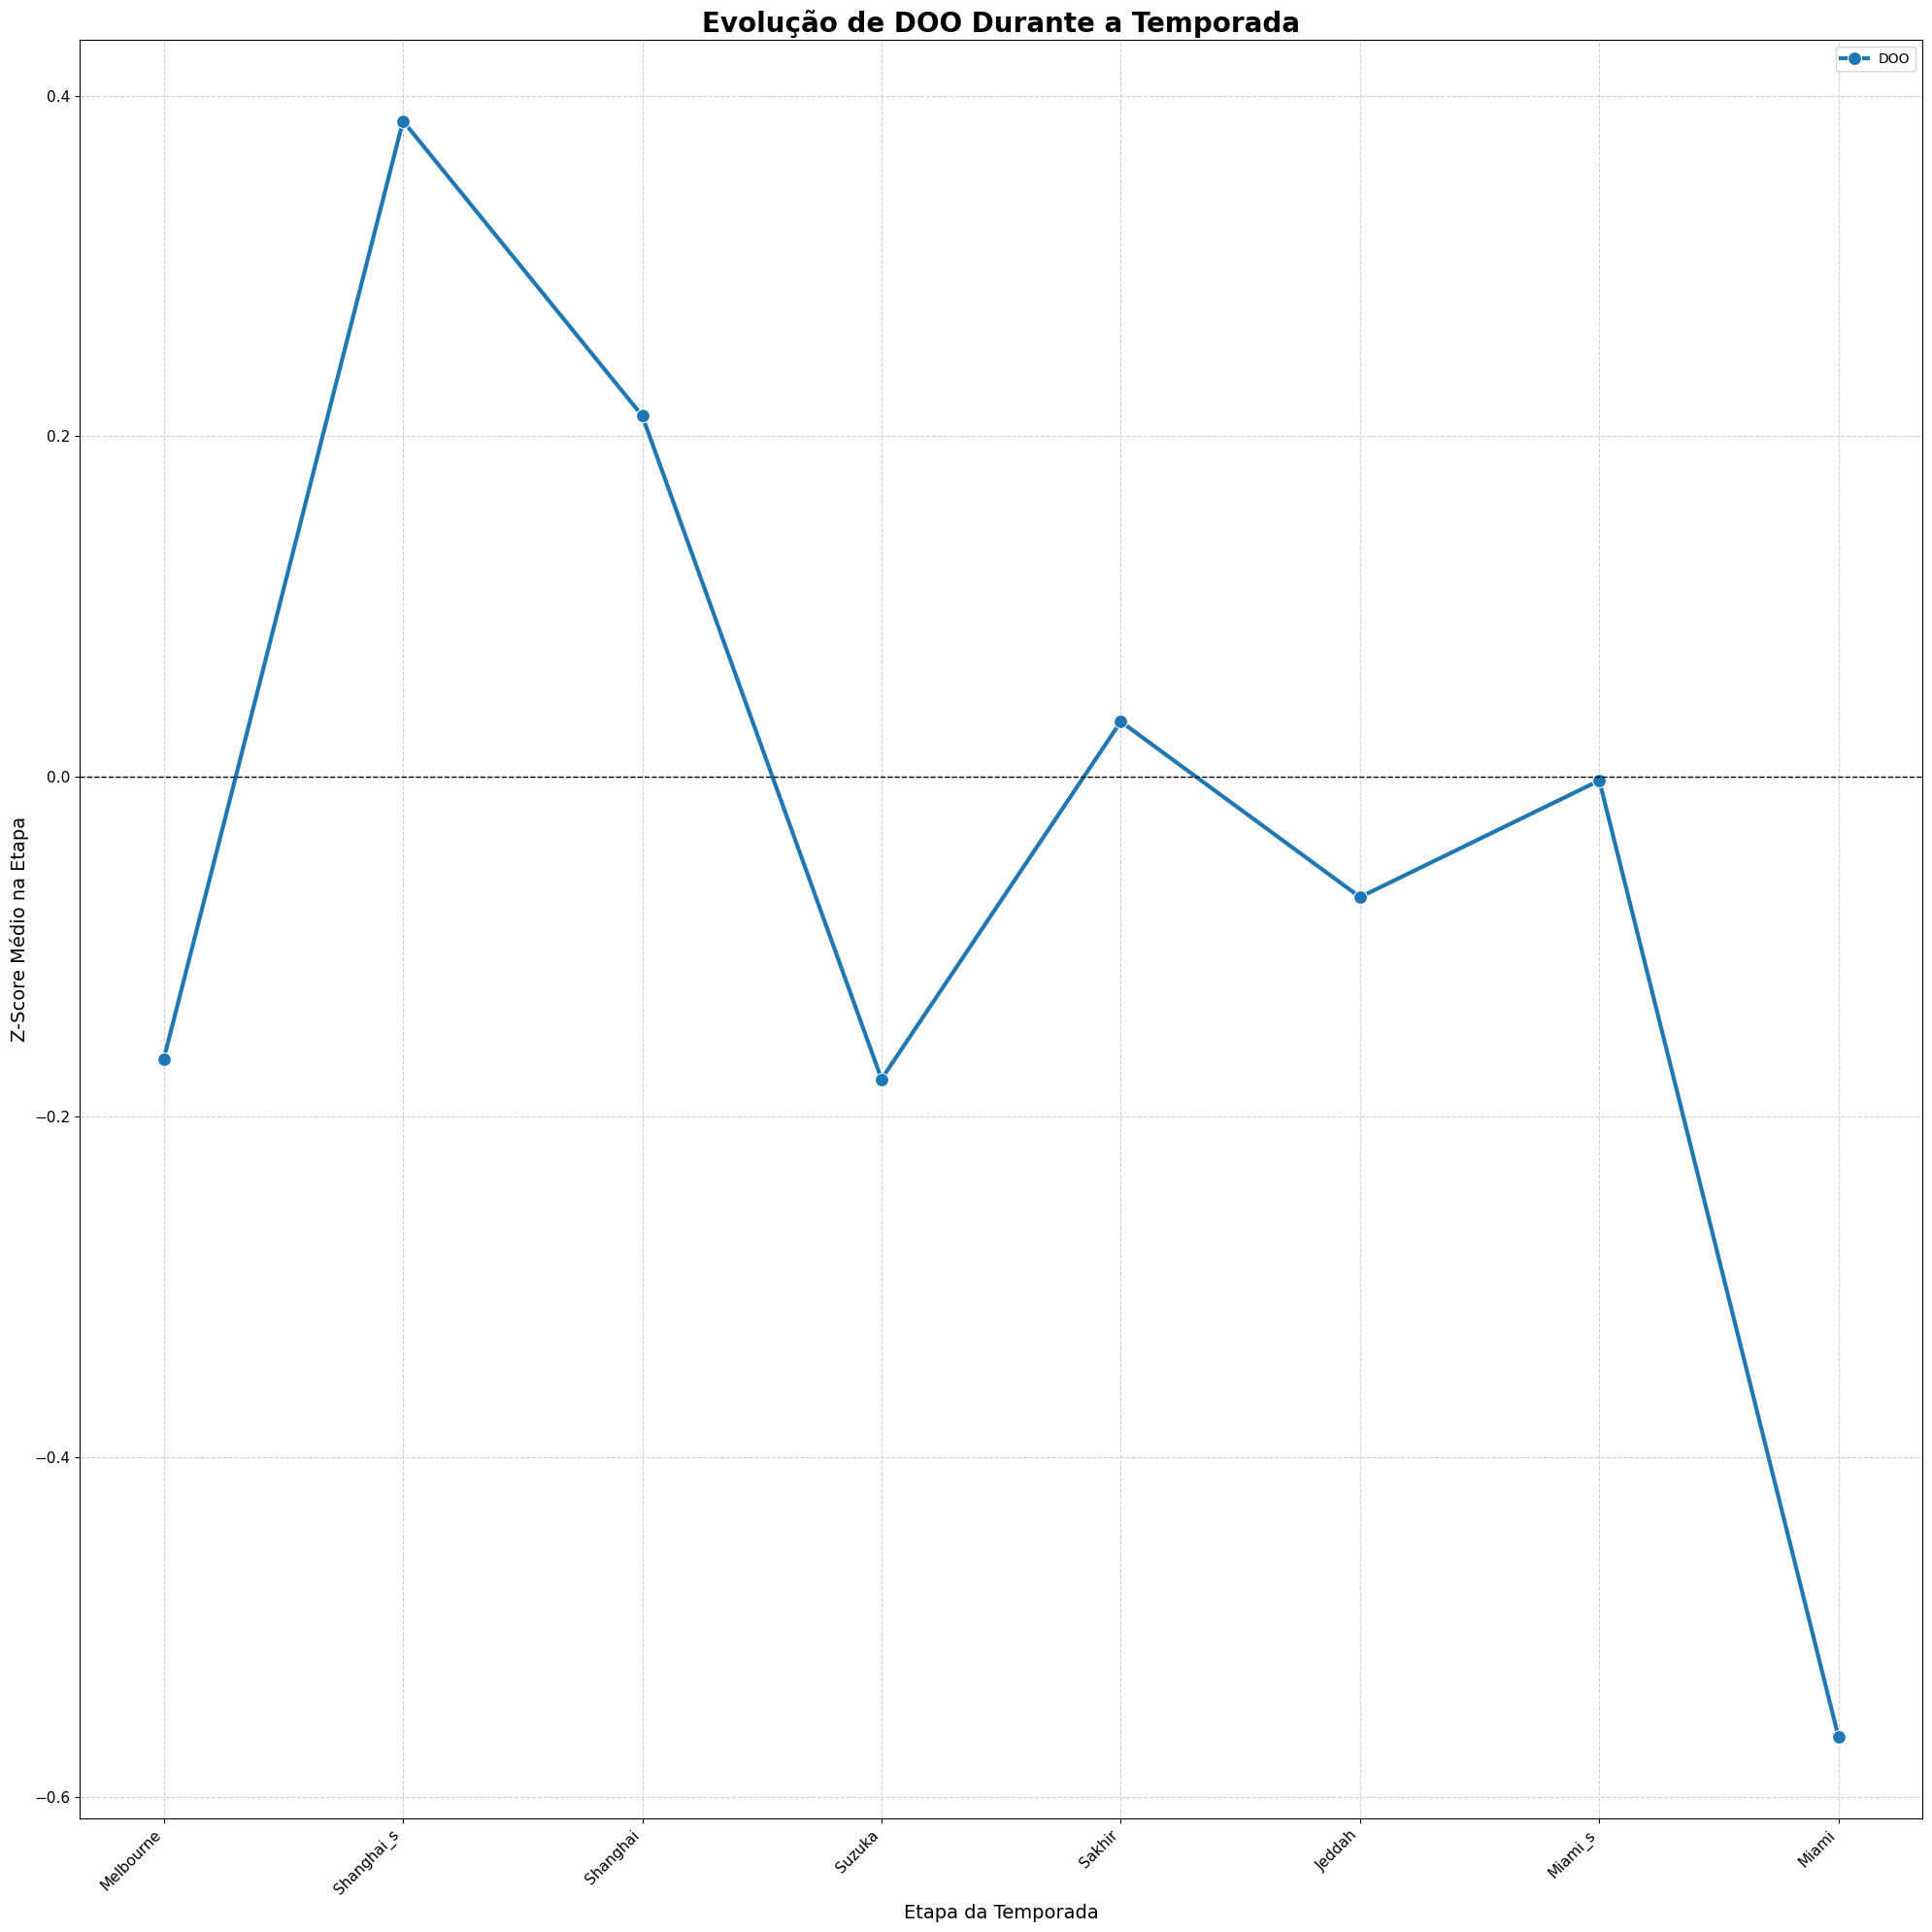

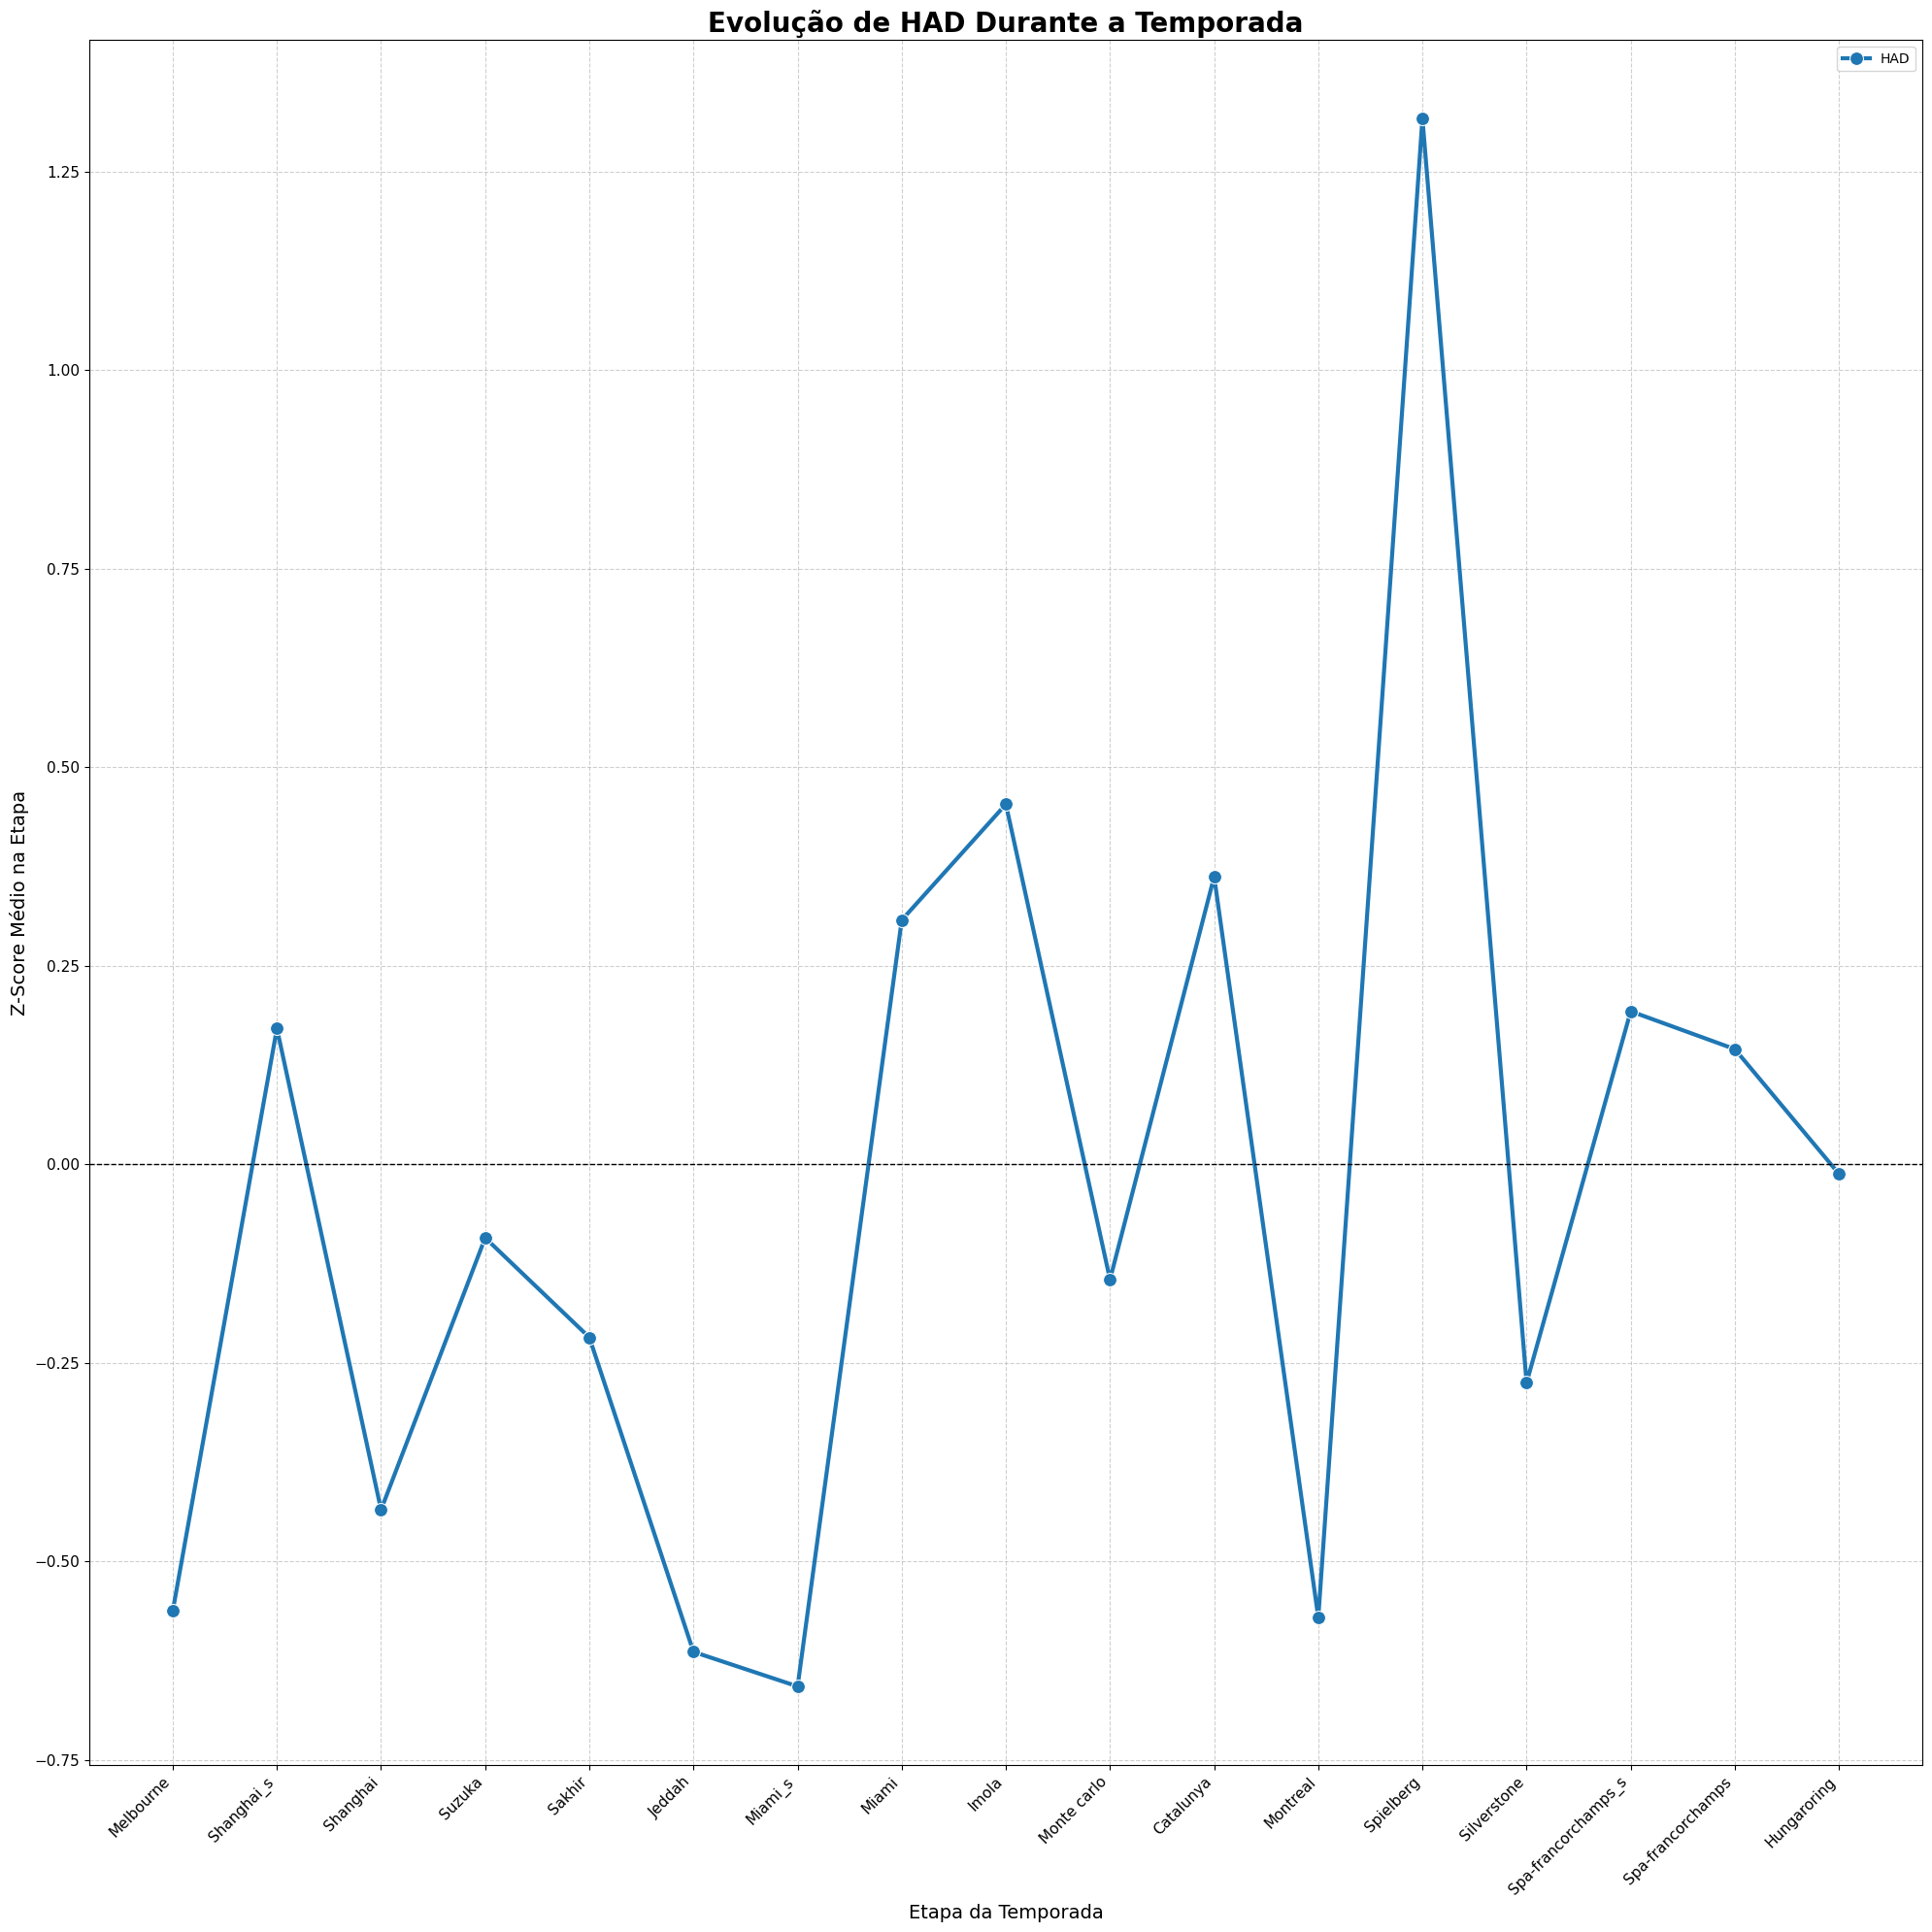

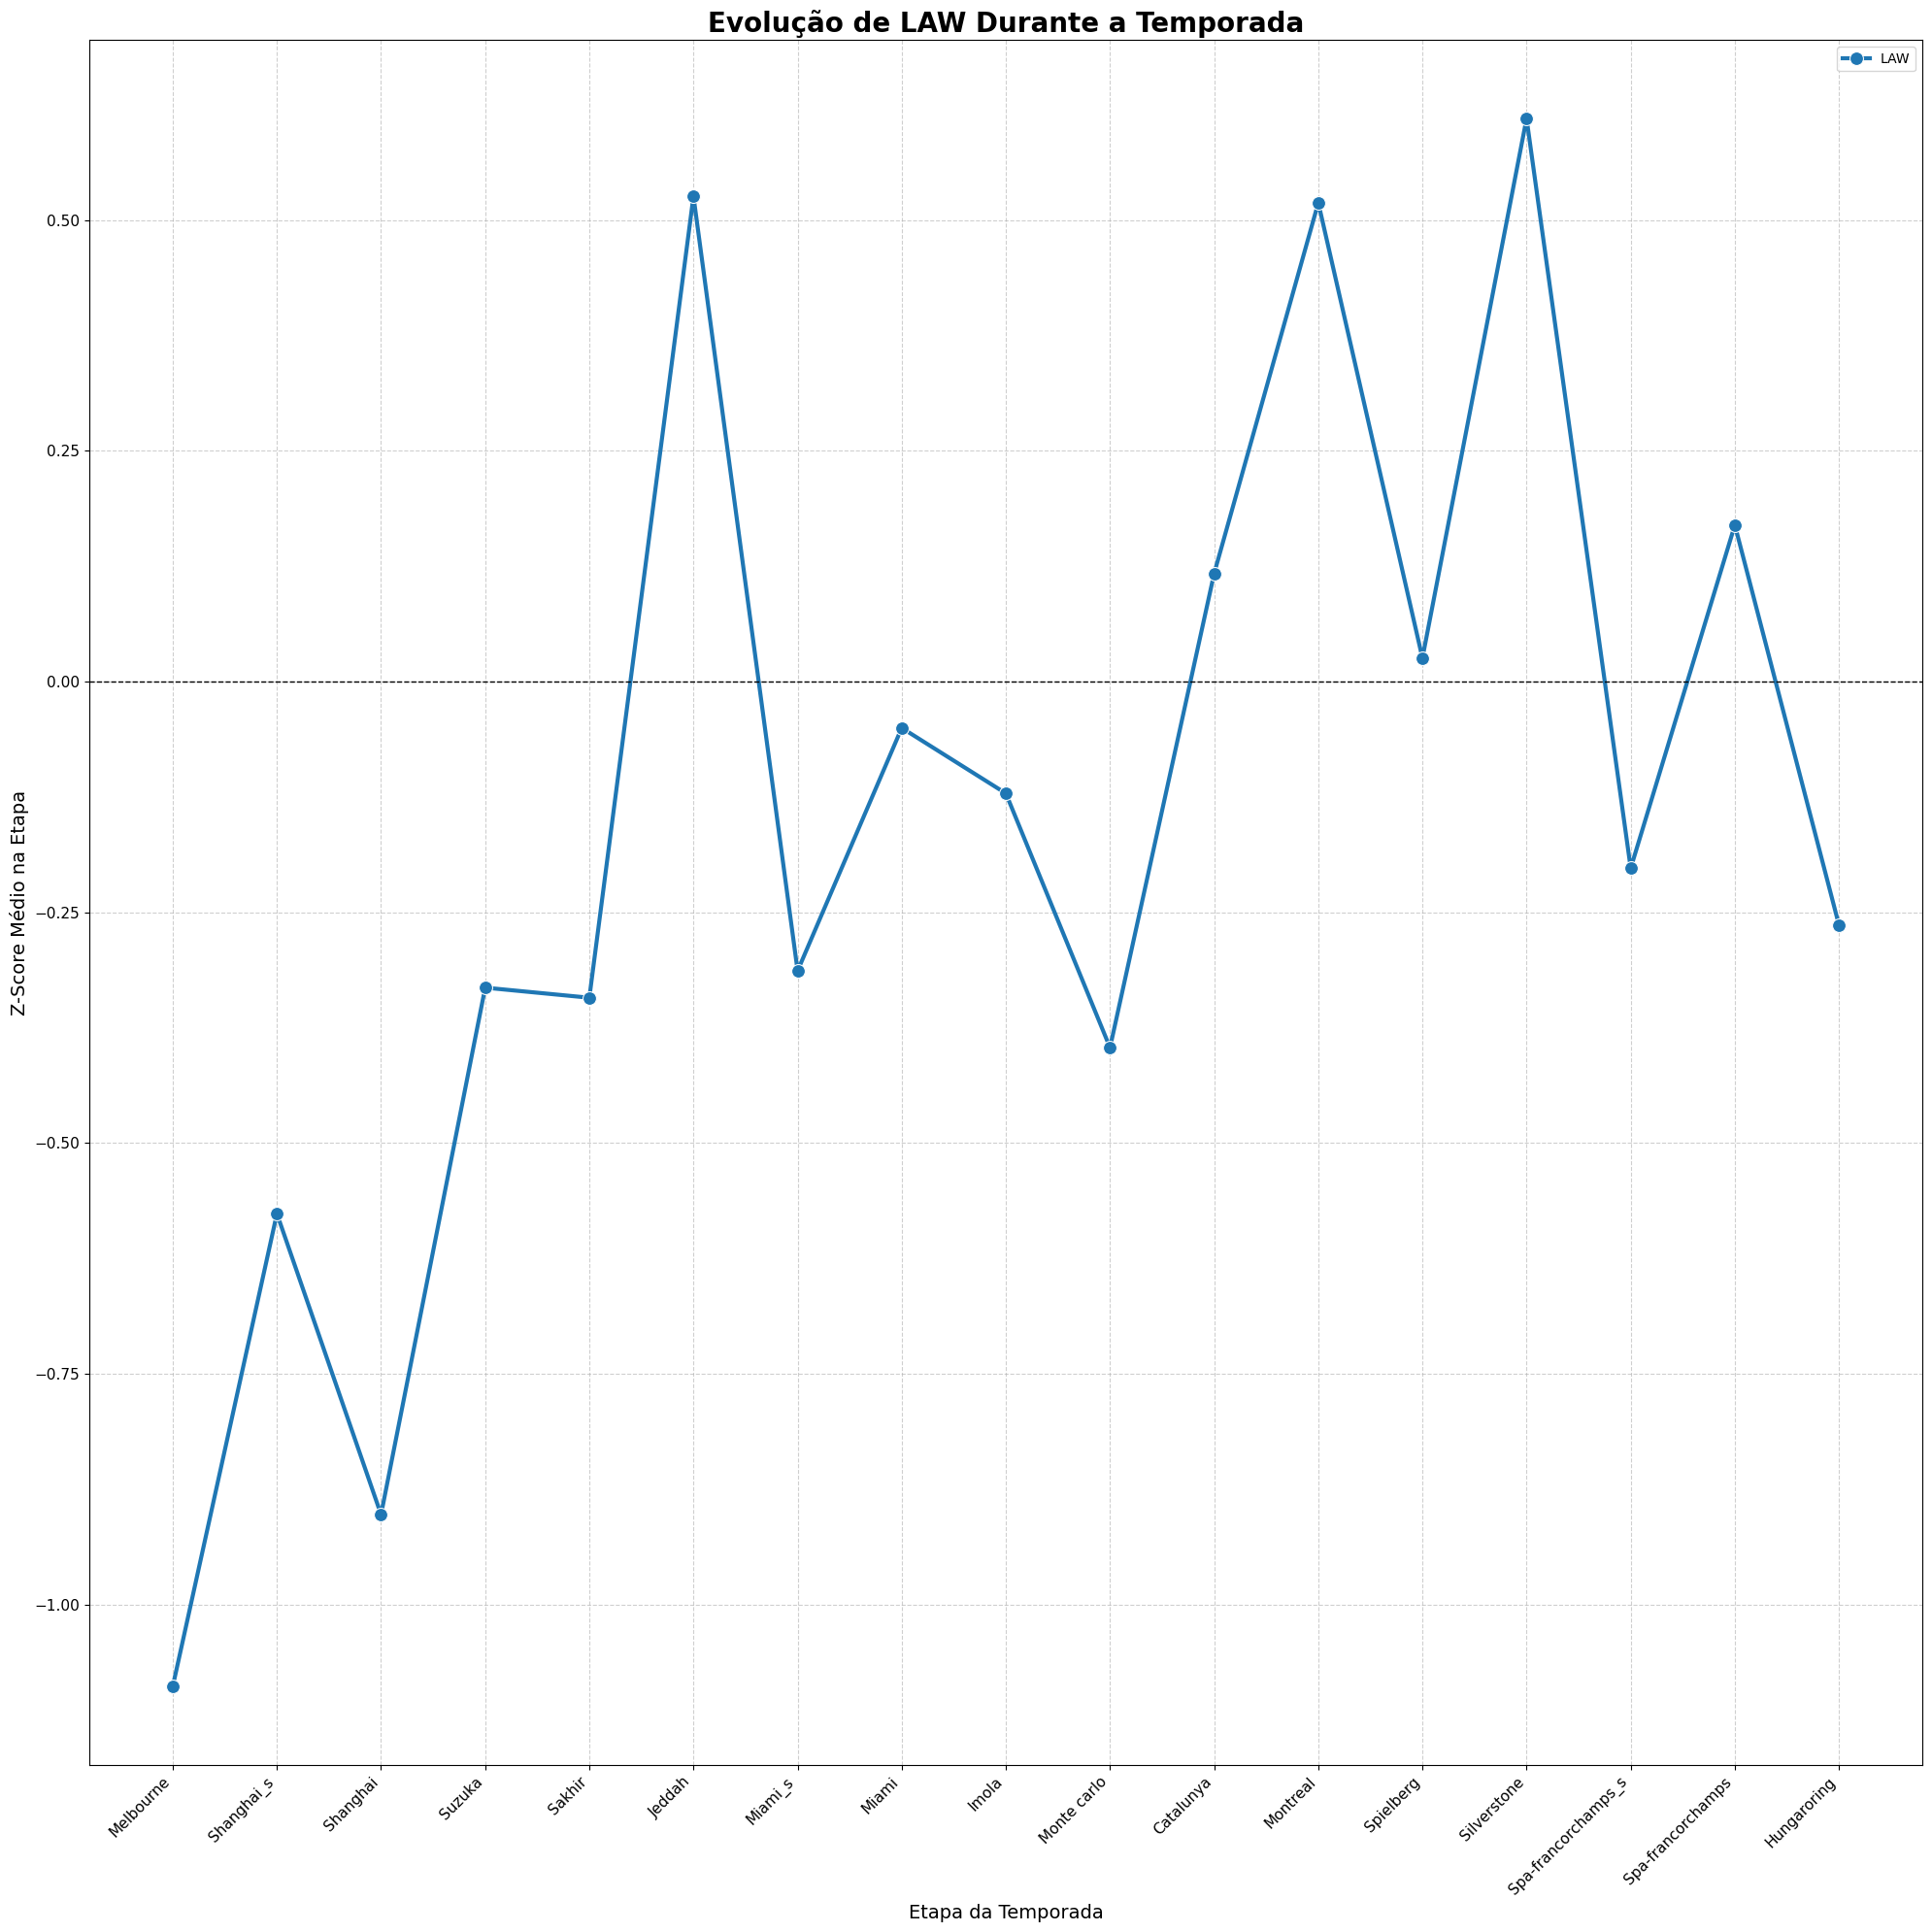

In [17]:
etapas = evolucao_resultados.columns
fig, ax = plt.subplots(figsize=(20, 20))
for piloto in evolucao_resultados.index:
    scores_piloto = evolucao_resultados.loc[piloto]
    ax.plot(etapas, scores_piloto, marker='o', markersize=8, label=piloto)
ax.set_title('Evolução do Desempenho dos Novatos Durante a Temporada', fontsize=20, weight='bold')
ax.set_xlabel('Etapa da Temporada', fontsize=14)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Piloto Novato', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.9, 1])

for piloto in evolucao_resultados.index:    
    plt.figure(figsize=(20, 20))
    scores_piloto = evolucao_resultados.loc[piloto]
    sns.lineplot(x=etapas, y=scores_piloto, marker='o', markersize=10, linewidth=3, label=piloto)
    plt.title(f'Evolução de {piloto} Durante a Temporada', fontsize=20, weight='bold')
    plt.xlabel('Etapa da Temporada', fontsize=14)
    plt.ylabel('Z-Score Médio na Etapa', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.grid(axis='both', linestyle='--', alpha=0.6)
    plt.tight_layout()

Com os gráficos isolados para cada novato, podemos realizar algumas análises:

Antonelli demonstrou estar se adaptando ao carro e melhorando até a etapa de Imola, perdendo seu desempenho bruscamente e apresentando inconstância.

Bearman tem altos e baixos intercalados a cada etapa, o que sugere que seu desempenho é inconstante e depende de cada etapa. Ainda, seus picos positivos e negativos são mais acentuados que o de outros novados, o que reforça sua incostância.

Bortoleto iniciou a temporada com pontuação alta, mas que foi caindo etapa a etapa. A partir de Imola, seu desempenho mudou bruscamente, e passou a demonstrar melhora a cada etapa de forma consistente.

Colapinto iniciou sua participação a partir de Imola. Seu gráfico é bem mais suave do que o de outros novatos, o que sugere que ele é um piloto que passa por fases boas e ruins de forma prolongada.

Doohan participou até Miami. teve um desempenho relativamente bom no começo da temporada, mas não demonstrou evolução ao longo das etapas.

Hadjar manteve-se de forma inconsistente e abaixo da média, mas teve um grande acerto isolado em Spielberg, sugerindo uma melhora momentânea ou etapa que favorece o acerto do carro. Mesmo após esse grande acerto, o gráfico parece seguir a tendência anterior.

Lawson teve um desempenho bem abaixo nas 3 primeiras etapas, enquanto ainda corria pela Red Bull Racing, com um carro que afirmam ser difícil de conduzir. A partir da quarta etapa, correndo pela equipe Racing Bulls Lawson apresentou melhor adaptação ao carro e um desempenho relativamente consistente. 



### É possível prever a qualificação, dadas as curvas selecionadas?

Para verificar a relação das curvas com a posição final na qualificação, utilizamos a função linregress do SciPy.

Com isso, tentamos criar uma função linear para cada etapa específica, dado que cada circuito tem características únicas, que podem varia mesmo de um dia para o outro, como demonstrado nas diferenças de uma qualificação sprint para a principal.

Como a função linregress utiliza uma variável x para estimar uma variável y, não podemos encaixar as n curvas selecionadas de uma etapa. Dessa forma, utilizamos como variável x a média das velocidades nas curvas de cada etapa.

Para cada etapa, foi gerado um gráfico de dispersão para visualizar a relação entre a reta de regressão e os pontos no gráfico. Ainda, temos a equação da reta e R², variável que mostra a influência da variável que escolhemos (velocidade média nas curvas) sobre o resultado final (posição na qualificação).



/tmp/ipykernel_6003/2510602769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  etapa['velocidade_media'] = etapa[colunas_curvas].mean(axis=1)
/tmp/ipykernel_6003/2510602769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  etapa['velocidade_media'] = etapa[colunas_curvas].mean(axis=1)
/tmp/ipykernel_6003/2510602769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

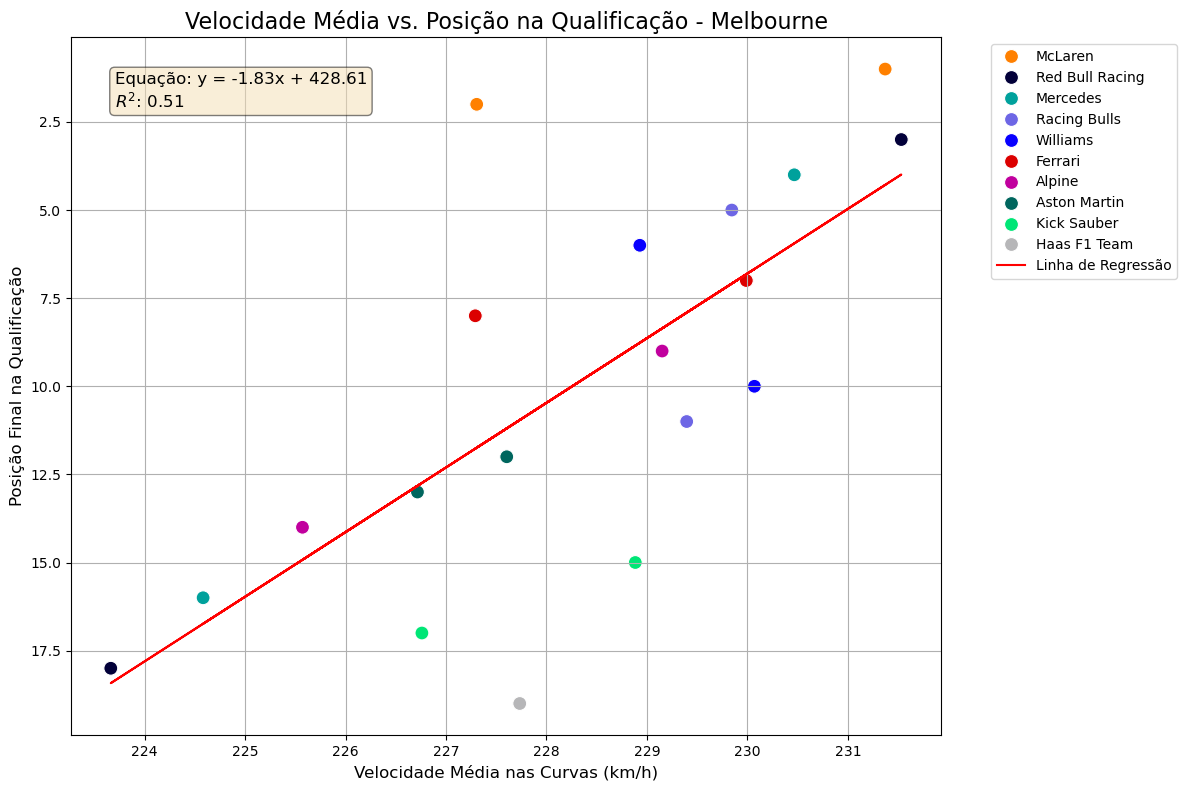

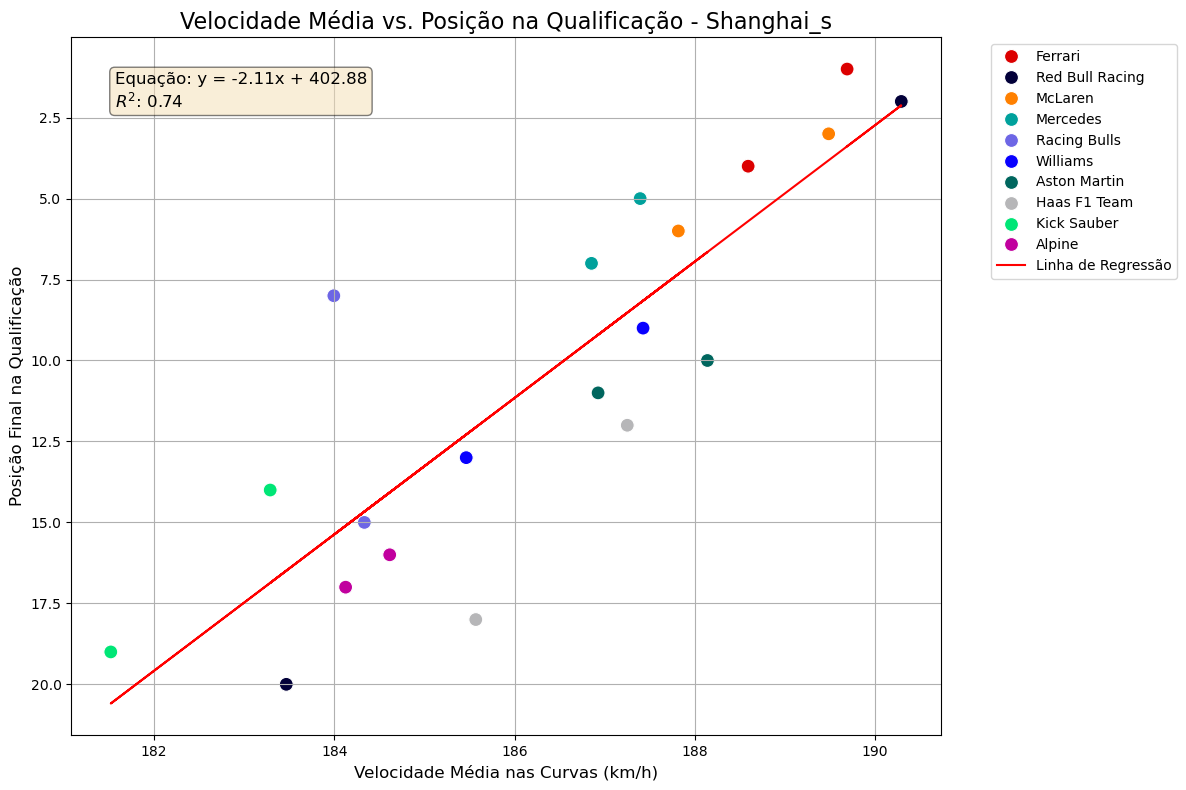

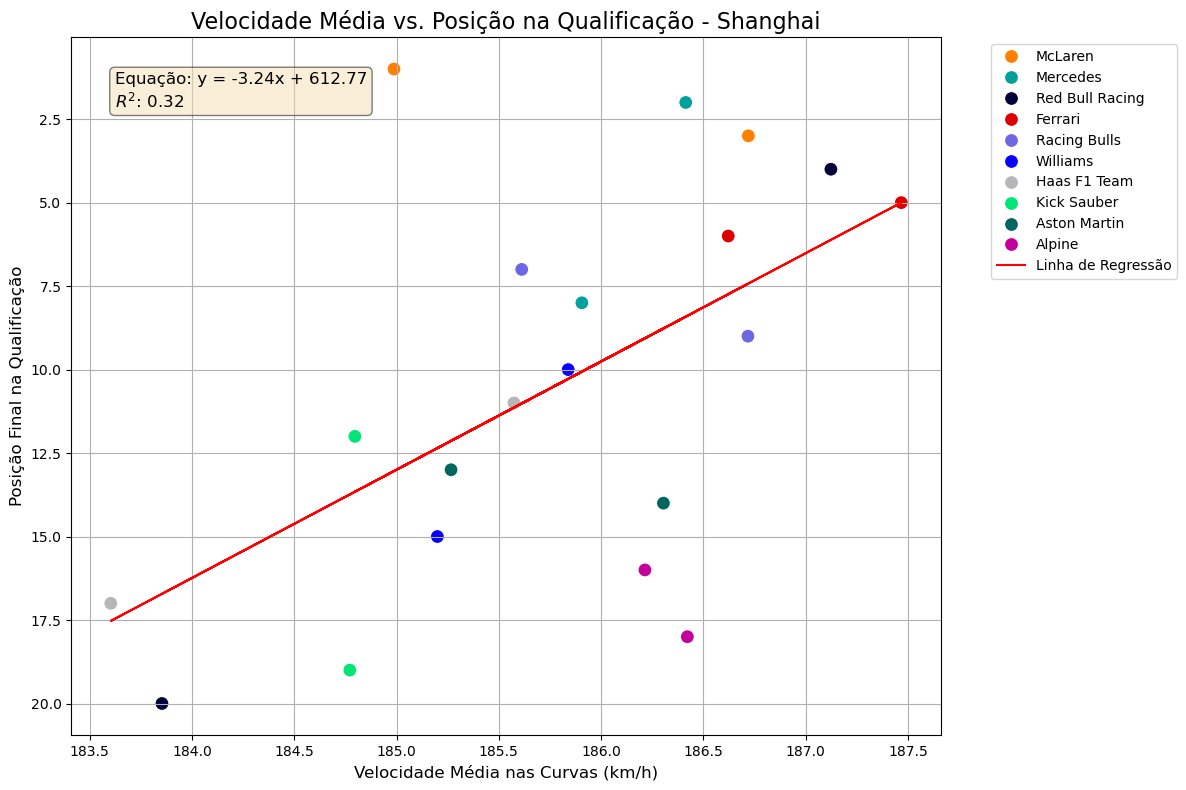

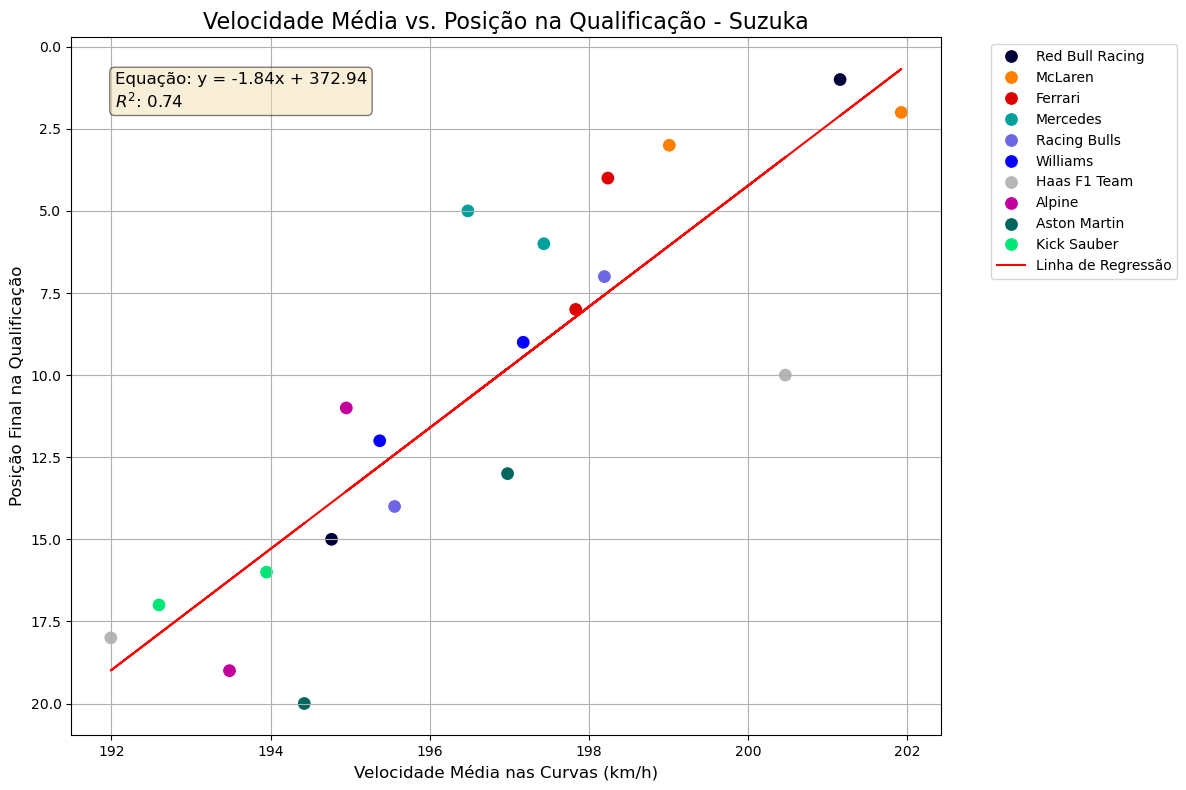

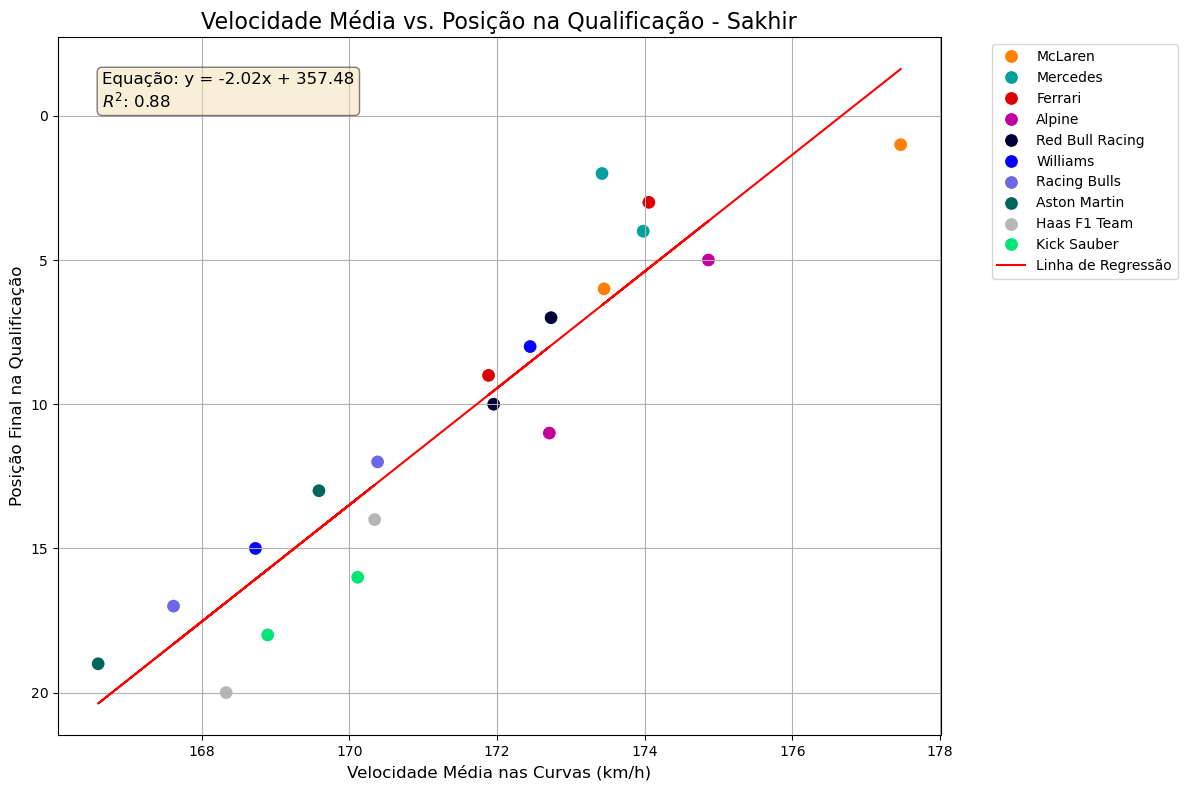

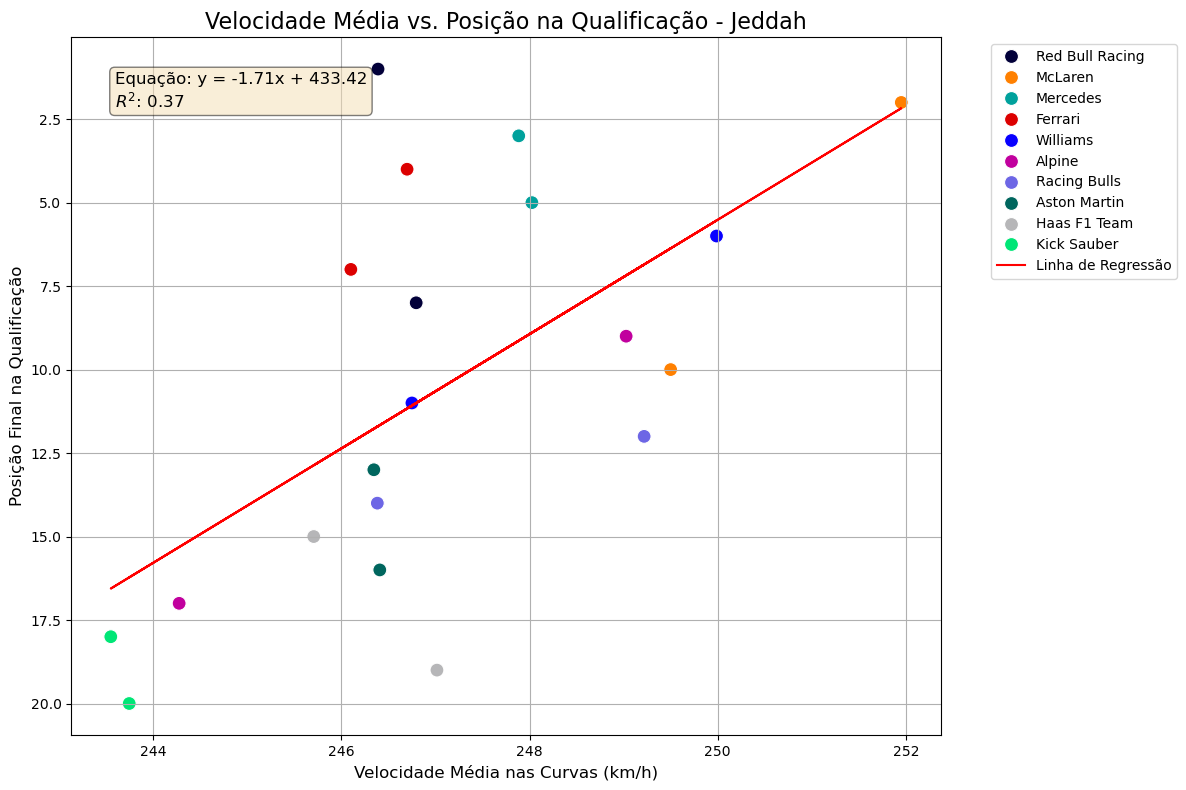

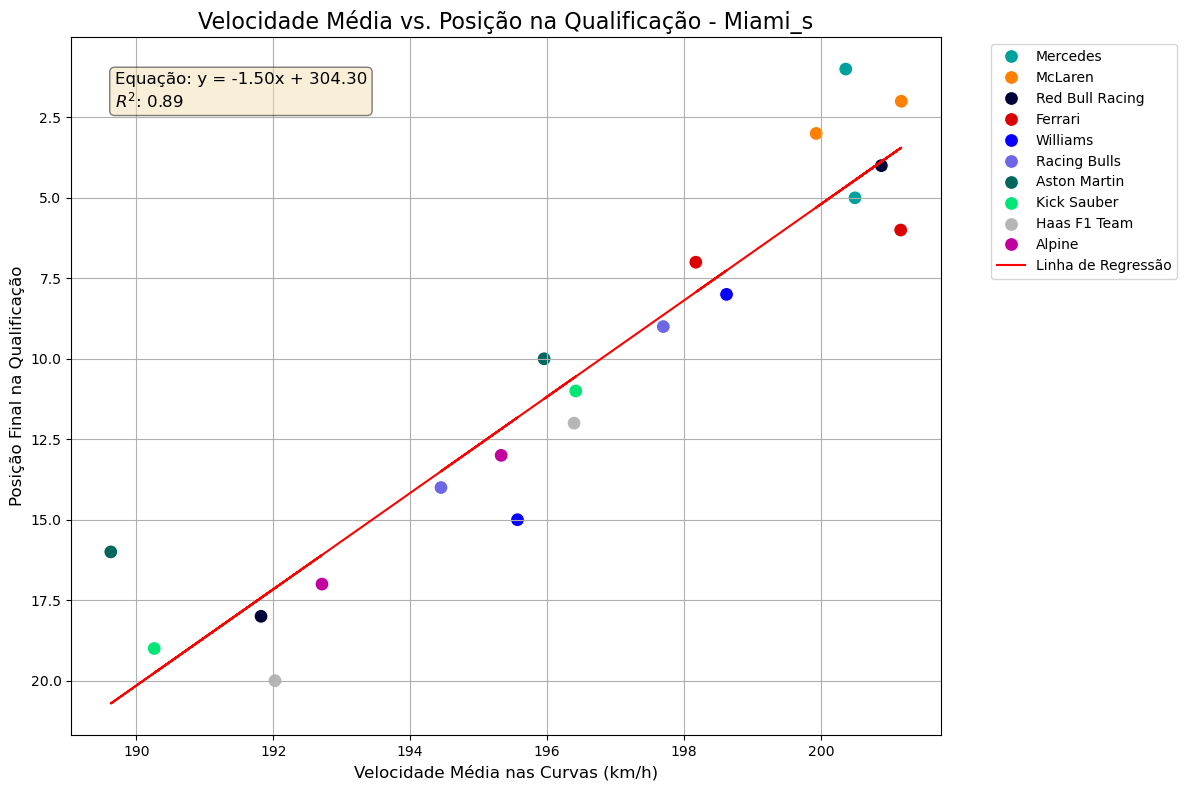

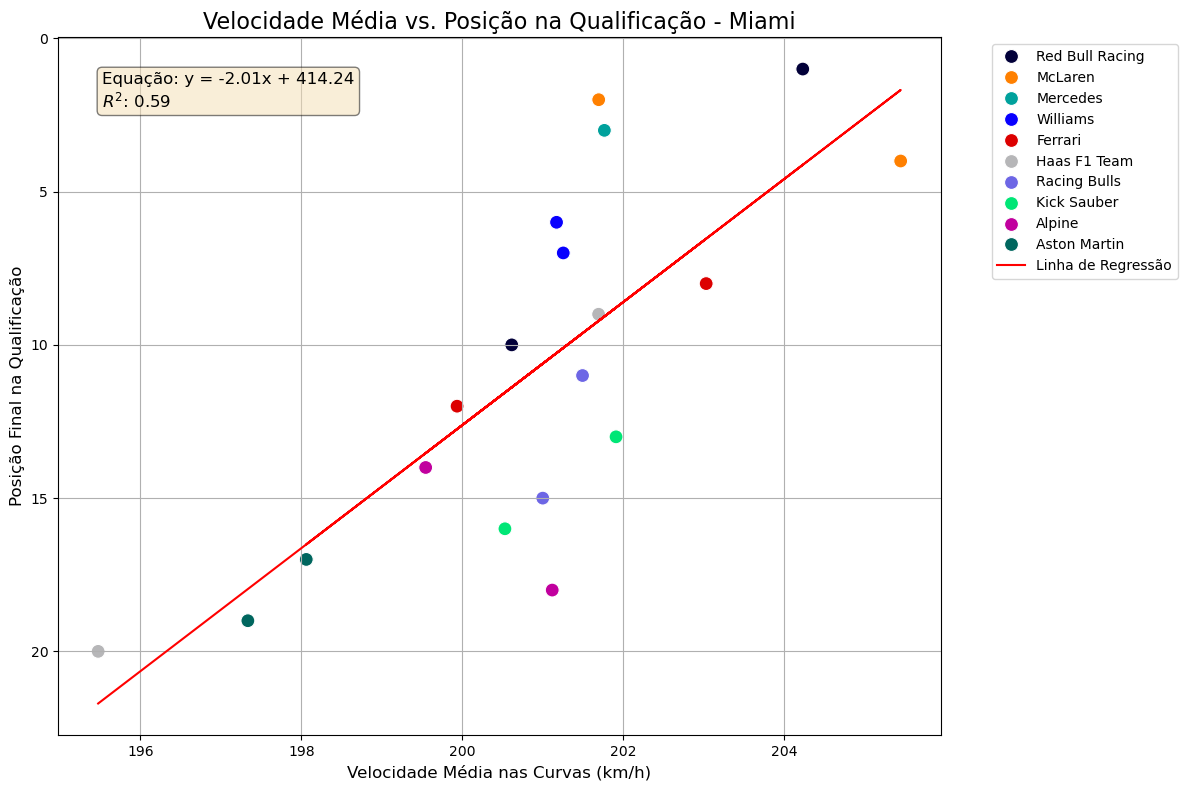

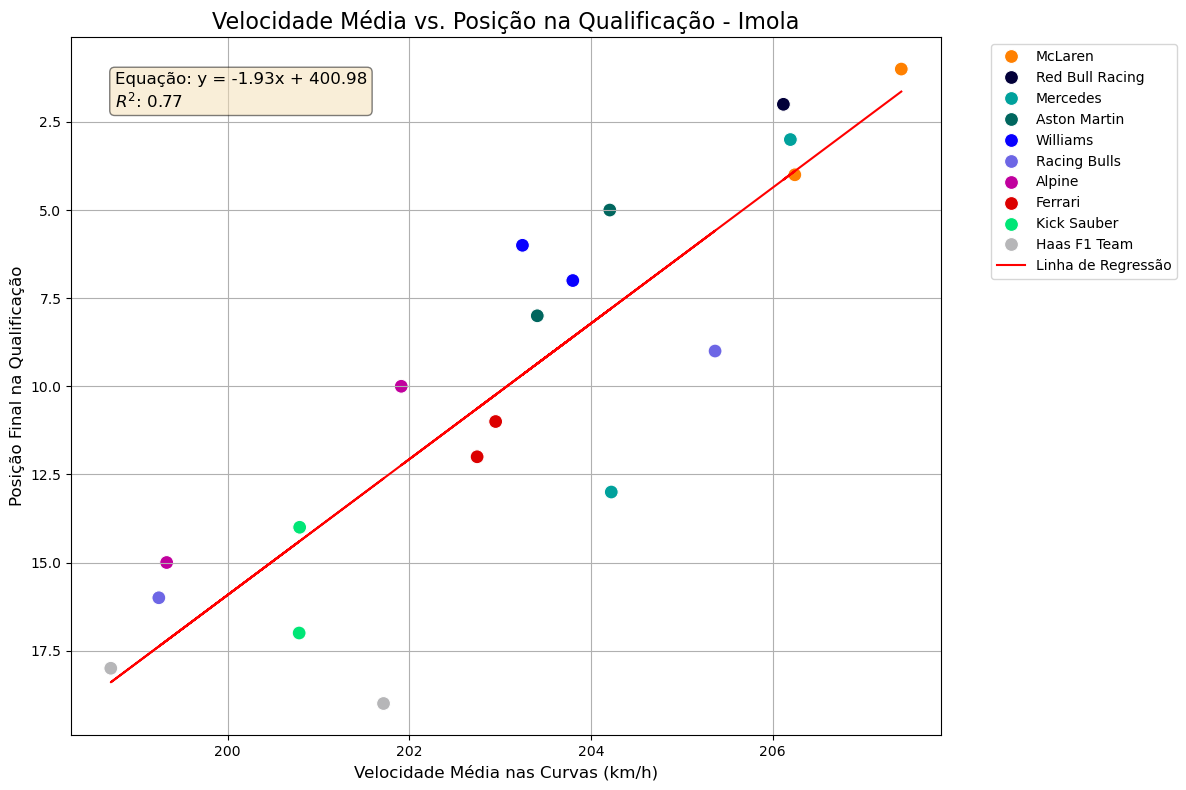

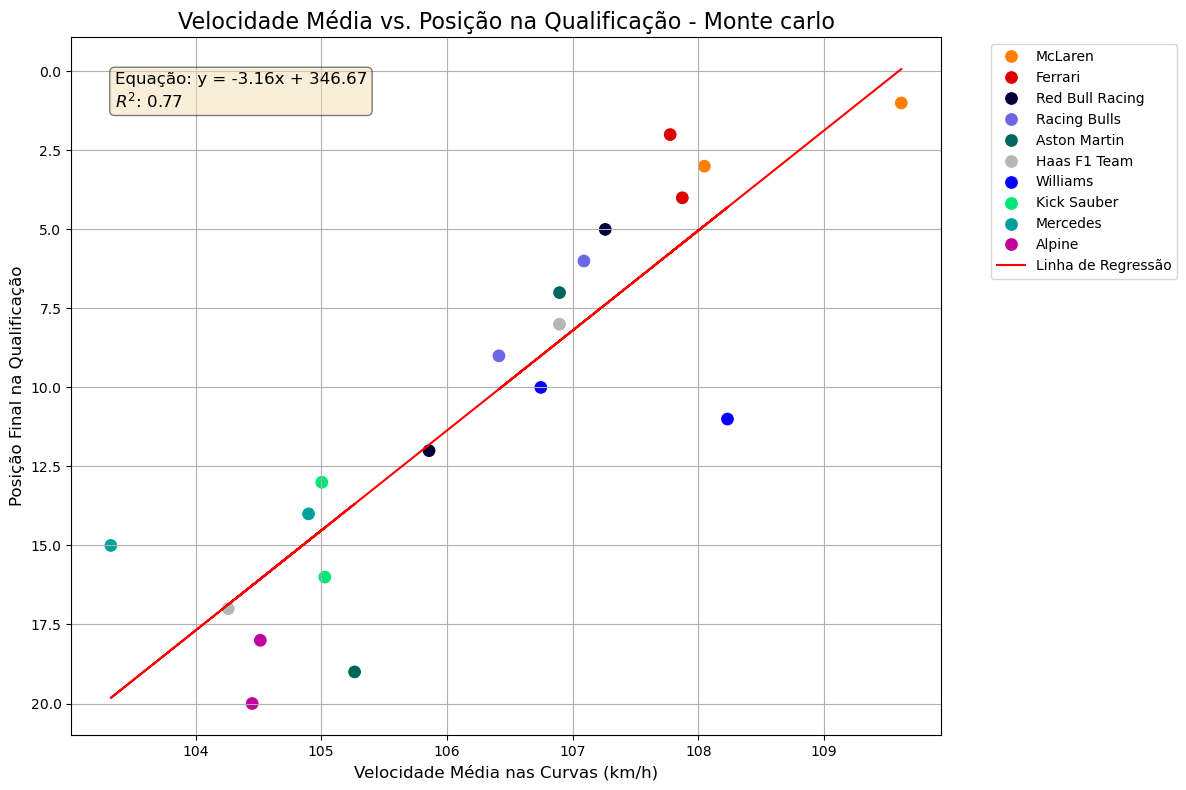

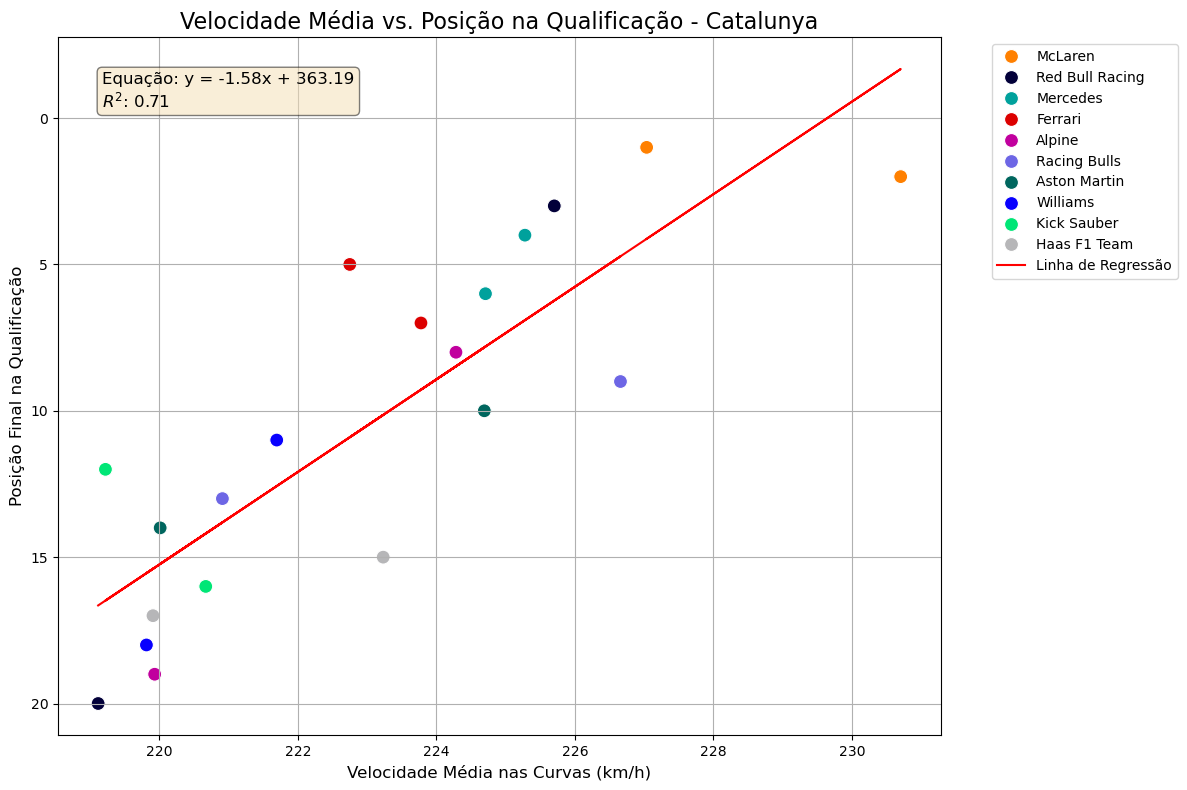

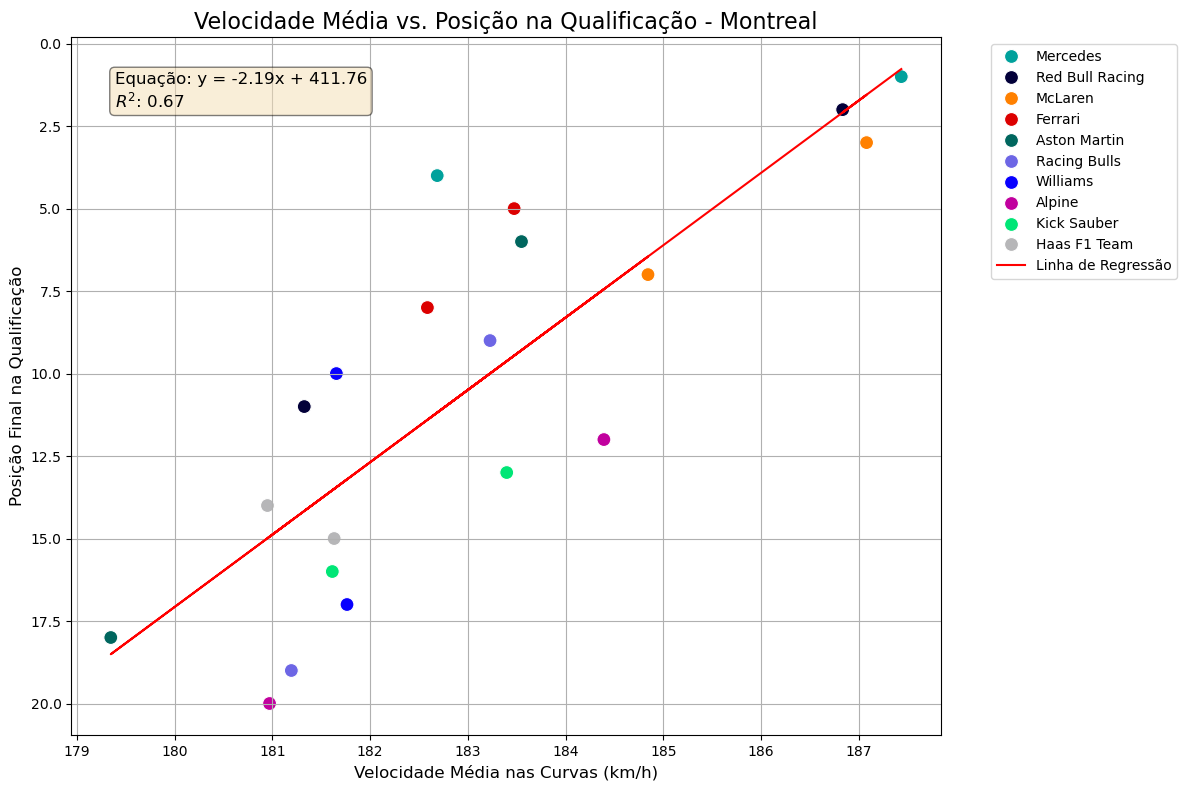

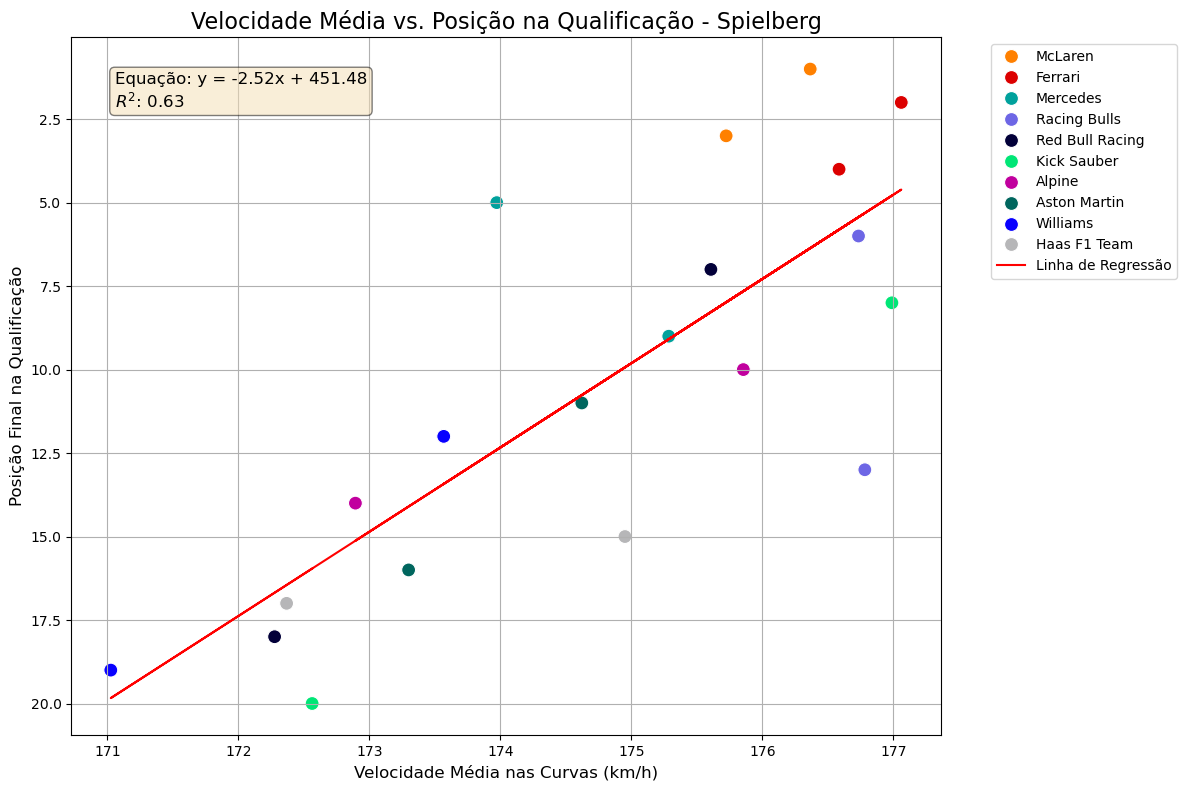

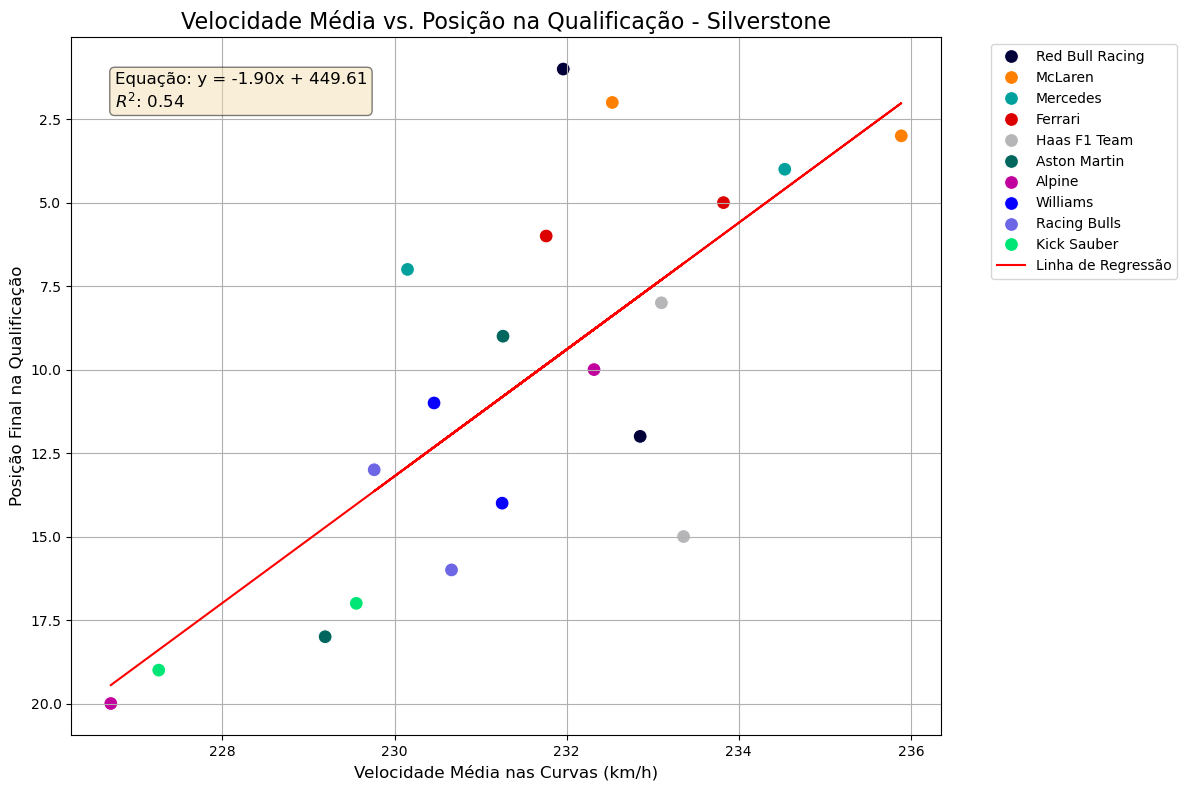

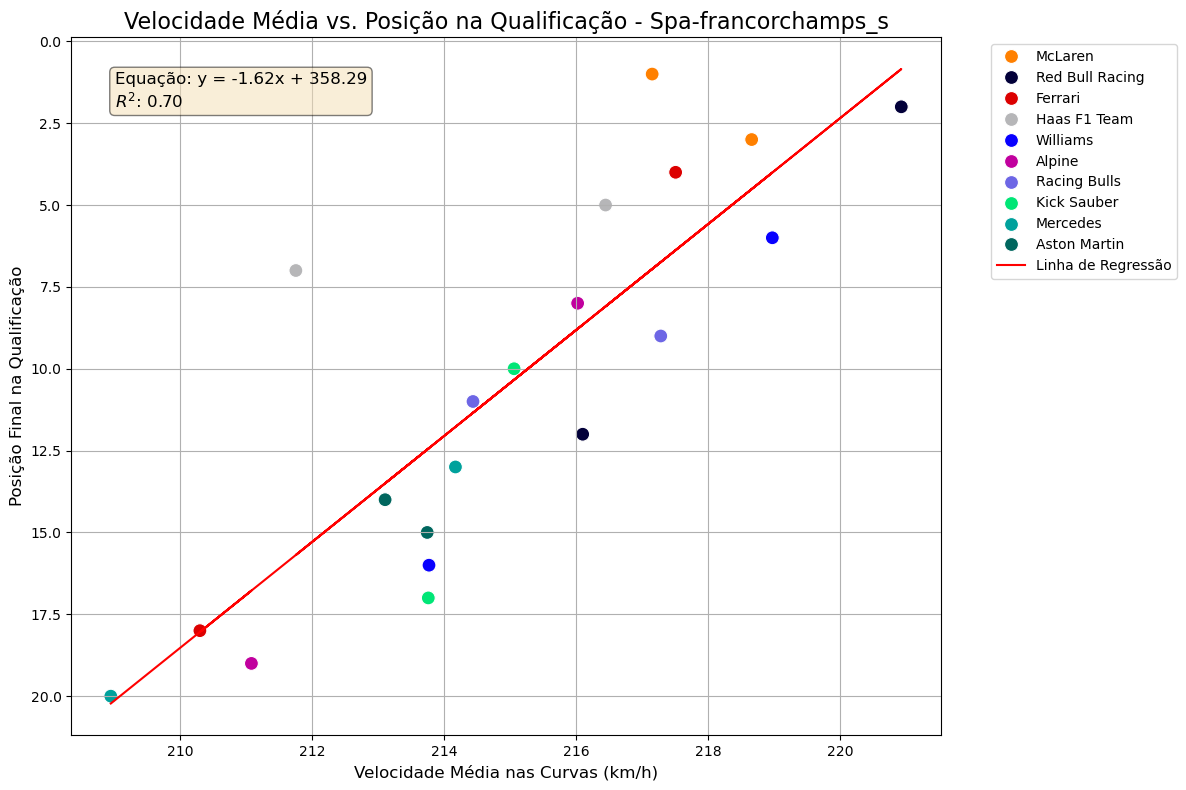

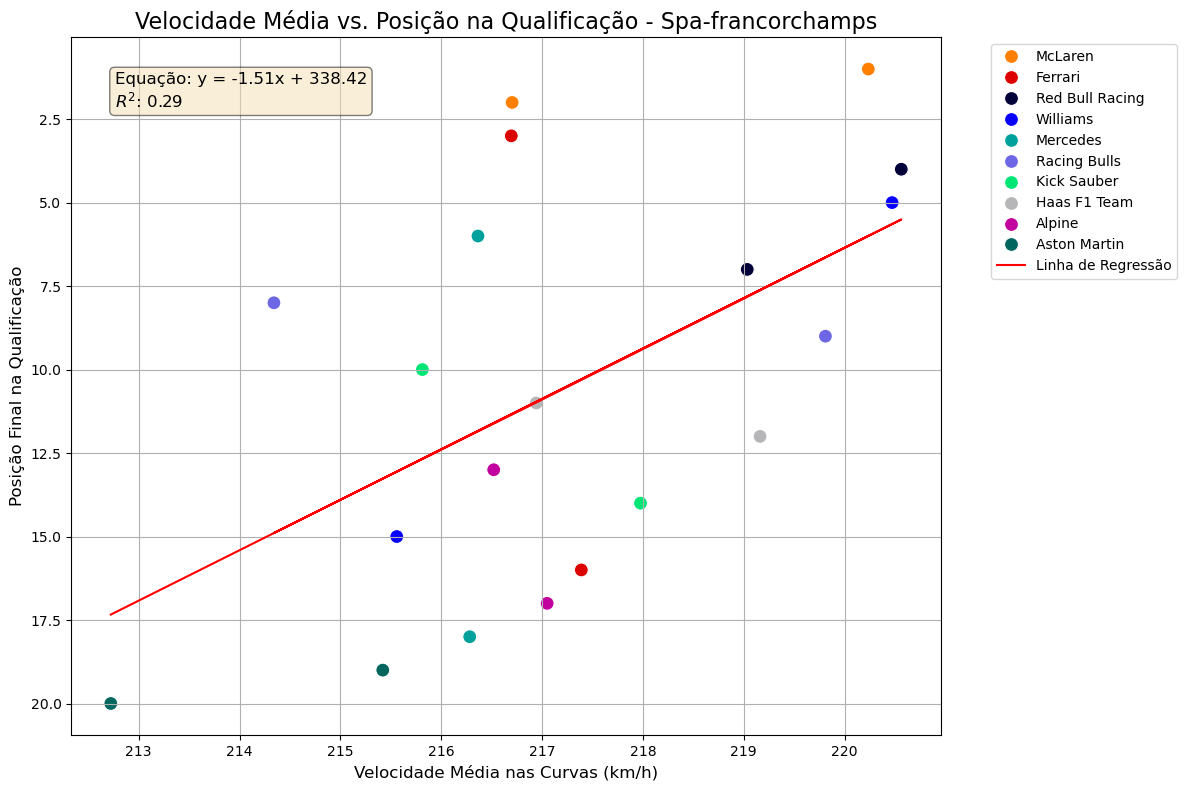

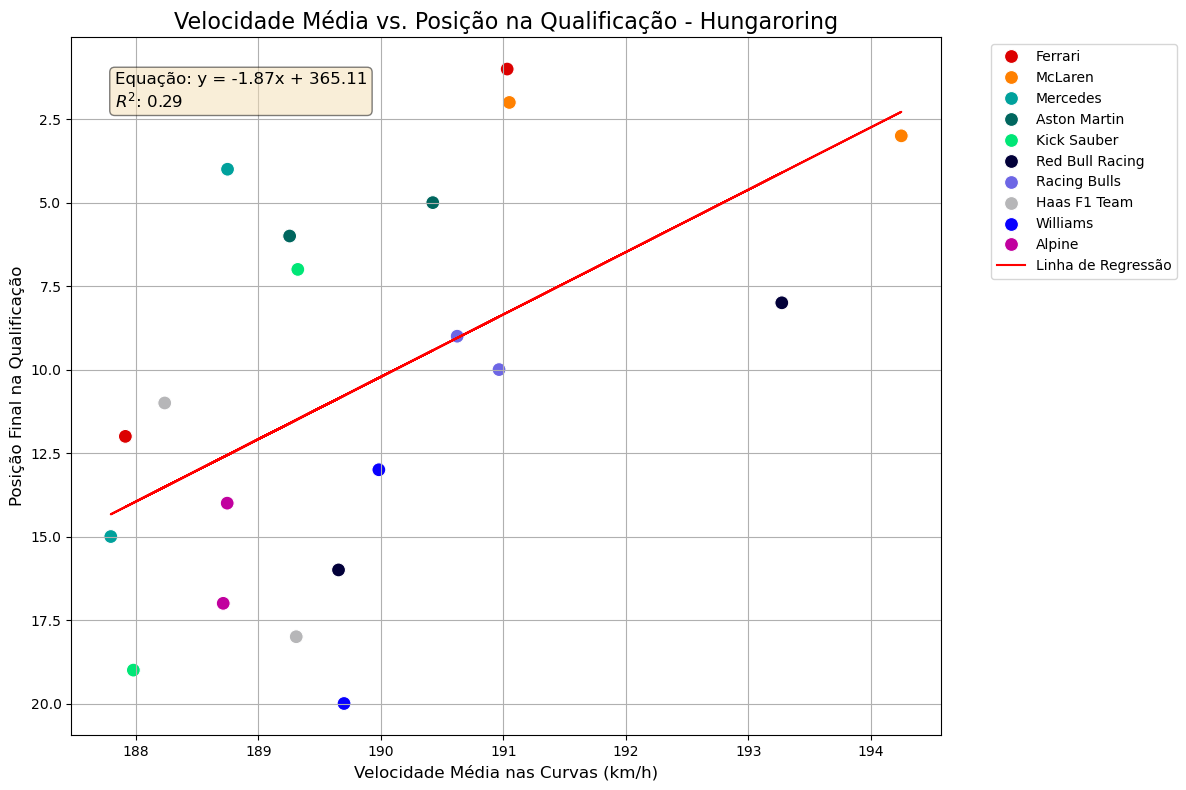

In [18]:
def gerar_grafico_regressao(etapa, nome_da_etapa):
    etapa = etapa.dropna()
    colunas_curvas = [col for col in etapa.columns if col.startswith('curva')]
    etapa['velocidade_media'] = etapa[colunas_curvas].mean(axis=1)
    
    x = etapa['velocidade_media']
    y = etapa['position']
    
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    plt.figure(figsize=(12, 8))
    grafico = sns.scatterplot(x=x, y=y, hue=etapa['team_name'],palette=cores, s=100)
    
    plt.plot(x, intercept + slope * x, 'r', label='Linha de Regressão')
    
    texto = (f'Equação: y = {slope:.2f}x + {intercept:.2f}\n'  
                  f'$R^2$: {r_value**2:.2f}')
    plt.text(0.05, 0.95, texto, transform=grafico.transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.title(f'Velocidade Média vs. Posição na Qualificação - {nome_da_etapa}', fontsize=16)
    plt.xlabel('Velocidade Média nas Curvas (km/h)', fontsize=12)
    plt.ylabel('Posição Final na Qualificação', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.plot()

cores = {
    'McLaren': '#FF8000',
    'Ferrari': '#DC0000',
    'Red Bull Racing': "#020039",
    'Mercedes': '#00A19C',
    'Williams': "#0800FF",
    'Kick Sauber': '#00E676',
    'Racing Bulls': "#6D66E5",
    'Haas F1 Team': '#B6B6B8',
    'Alpine': "#C1009E",
    'Aston Martin': '#00665E'
}
for arquivo in ordem_cronologica:
    etapa = pd.read_csv(arquivo)
    nome_etapa = os.path.basename(arquivo).replace('resultados_', '').replace('.csv', '').capitalize()
    gerar_grafico_regressao(etapa,nome_etapa)

A análise gráfica sugere que em 9 das 17 etapas, menos de 70% do resultado da qualificação pode ser explicado apenas pela velocidade média nas curvas. Isto sugere que nestes circuitos, o nosso modelo simples é insuficiente e que outras variáveis, como a eficiência em retas e a tração, desempenham um papel mais dominante.

Ainda, nos 3 casos de sprint, R² indica alta dependência, mas na qualificação principal o modelo tem R² baixo, o que pode indicar que as condições da pista e ajustes do carro se alteram de forma significativa de um dia para o outro.

Observamos que em casos com R² alto, como Monte Carlo, Imola e Sakhir, a velocidade média nas curvas e a posição final na qualificação formam um gráfico que tende a uma linha, e indica que tais circuitos são mais dependentes de curvas.

## Conclusão:

Os principais resultados que podemos interpretar são:

* O desempenho é relativo e especializado: Através da avaliação justa e normalizada usando Z-scores por fase de qualificação e dentro de categorias de curva, identificamos os pilotos com melhor desempenho e consistência ao longo da temporada, seja de forma geral, seja em categorias de curvas diferentes, mostrando que existem perfis de condução diferentes que se alinham a ajustes diferentes dos carros. 

* A evolução é complexa: A análise de qualificações para corridas sprint e de qualificações para corridas principais revelam que os pilotos não evoluem de forma uniforme, mas sim seguindo 3 situações típicas: otimização geral (pequenos ganhos), correção de erros de pilotagem (grandes ganhos ou perdas isoladas) e alterações de estratégia no ajuste (ganhos num tipo de curva em detrimento de outro).

* Diferentes curvas de aprendizagem: A trajetória dos pilotos novatos não é linear. Alguns demonstraram uma adaptação consistente e progressiva ao longo da temporada, enquanto outros exibiram um desempenho mais volátil, com picos de grande potencial, mas menor regularidade.

* A previsibilidade depende do contexto: A nossa análise de regressão linear demonstrou que a performance em curvas não é um preditor universal do sucesso. Em circuitos sinuosos e tecnicamente exigentes, a velocidade média nas curvas tem um poder preditivo muito alto. No entanto, em circuitos dominados por retas, o seu poder preditivo diminui drasticamente, mostrando que o contexto da pista é fundamental.

### Importância dos resultados:

A importância deste trabalho reside na sua capacidade de quantificar aspetos da desempenho na F1 que são frequentemente discutidos de forma qualitativa. Ao aplicar métodos estatísticos como o Z-Score e a regressão linear, transformamos conceitos abstratos como "habilidade em curva" ou "adaptação do piloto" em métricas mensuráveis e comparáveis. A conclusão fundamental é que uma análise de dados bem-sucedida na F1 requer uma abordagem minuciosa; modelos simplistas falham em capturar a complexidade de um esporte onde a interação entre piloto, carro e as características únicas de cada circuito define o resultado final.Este projeto demonstra que, ao separar a performance em componentes mais pequenos, obtemos insights muito mais profundos do que uma análise geral permitiria.

### Limitações e desafios:

* Coleta de Dados: A seleção manual das 88 curvas, embora feita com cuidado, pode conter um viés não intencional. Além disso, a delimitação de curvas em circuitos urbanos ou com sobreposição de pista (como Jeddah e Suzuka) apresentou desafios técnicos.

* Dados em Falta: Em algumas sessões, dados de certos pilotos não estavam disponíveis ou completos, o que os excluiu de análises pontuais e pode ter impactado ligeiramente as médias de grupo.

* Simplificação do Modelo: A nossa regressão linear principal utilizou uma única variável (velocidade média). Embora reveladora, ela não captura a totalidade dos fatores que influenciam o tempo de volta.

### Para trabalhos futuros:

* Enriquecimento dos dados analisados: Buscar uma forma mais prática de selecionar cada curva e utilizar mais métricas para avaliação: Incluir dados sobre pontos de frenagem ou a variação da velocidade na curva, ou ainda, dados sobre a temperatura da pista, direção do vento e previsão de chuva.

* Melhoria do agrupamento: Utilizar uma forma de agrupamento que não precise de filtros manuais para categorizar as curvas, de modo que os próprios dados mostrem categorias.

* Análise piloto vs carro: Buscar uma forma de avaliar o quão impactante é a técnica do piloto em relação ao desempenho geral do carro: Separar os dados que são influenciados pelo carro e os que são influenciados pelo piloto.

* Complexidade da regressão linear: Ampliar a capacidade preditiva do modelo, de forma a utilizar Regressão Linear Múltipla, como na biblioteca statsmodels, e ir além, criando um modelo preditivo global, com a utilização da biblioteca scikit-learn, de modo a combinar dados sobre as características do circuito e estilos de pilotagem de cada piloto.